In [ ]:
Описание проекта
Проект решает задачу классификации 9 эмоций на изображениях лиц (anger, contempt, disgust, fear, happy, neutral, sad, surprise, uncertain). 
Основная цель — достичь достаточной точности предсказаний (> 0.4) при соблюдении требования к времени инференса (<0.33 сек на изображение).

Используемые модели и подходы
В рамках проекта были протестированы следующие архитектуры и стратегии обучения:

1. EfficientNet-B0 (базовая модель)
Архитектура: предобученная на ImageNet

Стратегия: transfer learning с заморозкой начальных слоев

Аугментации: стандартные (повороты, отражения, изменение цвета)

Результат на Kaggle: 0.4444

2. ResNet50 (полная разморозка)
Архитектура: ResNet50 с предобученными весами

Стратегия: все слои обучаются (полная разморозка)

Оптимизатор: AdamW

Аугментации: усиленные (RandomErasing, увеличенные аффинные преобразования)

Результат на Kaggle: 0.4940

3. BiT V2 (Big Transfer)
Архитектура: модифицированный ResNet50

Стратегия: двухступенчатое обучение:

Stage 1 (5 эпох): обучение только классификационной головы

Stage 2 (30 эпох): тонкая настройка всей модели

Оптимизатор: SGD с Nesterov momentum

Scheduler: CosineAnnealing с warmup

Результат на Kaggle: 0.5140 (лучший результат)

4. BiT V2 Balanced
Архитектура: та же BiT модель

Стратегия: двухступенчатое обучение + балансировка датасета

Балансировка: upsampling миноритарных классов до 6278 изображений

Результат на Kaggle: 0.4944

Сравнение результатов на Kaggle
Модель	Public LB Score
EfficientNet-B0	0.4444
BiT V2 Balanced	0.4944
ResNet50 (полная разморозка)	0.4940
BiT V2	0.5140

Ключевые выводы

Что сработало хорошо:
BiT подход с двухступенчатым обучением — оптимальная стратегия для данной задачи

SGD с Nesterov — показал лучшие результаты, чем AdamW

Умеренные аугментации — без RandomErasing и агрессивных трансформаций

CosineAnnealing scheduler — эффективное управление learning rate

Что не сработало:
Полная балансировка датасета (BiT V2 Balanced) — вопреки ожиданиям, ухудшила результат с 0.514 до 0.494

Возможная причина: upsampling создал слишком много синтетических/повторяющихся примеров

Исходный дисбаланс, вероятно, отражает реальное распределение эмоций

Усиленные аугментации — RandomErasing и агрессивные трансформации не дали прироста

ResNet50 с полной разморозкой — показала результат близкий к EfficientNet, но не превзошла BiT

Итоговый результат:
Лучшая модель: BiT V2 с двухступенчатым обучением (Public LB: 0.5140)

Технические детали
Размер изображений: 224×224

Batch size: 32

Device: CPU (обучение заняло ~40 часов для BiT V2)

Время инференса: ~0.09 сек/изображение (соответствует требованию <0.33 сек)

In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageOps, ImageEnhance, ImageFilter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

# PyTorch импорты
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import torchvision.transforms.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

In [2]:
# Настройки для воспроизводимости
def set_seed(seed=42):
    """Установка seed для воспроизводимости"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Конфигурация
class Config:
    # Пути
    BASE_DIR = Path("/Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22")
    
    # Обработанные данные (из первой части)
    PROCESSED_DIR = BASE_DIR / "processed_data"
    PROCESSED_TRAIN_DIR = PROCESSED_DIR / "train_cropped_faces"
    PROCESSED_TEST_DIR = PROCESSED_DIR / "test_cropped_faces"
    
    # Файлы метаданных
    TRAIN_METADATA = PROCESSED_DIR / "train_processed_metadata.csv"
    TEST_METADATA = PROCESSED_DIR / "test_processed_metadata.csv"
    
    # Директории для моделей и результатов
    MODELS_DIR = BASE_DIR / "models"
    RESULTS_DIR = BASE_DIR / "results"
    
    # Настройки обучения
    IMG_SIZE = 224
    BATCH_SIZE = 32  # Уменьшил для CPU, можно увеличить если хватит памяти
    NUM_WORKERS = 4 if sys.platform != 'darwin' else 0  # Для macOS лучше 0
    NUM_EPOCHS = 30
    LEARNING_RATE = 1e-4
    NUM_CLASSES = 9
    
    # Настройки устройства
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Настройки валидации
    VAL_SPLIT = 0.2

config = Config()

# Создание директорий
for dir_path in [config.MODELS_DIR, config.RESULTS_DIR]:
    dir_path.mkdir(exist_ok=True, parents=True)

print(f"PyTorch версия: {torch.__version__}")
print(f"Используемое устройство: {config.DEVICE}")

PyTorch версия: 2.2.2
Используемое устройство: cpu


In [3]:
# ============================================================================
# Класс EmotionDataset PyTorch
# ============================================================================

class EmotionDataset(Dataset):
    """PyTorch Dataset для эмоций"""
    
    def __init__(self, metadata_df, images_dir, transform=None, is_test=False):
        """
        Args:
            metadata_df: DataFrame с метаданными изображений
            images_dir: Путь к директории с изображениями
            transform: transforms для аугментации
            is_test: Флаг тестовых данных
        """
        self.metadata_df = metadata_df
        self.images_dir = Path(images_dir)
        self.transform = transform
        self.is_test = is_test
        
        # Для тренировочных данных фильтруем только успешные
        if not is_test:
            self.metadata_df = self.metadata_df[self.metadata_df['success'] == True]
        
        # Создаем маппинг классов
        self.classes = sorted(self.metadata_df['class'].unique()) if not is_test else []
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.idx_to_class = {idx: cls for idx, cls in enumerate(self.classes)}
        
        # Подготовка данных
        self.image_paths = []
        self.labels = []
        
        if not is_test:
            # Тренировочные данные с классами
            for _, row in self.metadata_df.iterrows():
                if 'output_path' in row:
                    img_path = self.images_dir / row['class'] / Path(row['output_path']).name
                else:
                    img_path = self.images_dir / row['class'] / row['filename']
                
                if img_path.exists():
                    self.image_paths.append(str(img_path))
                    self.labels.append(self.class_to_idx[row['class']])
        else:
            # Тестовые данные без классов
            for _, row in self.metadata_df.iterrows():
                img_path = self.images_dir / row['filename']
                if img_path.exists():
                    self.image_paths.append(str(img_path))
                    self.labels.append(-1)  # Метка -1 для тестовых данных
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Загрузка изображения
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Ошибка загрузки изображения {img_path}: {e}")
            # Возвращаем черное изображение в случае ошибки
            image = Image.new('RGB', (config.IMG_SIZE, config.IMG_SIZE), color='black')
        
        # Применение трансформаций
        if self.transform:
            image = self.transform(image)
        
        return image, label
    
    def get_class_distribution(self):
        """Получить распределение классов"""
        if self.is_test:
            return None
        
        class_counts = {}
        for label in self.labels:
            cls_name = self.idx_to_class[label]
            class_counts[cls_name] = class_counts.get(cls_name, 0) + 1
        
        return class_counts

In [4]:
# ============================================================================
# Класс AugmentationTransforms PyTorch
# ============================================================================

class AugmentationTransforms:
    """Класс для создания аугментаций в PyTorch"""
    
    @staticmethod
    def get_train_transforms(img_size=224):
        """Аугментации для тренировочных данных"""
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.1
            ),
            transforms.RandomAffine(
                degrees=0,
                translate=(0.1, 0.1),
                scale=(0.9, 1.1),
                shear=10
            ),
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=3)
            ], p=0.3),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],  # ImageNet mean
                std=[0.229, 0.224, 0.225]    # ImageNet std
            )
        ])
    
    @staticmethod
    def get_val_transforms(img_size=224):
        """Преобразования для валидационных данных"""
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])
    
    @staticmethod
    def get_strong_augmentation(img_size=224):
        """Сильные аугментации для minority классов"""
        return transforms.Compose([
            transforms.Resize((img_size + 64, img_size + 64)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(degrees=30),
            transforms.ColorJitter(
                brightness=0.3,
                contrast=0.3,
                saturation=0.3,
                hue=0.2
            ),
            transforms.RandomAffine(
                degrees=15,
                translate=(0.2, 0.2),
                scale=(0.8, 1.2),
                shear=15
            ),
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=5)
            ], p=0.5),
            transforms.RandomErasing(p=0.3, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])
    
    @staticmethod
    def get_test_transforms(img_size=224):
        """Преобразования для тестовых данных"""
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

In [5]:
# ============================================================================
# Функции для шума
# ============================================================================

def add_noise_torch(image_tensor, noise_type="gauss"):
    """Добавление шума к тензору изображения"""
    if noise_type == "gauss":
        # Гауссов шум
        noise = torch.randn_like(image_tensor) * 0.1
        return torch.clamp(image_tensor + noise, 0, 1)
    elif noise_type == "s&p":
        # Соль-перец шум
        image_np = image_tensor.numpy()
        row, col, ch = image_np.shape
        s_vs_p = 0.5
        amount = 0.02
        
        out = np.copy(image_np)
        
        # Salt mode
        num_salt = np.ceil(amount * row * col * s_vs_p)
        coords = [np.random.randint(0, i - 1, int(num_salt)) for i in (row, col)]
        out[coords[0], coords[1], :] = np.random.uniform(0.6, 1.0, size=(int(num_salt), ch))
        
        # Pepper mode
        num_pepper = np.ceil(amount * row * col * (1. - s_vs_p))
        coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in (row, col)]
        out[coords[0], coords[1], :] = np.random.uniform(0, 0.4, size=(int(num_pepper), ch))
        
        return torch.from_numpy(out).float()
    return image_tensor

class RandomNoiseTransform:
    """Трансформация с добавлением случайного шума"""
    
    def __init__(self, p=0.3):
        self.p = p
        self.noise_types = ["gauss", "s&p"]
    
    def __call__(self, image_tensor):
        if random.random() < self.p:
            noise_type = random.choice(self.noise_types)
            return add_noise_torch(image_tensor, noise_type)
        return image_tensor

In [6]:
# ============================================================================
# Функции для разделения данных
# ============================================================================

def stratified_split(metadata_df, val_size=0.2, random_state=42):
    """Стратифицированное разделение данных по классам"""
    print(f"\nСтратифицированное разделение данных (val_size={val_size})")
    
    train_dfs = []
    val_dfs = []
    
    for class_name in metadata_df['class'].unique():
        class_df = metadata_df[metadata_df['class'] == class_name]
        
        # Случайное перемешивание
        class_df = class_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
        
        # Вычисляем размер валидации
        n_val = int(len(class_df) * val_size)
        
        # Разделяем
        class_val_df = class_df.iloc[:n_val]
        class_train_df = class_df.iloc[n_val:]
        
        train_dfs.append(class_train_df)
        val_dfs.append(class_val_df)
        
        print(f"  {class_name}: train={len(class_train_df)}, val={len(class_val_df)}")
    
    # Объединяем
    train_df = pd.concat(train_dfs, ignore_index=True).sample(frac=1, random_state=random_state)
    val_df = pd.concat(val_dfs, ignore_index=True).sample(frac=1, random_state=random_state)
    
    print(f"\nИтого:")
    print(f"  Train: {len(train_df)} изображений")
    print(f"  Val: {len(val_df)} изображений")
    
    return train_df, val_df

In [7]:
# ============================================================================
# Создание DataLoader'ов с WeightedRandomSampler
# ============================================================================

def create_dataloaders(train_df, val_df, images_dir, batch_size=32, use_weighted_sampler=True):
    """Создание DataLoader'ов с возможностью балансировки"""
    
    # Трансформации
    train_transform = AugmentationTransforms.get_train_transforms(config.IMG_SIZE)
    val_transform = AugmentationTransforms.get_val_transforms(config.IMG_SIZE)
    
    # Создание Dataset'ов
    train_dataset = EmotionDataset(train_df, images_dir, transform=train_transform)
    val_dataset = EmotionDataset(val_df, images_dir, transform=val_transform)
    
    print(f"\nСозданы Dataset'ы:")
    print(f"  Train: {len(train_dataset)} изображений")
    print(f"  Val: {len(val_dataset)} изображений")
    
    # Распределение классов
    train_class_dist = train_dataset.get_class_distribution()
    val_class_dist = val_dataset.get_class_distribution()
    
    if train_class_dist:
        print("\nРаспределение классов в train:")
        for cls, count in train_class_dist.items():
            print(f"  {cls}: {count}")
    
    # Создание WeightedRandomSampler для борьбы с дисбалансом
    if use_weighted_sampler and train_class_dist:
        print("\nСоздание WeightedRandomSampler для балансировки классов...")
        
        # Вычисляем веса для каждого класса
        class_weights = {}
        total_samples = sum(train_class_dist.values())
        
        for cls, count in train_class_dist.items():
            # Вес обратно пропорционален количеству образцов
            class_weights[train_dataset.class_to_idx[cls]] = total_samples / (len(train_class_dist) * count)
        
        # Создаем веса для каждого образца
        sample_weights = [0] * len(train_dataset)
        for idx, (_, label) in enumerate(train_dataset):
            sample_weights[idx] = class_weights[label]
        
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            num_workers=config.NUM_WORKERS,
            pin_memory=True if config.DEVICE.type == "cuda" else False
        )
    else:
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=config.NUM_WORKERS,
            pin_memory=True if config.DEVICE.type == "cuda" else False
        )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=True if config.DEVICE.type == "cuda" else False
    )
    
    return train_loader, val_loader, train_dataset.class_to_idx, train_dataset.idx_to_class

In [8]:
# ============================================================================
# Визуализация данных
# ============================================================================

def visualize_augmentations(dataloader, idx_to_class, n_images=5):
    """Визуализация аугментированных изображений"""
    print("\nВизуализация аугментированных изображений...")
    
    # Берем один батч
    images, labels = next(iter(dataloader))
    
    # Выбираем несколько изображений для визуализации
    n_images = min(n_images, len(images))
    
    fig, axes = plt.subplots(1, n_images, figsize=(15, 3))
    
    if n_images == 1:
        axes = [axes]
    
    for i in range(n_images):
        # Денормализация изображения
        img = images[i].numpy().transpose(1, 2, 0)
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(f"{idx_to_class[labels[i].item()]}")
        axes[i].axis('off')
    
    plt.suptitle("Примеры аугментированных изображений", fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_class_distribution(train_loader, val_loader, idx_to_class):
    """Визуализация распределения классов"""
    
    # Собираем статистику по классам
    train_counts = {}
    val_counts = {}
    
    for images, labels in train_loader:
        for label in labels:
            cls_name = idx_to_class[label.item()]
            train_counts[cls_name] = train_counts.get(cls_name, 0) + 1
    
    for images, labels in val_loader:
        for label in labels:
            cls_name = idx_to_class[label.item()]
            val_counts[cls_name] = val_counts.get(cls_name, 0) + 1
    
    # Создаем DataFrame для визуализации
    classes = list(idx_to_class.values())
    train_counts_list = [train_counts.get(cls, 0) for cls in classes]
    val_counts_list = [val_counts.get(cls, 0) for cls in classes]
    
    df = pd.DataFrame({
        'Class': classes,
        'Train': train_counts_list,
        'Validation': val_counts_list
    })
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    x = np.arange(len(classes))
    width = 0.35
    
    axes[0].bar(x - width/2, train_counts_list, width, label='Train', color='lightblue')
    axes[0].bar(x + width/2, val_counts_list, width, label='Validation', color='lightcoral')
    axes[0].set_xlabel('Класс')
    axes[0].set_ylabel('Количество')
    axes[0].set_title('Распределение классов в train/val')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(classes, rotation=45)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Pie chart для train
    axes[1].pie(train_counts_list, labels=classes, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Распределение классов в train')
    
    plt.tight_layout()
    plt.show()
    
    return df

In [9]:
# ============================================================================
# Основная функция подготовки данных
# ============================================================================

def prepare_data_for_training():
    """Основная функция подготовки данных для обучения"""
    print("=" * 60)
    print("ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ")
    print("=" * 60)
    
    # 1. Загрузка метаданных
    print("\n1. Загрузка метаданных...")
    if not config.TRAIN_METADATA.exists():
        print(f"Ошибка: файл метаданных не найден: {config.TRAIN_METADATA}")
        return None
    
    train_metadata = pd.read_csv(config.TRAIN_METADATA)
    print(f"Загружено {len(train_metadata)} записей")
    
    # 2. Разделение на train/val
    print("\n2. Разделение данных на train/val...")
    train_df, val_df = stratified_split(train_metadata, val_size=config.VAL_SPLIT)
    
    # 3. Сохранение разделенных данных
    print("\n3. Сохранение разделенных данных...")
    train_split_path = config.RESULTS_DIR / "train_split.csv"
    val_split_path = config.RESULTS_DIR / "val_split.csv"
    
    train_df.to_csv(train_split_path, index=False)
    val_df.to_csv(val_split_path, index=False)
    
    print(f"  Train split сохранен: {train_split_path}")
    print(f"  Val split сохранен: {val_split_path}")
    
    # 4. Создание DataLoader'ов
    print("\n4. Создание DataLoader'ов...")
    train_loader, val_loader, class_to_idx, idx_to_class = create_dataloaders(
        train_df, 
        val_df, 
        config.PROCESSED_TRAIN_DIR,
        batch_size=config.BATCH_SIZE,
        use_weighted_sampler=True
    )
    
    # 5. Сохранение маппинга классов
    print("\n5. Сохранение маппинга классов...")
    class_mapping_df = pd.DataFrame({
        'class_name': list(class_to_idx.keys()),
        'class_idx': list(class_to_idx.values())
    })
    
    class_mapping_path = config.RESULTS_DIR / "class_mapping.csv"
    class_mapping_df.to_csv(class_mapping_path, index=False)
    print(f"Маппинг классов сохранен: {class_mapping_path}")
    
    # 6. Визуализация данных
    print("\n6. Визуализация данных...")
    
    # Визуализация аугментаций
    visualize_augmentations(train_loader, idx_to_class, n_images=5)
    
    # Визуализация распределения классов
    distribution_df = plot_class_distribution(train_loader, val_loader, idx_to_class)
    
    # 7. Статистика
    print("\n7. Статистика подготовки данных:")
    print(f"  Batch size: {config.BATCH_SIZE}")
    print(f"  Image size: {config.IMG_SIZE}x{config.IMG_SIZE}")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches: {len(val_loader)}")
    print(f"  Total train images: {len(train_loader.dataset)}")
    print(f"  Total val images: {len(val_loader.dataset)}")
    
    # Пример размеров батча
    sample_batch = next(iter(train_loader))
    print(f"  Batch shape: {sample_batch[0].shape}")
    print(f"  Labels shape: {sample_batch[1].shape}")
    
    return {
        'train_loader': train_loader,
        'val_loader': val_loader,
        'class_to_idx': class_to_idx,
        'idx_to_class': idx_to_class,
        'train_df': train_df,
        'val_df': val_df,
        'distribution_df': distribution_df
    }


НАЧАЛО ПОДГОТОВКИ ДАННЫХ ДЛЯ ОБУЧЕНИЯ
ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ

1. Загрузка метаданных...
Загружено 49310 записей

2. Разделение данных на train/val...

Стратифицированное разделение данных (val_size=0.2)
  happy: train=4758, val=1189
  uncertain: train=4718, val=1179
  contempt: train=2452, val=612
  sad: train=5300, val=1325
  fear: train=3886, val=971
  surprise: train=4965, val=1241
  neutral: train=5412, val=1352
  anger: train=5520, val=1380
  disgust: train=2440, val=610

Итого:
  Train: 39451 изображений
  Val: 9859 изображений

3. Сохранение разделенных данных...
  Train split сохранен: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/results/train_split.csv
  Val split сохранен: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/results/val_split.csv

4. Создание DataLoader'ов...

Созданы Dataset'ы:
  Train: 36511 изображений
  Val: 9118 изображений


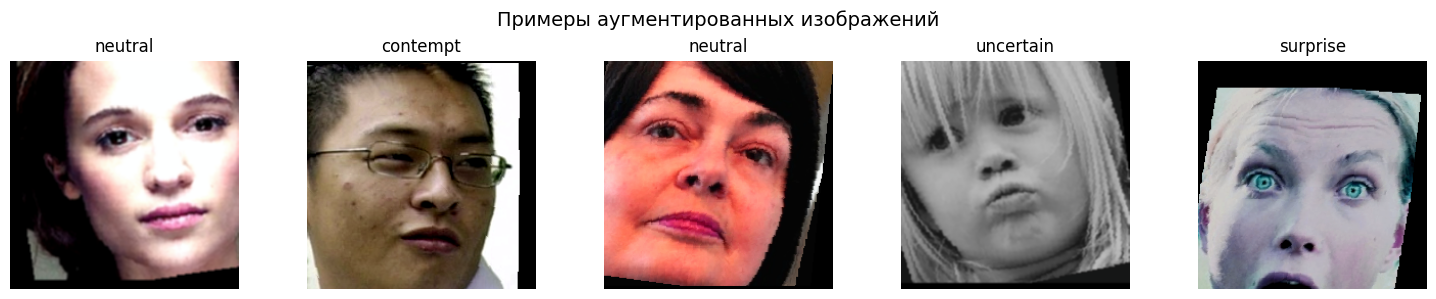

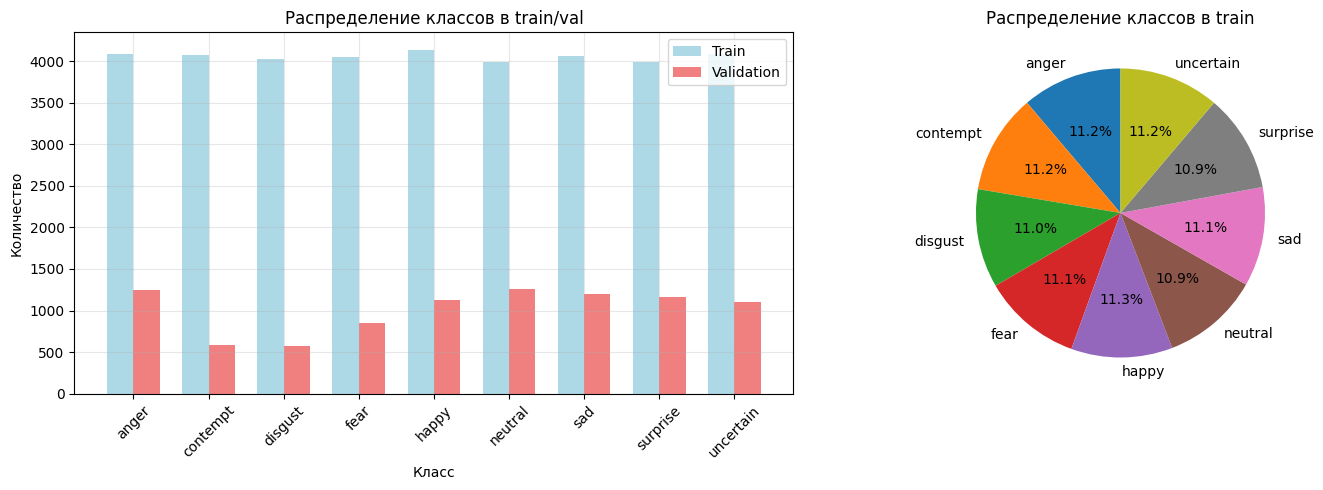


7. Статистика подготовки данных:
  Batch size: 32
  Image size: 224x224
  Train batches: 1141
  Val batches: 285
  Total train images: 36511
  Total val images: 9118
  Batch shape: torch.Size([32, 3, 224, 224])
  Labels shape: torch.Size([32])

✅ Подготовка данных завершена за 683.5 секунд


In [11]:
# ============================================================================
# Запуск подготовки данных
# ============================================================================

if __name__ == "__main__":
    import time
    
    print("=" * 60)
    print("НАЧАЛО ПОДГОТОВКИ ДАННЫХ ДЛЯ ОБУЧЕНИЯ")
    print("=" * 60)
    
    start_time = time.time()
    
    # Запуск подготовки данных
    data_info = prepare_data_for_training()
    
    if data_info:
        elapsed_time = time.time() - start_time
        print(f"\n✅ Подготовка данных завершена за {elapsed_time:.1f} секунд")
        
    else:
        print("\n❌ Ошибка при подготовке данных!")

In [24]:
# ============================================================================
# СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ
# ============================================================================

import time
from datetime import datetime
import json
import torch.nn.functional as F

class EmotionClassifier(nn.Module):
    """Классификатор эмоций на основе предобученной модели"""
    
    def __init__(self, base_model_name='efficientnet_b0', num_classes=9, pretrained=True):
        super(EmotionClassifier, self).__init__()
        
        self.base_model_name = base_model_name
        self.num_classes = num_classes
        
        # Выбор базовой модели
        if base_model_name.startswith('efficientnet'):
            # EfficientNet
            if base_model_name == 'efficientnet_b0':
                self.base_model = models.efficientnet_b0(pretrained=pretrained)
                num_features = self.base_model.classifier[1].in_features
            elif base_model_name == 'efficientnet_b1':
                self.base_model = models.efficientnet_b1(pretrained=pretrained)
                num_features = self.base_model.classifier[1].in_features
            elif base_model_name == 'efficientnet_b2':
                self.base_model = models.efficientnet_b2(pretrained=pretrained)
                num_features = self.base_model.classifier[1].in_features
            else:
                self.base_model = models.efficientnet_b0(pretrained=pretrained)
                num_features = self.base_model.classifier[1].in_features
            
            # Заменяем классификатор
            self.base_model.classifier = nn.Identity()
            
        elif base_model_name.startswith('resnet'):
            # ResNet
            if base_model_name == 'resnet18':
                self.base_model = models.resnet18(pretrained=pretrained)
                num_features = self.base_model.fc.in_features
            elif base_model_name == 'resnet34':
                self.base_model = models.resnet34(pretrained=pretrained)
                num_features = self.base_model.fc.in_features
            elif base_model_name == 'resnet50':
                self.base_model = models.resnet50(pretrained=pretrained)
                num_features = self.base_model.fc.in_features
            else:
                self.base_model = models.resnet18(pretrained=pretrained)
                num_features = self.base_model.fc.in_features
            
            # Заменяем последний слой
            self.base_model.fc = nn.Identity()
        
        elif base_model_name == 'mobilenet_v3':
            # MobileNetV3
            self.base_model = models.mobilenet_v3_large(pretrained=pretrained)
            num_features = self.base_model.classifier[-1].in_features
            self.base_model.classifier = nn.Identity()
        
        else:
            raise ValueError(f"Неизвестная модель: {base_model_name}")
        
        # Наш классификатор
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        
        # Заморозка начальных слоев для transfer learning
        self._freeze_layers()
    
    def _freeze_layers(self):
        """Заморозка начальных слоев базовой модели"""
        # Для EfficientNet
        if self.base_model_name.startswith('efficientnet'):
            # Замораживаем первые слои
            for param in self.base_model.features[:5].parameters():
                param.requires_grad = False
        
        # Для ResNet
        elif self.base_model_name.startswith('resnet'):
            # Замораживаем первые слои
            for param in self.base_model.parameters():
                param.requires_grad = False
            # Размораживаем последние слои
            for param in self.base_model.layer4.parameters():
                param.requires_grad = True
            for param in self.base_model.fc.parameters():
                param.requires_grad = True
        
        # Для MobileNetV3
        elif self.base_model_name == 'mobilenet_v3':
            for param in self.base_model.features[:10].parameters():
                param.requires_grad = False
    
    def forward(self, x):
        features = self.base_model(x)
        output = self.classifier(features)
        return output
    
    def unfreeze_all(self):
        """Разморозить все слои для fine-tuning"""
        for param in self.parameters():
            param.requires_grad = True
    
    def get_trainable_params(self):
        """Получить количество обучаемых параметров"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [25]:
# ============================================================================
# ТРЕНИРОВКА МОДЕЛИ
# ============================================================================

class ModelTrainer:
    """Класс для обучения модели"""
    
    def __init__(self, model, train_loader, val_loader, device, idx_to_class):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.idx_to_class = idx_to_class
        
        # История обучения
        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'learning_rates': []
        }
        
        # Время обучения
        self.start_time = None
        self.end_time = None
        
        # Лучшие результаты
        self.best_val_acc = 0.0
        self.best_model_state = None
    
    def train_epoch(self, optimizer, criterion, scheduler=None):
        """Обучение на одной эпохе"""
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        pbar = tqdm(self.train_loader, desc=f"Training", leave=False)
        
        for batch_idx, (inputs, labels) in enumerate(pbar):
            inputs, labels = inputs.to(self.device), labels.to(self.device)
            
            # Обнуление градиентов
            optimizer.zero_grad()
            
            # Forward pass
            outputs = self.model(inputs)
            loss = criterion(outputs, labels)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Статистика
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # Обновление progress bar
            pbar.set_postfix({
                'loss': running_loss / (batch_idx + 1),
                'acc': 100. * correct / total
            })
        
        epoch_loss = running_loss / len(self.train_loader)
        epoch_acc = 100. * correct / total
        
        return epoch_loss, epoch_acc
    
    def validate(self, criterion):
        """Валидация модели"""
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Для confusion matrix
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            pbar = tqdm(self.val_loader, desc=f"Validation", leave=False)
            
            for batch_idx, (inputs, labels) in enumerate(pbar):
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                
                outputs = self.model(inputs)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                # Сохраняем предсказания и метки
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
                pbar.set_postfix({
                    'loss': running_loss / (batch_idx + 1),
                    'acc': 100. * correct / total
                })
        
        epoch_loss = running_loss / len(self.val_loader)
        epoch_acc = 100. * correct / total
        
        return epoch_loss, epoch_acc, all_preds, all_labels
    
    def train(self, num_epochs, optimizer, criterion, scheduler=None, 
              early_stopping_patience=10, save_best=True):
        """Полный цикл обучения"""
        
        print(f"\n{'='*60}")
        print(f"НАЧАЛО ОБУЧЕНИЯ МОДЕЛИ")
        print(f"{'='*60}")
        print(f"Модель: {self.model.__class__.__name__}")
        print(f"Обучаемых параметров: {self.model.get_trainable_params():,}")
        print(f"Эпох: {num_epochs}")
        print(f"Batch size: {self.train_loader.batch_size}")
        print(f"Train samples: {len(self.train_loader.dataset)}")
        print(f"Val samples: {len(self.val_loader.dataset)}")
        print(f"Устройство: {self.device}")
        print(f"{'='*60}")
        
        self.start_time = time.time()
        patience_counter = 0
        
        for epoch in range(num_epochs):
            print(f"\nЭпоха [{epoch+1}/{num_epochs}]")
            
            # Обучение
            train_loss, train_acc = self.train_epoch(optimizer, criterion, scheduler)
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            
            # Валидация
            val_loss, val_acc, _, _ = self.validate(criterion)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            
            # Learning rate
            if scheduler:
                self.history['learning_rates'].append(optimizer.param_groups[0]['lr'])
                scheduler.step(val_loss)
            
            # Вывод результатов эпохи
            print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
            print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
            if scheduler:
                print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
            
            # Сохранение лучшей модели
            if save_best and val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.best_model_state = self.model.state_dict().copy()
                patience_counter = 0
                print(f"  ✅ Новая лучшая модель! Acc: {val_acc:.2f}%")
                
                # Сохранение модели
                self.save_model(
                    config.MODELS_DIR / f"best_model_epoch_{epoch+1}_acc_{val_acc:.2f}.pth",
                    epoch=epoch,
                    val_acc=val_acc
                )
            else:
                patience_counter += 1
                print(f"  ⏳ Early stopping: {patience_counter}/{early_stopping_patience}")
            
            # Early stopping
            if patience_counter >= early_stopping_patience:
                print(f"\n⏹️  Early stopping на эпохе {epoch+1}")
                break
        
        self.end_time = time.time()
        training_time = self.end_time - self.start_time
        
        # Загрузка лучшей модели
        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
            print(f"\n✅ Загружена лучшая модель с accuracy: {self.best_val_acc:.2f}%")
        
        print(f"\n{'='*60}")
        print(f"ОБУЧЕНИЕ ЗАВЕРШЕНО")
        print(f"{'='*60}")
        print(f"Общее время обучения: {training_time/60:.1f} минут")
        print(f"Лучшая точность на валидации: {self.best_val_acc:.2f}%")
        print(f"Финальная точность на валидации: {self.history['val_acc'][-1]:.2f}%")
        
        return self.history

    def save_model(self, save_path, epoch=None, val_acc=None):
        """Сохранение модели"""
        torch.save({
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'best_val_acc': self.best_val_acc,
            'history': self.history,
            'model_class': self.model.__class__.__name__,
            'model_config': {
                'base_model_name': self.model.base_model_name,
                'num_classes': self.model.num_classes
            },
            'idx_to_class': self.idx_to_class,
            'val_acc': val_acc,
            'timestamp': datetime.now().isoformat()
        }, save_path)
        
        print(f"  💾 Модель сохранена: {save_path}")
        
    def plot_training_history(self):
        """Визуализация истории обучения"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Loss
        axes[0, 0].plot(self.history['train_loss'], label='Train Loss', marker='o')
        axes[0, 0].plot(self.history['val_loss'], label='Val Loss', marker='s')
        axes[0, 0].set_xlabel('Эпоха')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Loss во время обучения')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Accuracy
        axes[0, 1].plot(self.history['train_acc'], label='Train Acc', marker='o')
        axes[0, 1].plot(self.history['val_acc'], label='Val Acc', marker='s')
        axes[0, 1].set_xlabel('Эпоха')
        axes[0, 1].set_ylabel('Accuracy (%)')
        axes[0, 1].set_title('Accuracy во время обучения')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Learning rate (если есть)
        if self.history['learning_rates']:
            axes[1, 0].plot(self.history['learning_rates'], marker='o', color='green')
            axes[1, 0].set_xlabel('Эпоха')
            axes[1, 0].set_ylabel('Learning Rate')
            axes[1, 0].set_title('Learning Rate Schedule')
            axes[1, 0].grid(True, alpha=0.3)
        
        # Confusion Matrix (последняя эпоха)
        if len(self.history['val_acc']) > 0:
            # Получаем предсказания для последней эпохи
            self.model.eval()
            all_preds = []
            all_labels = []
            
            with torch.no_grad():
                for inputs, labels in self.val_loader:
                    inputs = inputs.to(self.device)
                    outputs = self.model(inputs)
                    _, predicted = outputs.max(1)
                    all_preds.extend(predicted.cpu().numpy())
                    all_labels.extend(labels.numpy())
            
            # Confusion matrix
            from sklearn.metrics import confusion_matrix
            cm = confusion_matrix(all_labels, all_preds)
            
            # Нормализация
            cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
            
            im = axes[1, 1].imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
            axes[1, 1].set_title('Confusion Matrix (нормализованная)')
            
            # Добавляем значения
            thresh = cm_normalized.max() / 2.
            for i in range(cm_normalized.shape[0]):
                for j in range(cm_normalized.shape[1]):
                    axes[1, 1].text(j, i, format(cm_normalized[i, j], '.2f'),
                            horizontalalignment="center",
                            color="white" if cm_normalized[i, j] > thresh else "black")
            
            # Подписи классов
            tick_marks = np.arange(len(self.idx_to_class))
            class_names = [self.idx_to_class[i] for i in range(len(self.idx_to_class))]
            axes[1, 1].set_xticks(tick_marks)
            axes[1, 1].set_xticklabels(class_names, rotation=45)
            axes[1, 1].set_yticks(tick_marks)
            axes[1, 1].set_yticklabels(class_names)
            axes[1, 1].set_ylabel('True label')
            axes[1, 1].set_xlabel('Predicted label')
        
        plt.tight_layout()
        plt.show()
        
        # Сохранение графиков
        plot_path = config.RESULTS_DIR / "training_history.png"
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        print(f"\n📊 Графики сохранены: {plot_path}")

In [26]:
# ============================================================================
# ОСНОВНАЯ ФУНКЦИЯ ОБУЧЕНИЯ
# ============================================================================

def train_and_evaluate_model(data_info, model_name='efficientnet_b0'):
    """Основная функция обучения и оценки модели"""
    
    print("=" * 60)
    print("НАЧАЛО ОБУЧЕНИЯ МОДЕЛИ")
    print("=" * 60)
    
    # 1. Создание модели
    print(f"\n1. Создание модели {model_name}...")
    model = EmotionClassifier(
        base_model_name=model_name,
        num_classes=len(data_info['idx_to_class']),
        pretrained=True
    )
    
    # Перенос модели на устройство
    model.to(config.DEVICE)
    print(f"  Модель создана и перемещена на {config.DEVICE}")
    print(f"  Обучаемых параметров: {model.get_trainable_params():,}")
    
    # 2. Настройка оптимизатора и функции потерь
    print("\n2. Настройка оптимизатора...")
    
    # Weighted loss для борьбы с дисбалансом
    class_counts = list(data_info['distribution_df']['Train'].values)
    class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
    class_weights = class_weights / class_weights.sum()
    class_weights = class_weights.to(config.DEVICE)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    # Оптимизатор с разными learning rate для разных слоев
    optimizer = optim.AdamW([
        {'params': model.base_model.parameters(), 'lr': config.LEARNING_RATE * 0.1},
        {'params': model.classifier.parameters(), 'lr': config.LEARNING_RATE}
    ], weight_decay=1e-4)
    
    # Scheduler
    scheduler = ReduceLROnPlateau(
        optimizer, 
        mode='max', 
        patience=3, 
        factor=0.5, 
        verbose=True
    )
    
    print(f"  Используется weighted CrossEntropyLoss")
    print(f"  Learning rates: base={config.LEARNING_RATE*0.1:.6f}, classifier={config.LEARNING_RATE:.6f}")
    
    # 3. Создание trainer
    print("\n3. Создание ModelTrainer...")
    trainer = ModelTrainer(
        model=model,
        train_loader=data_info['train_loader'],
        val_loader=data_info['val_loader'],
        device=config.DEVICE,
        idx_to_class=data_info['idx_to_class']
    )
    
    # 4. Обучение модели
    print("\n4. Начало обучения...")
    history = trainer.train(
        num_epochs=config.NUM_EPOCHS,
        optimizer=optimizer,
        criterion=criterion,
        scheduler=scheduler,
        early_stopping_patience=7,
        save_best=True
    )
    
    # 5. Визуализация результатов
    print("\n5. Визуализация результатов обучения...")
    trainer.plot_training_history()
    
    # 6. Тестирование времени инференса
    print("\n6. Тестирование времени инференса...")
    import time
    
    # Берем тестовое изображение
    sample_image, _ = next(iter(data_info['val_loader']))
    sample_image = sample_image[0:1].to(config.DEVICE)
    
    mean_time, median_time, requirement_met = benchmark_model_torch(
        model, sample_image, iterations=100
    )
    
    # 7. Создание submission
    print("\n7. Создание submission для Kaggle...")
    submission_creator = KaggleSubmission(
        model=model,
        test_dir=config.PROCESSED_TEST_DIR,
        idx_to_class=data_info['idx_to_class'],
        device=config.DEVICE
    )
    
    submission_path = config.RESULTS_DIR / "kaggle_submission.csv"
    submission_df = submission_creator.create_submission(submission_path)
    
    # 8. Сохранение финальной модели
    print("\n8. Сохранение финальной модели...")
    final_model_path = config.MODELS_DIR / "final_model.pth"
    trainer.save_model(final_model_path, epoch=config.NUM_EPOCHS, 
                      val_acc=trainer.best_val_acc)

In [27]:
# ============================================================================
# СОЗДАНИЕ SUBMISSION ДЛЯ KAGGLE
# ============================================================================

class KaggleSubmission:
    """Создание submission файла для Kaggle"""
    
    def __init__(self, model, test_dir, idx_to_class, device):
        self.model = model
        self.test_dir = Path(test_dir)
        self.idx_to_class = idx_to_class
        self.device = device
        
        # Трансформации для тестовых данных
        self.transform = AugmentationTransforms.get_test_transforms(config.IMG_SIZE)
    
    def create_submission(self, output_path):
        """Создание submission файла"""
        print(f"\n{'='*60}")
        print(f"СОЗДАНИЕ SUBMISSION ДЛЯ KAGGLE")
        print(f"{'='*60}")
        
        # Получаем список тестовых изображений
        test_images = sorted([f for f in os.listdir(self.test_dir) 
                             if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        
        print(f"Найдено тестовых изображений: {len(test_images)}")
        
        submission_data = []
        self.model.eval()
        
        with torch.no_grad():
            for img_file in tqdm(test_images, desc="Обработка тестовых изображений"):
                img_path = self.test_dir / img_file
                
                try:
                    # Загрузка и преобразование изображения
                    image = Image.open(img_path).convert('RGB')
                    image_tensor = self.transform(image).unsqueeze(0).to(self.device)
                    
                    # Предсказание
                    outputs = self.model(image_tensor)
                    probabilities = F.softmax(outputs, dim=1)
                    _, predicted_idx = outputs.max(1)
                    
                    # Получение эмоции
                    emotion = self.idx_to_class[predicted_idx.item()]
                    confidence = probabilities[0, predicted_idx].item()
                    
                    submission_data.append({
                        'image_path': img_file,
                        'emotion': emotion,
                        'confidence': confidence,
                        'predicted_idx': predicted_idx.item()
                    })
                    
                except Exception as e:
                    print(f"Ошибка при обработке {img_file}: {e}")
                    # В случае ошибки предсказываем neutral
                    submission_data.append({
                        'image_path': img_file,
                        'emotion': 'neutral',
                        'confidence': 0.0,
                        'predicted_idx': list(self.idx_to_class.keys())[
                            list(self.idx_to_class.values()).index('neutral')
                        ]
                    })
        
        # Создание DataFrame
        submission_df = pd.DataFrame(submission_data)
        
        # Сохранение в CSV (формат для Kaggle)
        kaggle_df = submission_df[['image_path', 'emotion']].copy()
        kaggle_df.to_csv(output_path, index=False)
        
        # Сохранение полных данных
        full_data_path = config.RESULTS_DIR / "submission_full_data.csv"
        submission_df.to_csv(full_data_path, index=False)
        
        print(f"\n✅ Submission создан:")
        print(f"  Kaggle submission: {output_path}")
        print(f"  Полные данные: {full_data_path}")
        
        # Анализ распределения предсказаний
        self._analyze_predictions(submission_df)
        
        return submission_df
    
    def _analyze_predictions(self, submission_df):
        """Анализ распределения предсказаний"""
        print(f"\n📊 Анализ распределения предсказаний:")
        
        # Распределение эмоций
        emotion_counts = submission_df['emotion'].value_counts()
        
        plt.figure(figsize=(12, 5))
        
        # Bar plot
        plt.subplot(1, 2, 1)
        bars = plt.bar(emotion_counts.index, emotion_counts.values, 
                      color=plt.cm.Set3(np.linspace(0, 1, len(emotion_counts))))
        plt.title('Распределение предсказанных эмоций')
        plt.xlabel('Эмоция')
        plt.ylabel('Количество')
        plt.xticks(rotation=45)
        
        # Добавление значений
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 10,
                    f'{int(height)}', ha='center', va='bottom')
        
        # Pie chart
        plt.subplot(1, 2, 2)
        plt.pie(emotion_counts.values, labels=emotion_counts.index, 
                autopct='%1.1f%%', startangle=90)
        plt.title('Процентное распределение')
        
        plt.tight_layout()
        plt.show()
        
        # Вывод статистики
        print("\nСтатистика предсказаний:")
        for emotion, count in emotion_counts.items():
            percentage = count / len(submission_df) * 100
            print(f"  {emotion}: {count} ({percentage:.1f}%)")
        
        # Сохранение распределения
        dist_path = config.RESULTS_DIR / "prediction_distribution.csv"
        emotion_counts.to_csv(dist_path)
        print(f"\n📈 Распределение сохранено: {dist_path}")

In [10]:
# ============================================================================
# Тестирование времени инференса 
# ============================================================================

def benchmark_model_torch(model, sample, iterations=100):
    """Тестирование времени инференса модели в PyTorch"""
    print(f"\nТестирование времени инференса ({iterations} итераций)...")
    
    model.eval()
    model.to(config.DEVICE)
    sample = sample.to(config.DEVICE)
    
    # Warm-up
    with torch.no_grad():
        for _ in range(10):
            _ = model(sample)
    
    # Измерение времени
    inference_times = []
    
    with torch.no_grad():
        for i in range(iterations):
            start_time = time.time()
            _ = model(sample)
            inference_times.append(time.time() - start_time)
    
    mean_time = np.mean(inference_times)
    median_time = np.median(inference_times)
    
    plt.figure(figsize=(10, 5))
    plt.plot(inference_times)
    plt.title(f'Время инференса за {iterations} итераций\n'
              f'Среднее: {mean_time:.3f} сек, Медиана: {median_time:.3f} сек')
    plt.xlabel('Номер итерации')
    plt.ylabel('Время (сек)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Проверка требования ТЗ (0.33 сек на изображение)
    requirement_met = median_time < 0.33
    print(f"Требование ТЗ: < 0.33 сек на изображение")
    print(f"Результат: {median_time:.3f} сек {'✅' if requirement_met else '❌'}")
    
    return mean_time, median_time, requirement_met

ЗАПУСК ОБУЧЕНИЯ МОДЕЛИ
НАЧАЛО ОБУЧЕНИЯ МОДЕЛИ

1. Создание модели efficientnet_b0...
  Модель создана и перемещена на cpu
  Обучаемых параметров: 4,360,401

2. Настройка оптимизатора...
  Используется weighted CrossEntropyLoss
  Learning rates: base=0.000010, classifier=0.000100

3. Создание ModelTrainer...

4. Начало обучения...

НАЧАЛО ОБУЧЕНИЯ МОДЕЛИ
Модель: EmotionClassifier
Обучаемых параметров: 4,360,401
Эпох: 30
Batch size: 32
Train samples: 36511
Val samples: 9118
Устройство: cpu

Эпоха [1/30]


  Train - Loss: 2.0175, Acc: 24.11%
  Val   - Loss: 1.9098, Acc: 29.75%
  LR: 0.000010
  ✅ Новая лучшая модель! Acc: 29.75%
  💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/best_model_epoch_1_acc_29.75.pth

Эпоха [2/30]


  Train - Loss: 1.8381, Acc: 31.84%
  Val   - Loss: 1.7851, Acc: 34.16%
  LR: 0.000010
  ✅ Новая лучшая модель! Acc: 34.16%
  💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/best_model_epoch_2_acc_34.16.pth

Эпоха [3/30]


  Train - Loss: 1.7489, Acc: 35.39%
  Val   - Loss: 1.7169, Acc: 36.47%
  LR: 0.000010
  ✅ Новая лучшая модель! Acc: 36.47%
  💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/best_model_epoch_3_acc_36.47.pth

Эпоха [4/30]


  Train - Loss: 1.6932, Acc: 38.17%
  Val   - Loss: 1.6580, Acc: 39.10%
  LR: 0.000010
  ✅ Новая лучшая модель! Acc: 39.10%
  💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/best_model_epoch_4_acc_39.10.pth

Эпоха [5/30]


...

  Train - Loss: 1.4889, Acc: 45.67%
  Val   - Loss: 1.5980, Acc: 44.14%
  LR: 0.000000
  ⏳ Early stopping: 3/7

Эпоха [23/30]


  Train - Loss: 1.4804, Acc: 46.31%
  Val   - Loss: 1.5158, Acc: 44.43%
  LR: 0.000000
  ⏳ Early stopping: 4/7

Эпоха [24/30]


  Train - Loss: 1.4672, Acc: 46.60%
  Val   - Loss: 1.5614, Acc: 44.56%
  LR: 0.000000
  ⏳ Early stopping: 5/7

Эпоха [25/30]


  Train - Loss: 1.4766, Acc: 46.43%
  Val   - Loss: 1.5515, Acc: 44.38%
  LR: 0.000000
  ⏳ Early stopping: 6/7

Эпоха [26/30]


  Train - Loss: 1.4739, Acc: 46.45%
  Val   - Loss: 1.5282, Acc: 44.10%
  LR: 0.000000
  ⏳ Early stopping: 7/7

⏹️  Early stopping на эпохе 26

✅ Загружена лучшая модель с accuracy: 44.70%

ОБУЧЕНИЕ ЗАВЕРШЕНО
Общее время обучения: 1473.0 минут
Лучшая точность на валидации: 44.70%
Финальная точность на валидации: 44.10%

5. Визуализация результатов обучения...


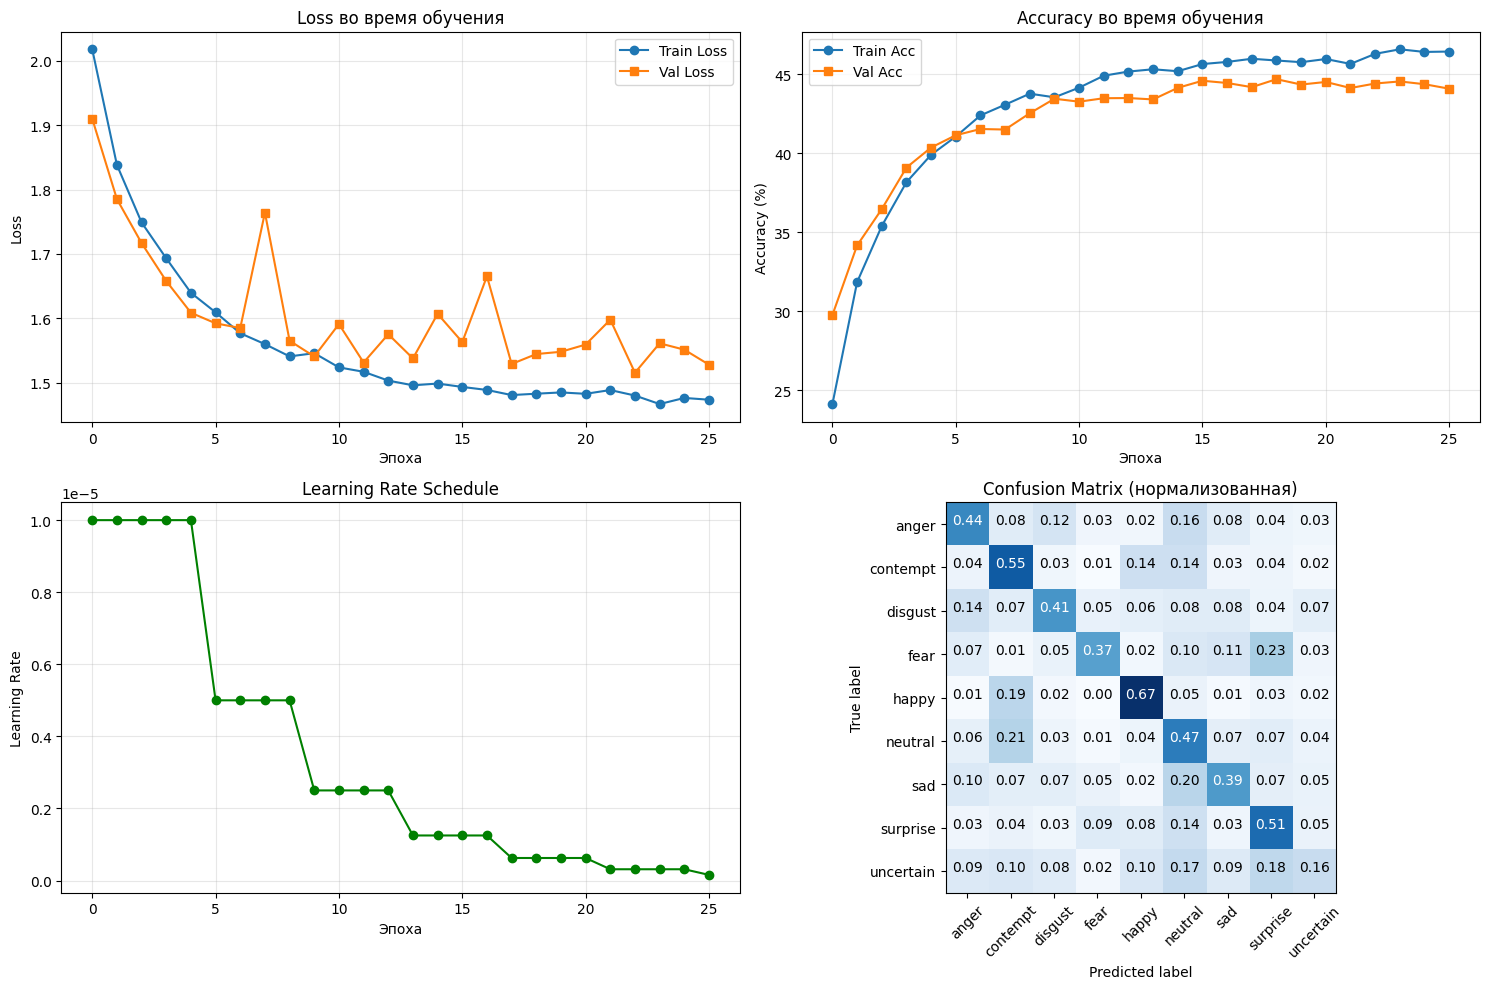


📊 Графики сохранены: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/results/training_history.png

6. Тестирование времени инференса...

Тестирование времени инференса (100 итераций)...


<Figure size 640x480 with 0 Axes>

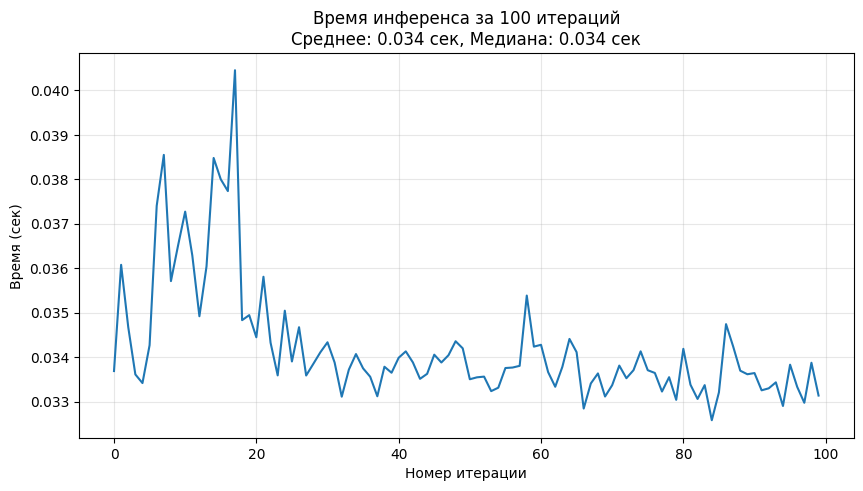

Требование ТЗ: < 0.33 сек на изображение
Результат: 0.034 сек ✅

7. Создание submission для Kaggle...

СОЗДАНИЕ SUBMISSION ДЛЯ KAGGLE
Найдено тестовых изображений: 5000


Обработка тестовых изображений: 100%|███████| 5000/5000 [03:25<00:00, 24.35it/s]



✅ Submission создан:
  Kaggle submission: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/results/kaggle_submission.csv
  Полные данные: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/results/submission_full_data.csv

📊 Анализ распределения предсказаний:


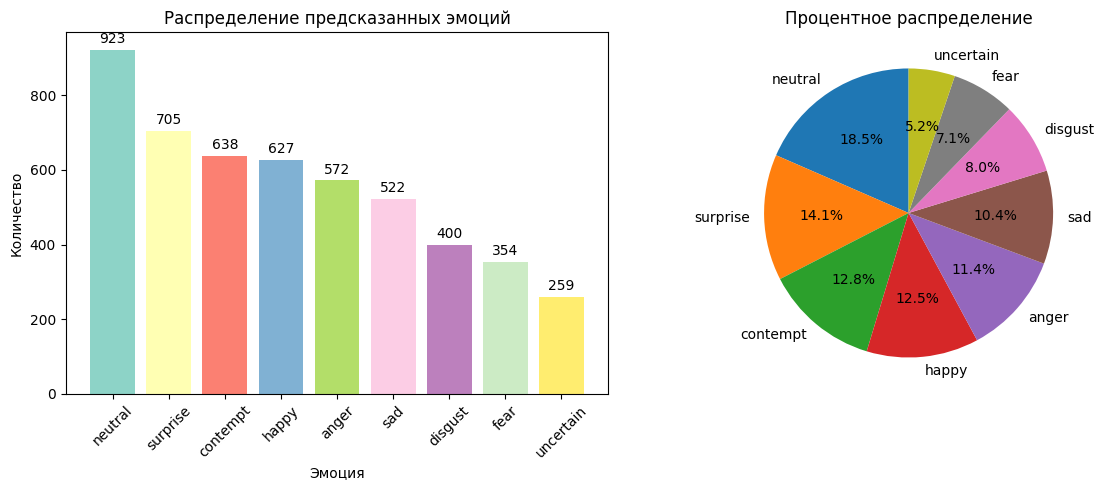


Статистика предсказаний:
  neutral: 923 (18.5%)
  surprise: 705 (14.1%)
  contempt: 638 (12.8%)
  happy: 627 (12.5%)
  anger: 572 (11.4%)
  sad: 522 (10.4%)
  disgust: 400 (8.0%)
  fear: 354 (7.1%)
  uncertain: 259 (5.2%)

📈 Распределение сохранено: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/results/prediction_distribution.csv

8. Сохранение финальной модели...
  💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/final_model.pth

✅ Все этапы завершены за 1482.0 минут


In [29]:
# ============================================================================
# ЗАПУСК ОБУЧЕНИЯ
# ============================================================================

if __name__ == "__main__":
    import time
    
    # Проверяем, что данные подготовлены
    if 'data_info' not in locals():
        print("❌ Данные не подготовлены. Сначала запустите подготовку данных.")
    else:
        print("=" * 60)
        print("ЗАПУСК ОБУЧЕНИЯ МОДЕЛИ")
        print("=" * 60)
        
        # Выбор модели (можно менять)
        # Доступные модели: 'efficientnet_b0', 'resnet18', 'resnet50', 'mobilenet_v3'
        model_name = 'efficientnet_b0'
        
        start_time = time.time()
        
        # Запуск обучения
        results = train_and_evaluate_model(data_info, model_name=model_name)
        
        elapsed_time = time.time() - start_time
        print(f"\n✅ Все этапы завершены за {elapsed_time/60:.1f} минут")
               

In [22]:
# ============================================================================
# ЗАГРУЗКА ПРЕДОБУЧЕННЫХ ВЕСОВ ResNet50
# ============================================================================

print(f"\n{'='*60}")
print("ЗАГРУЗКА ПРЕДОБУЧЕННЫХ ВЕСОВ ResNet50")
print(f"{'='*60}")

import torch
import torch.nn as nn
from torchvision import models

# Путь к скачанным весам
weights_path = "/Users/ostroverkhovpavel/Downloads/resnet50-0676ba61.pth"

class FacePretrainedResNet50(nn.Module):
    """ResNet50 с загруженными предобученными весами"""
    
    def __init__(self, num_classes=9, weights_path=None):
        super(FacePretrainedResNet50, self).__init__()
        
        self.num_classes = num_classes
        self.weights_path = weights_path
        
        print(f"Инициализация ResNet50...")
        
        # Создаем ResNet50 без предобученных весов ImageNet
        self.base_model = models.resnet50(pretrained=False)
        num_features = self.base_model.fc.in_features
        
        # Заменяем последний слой
        self.base_model.fc = nn.Identity()
        
        print(f"✅ Базовая ResNet50 создана")
        print(f"   Количество features: {num_features}")
        
        # Загружаем предобученные веса, если указан путь
        if weights_path:
            self._load_pretrained_weights(weights_path)
        
        # Наш классификатор эмоций
        self.emotion_classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        
        # Инициализация весов классификатора
        self._initialize_classifier()
    
    def _load_pretrained_weights(self, weights_path):
        """Загрузка предобученных весов"""
        print(f"\nЗагрузка предобученных весов из: {weights_path}")
        
        try:
            # Загружаем веса
            state_dict = torch.load(weights_path, map_location=config.DEVICE)
            
            # Проверяем структуру state_dict
            print(f"   Ключи в state_dict: {len(state_dict)}")
            
            # Пробуем загрузить веса
            # Возможные форматы: полный state_dict или только weights
            if 'state_dict' in state_dict:
                # Формат: {'state_dict': ..., 'optimizer': ...}
                model_state_dict = state_dict['state_dict']
                print(f"   Найден 'state_dict' ключ")
            elif 'model' in state_dict:
                # Альтернативный формат
                model_state_dict = state_dict['model']
                print(f"   Найден 'model' ключ")
            else:
                # Прямые веса модели
                model_state_dict = state_dict
                print(f"   Прямые веса модели")
            
            # Адаптируем ключи, если нужно
            new_state_dict = {}
            for k, v in model_state_dict.items():
                # Убираем префиксы, если есть
                if k.startswith('module.'):
                    k = k[7:]  # Убираем 'module.'
                if k.startswith('base_model.'):
                    k = k[11:]  # Убираем 'base_model.'
                
                new_state_dict[k] = v
            
            # Загружаем веса в base_model
            missing_keys, unexpected_keys = self.base_model.load_state_dict(new_state_dict, strict=False)
            
            print(f"✅ Веса загружены")
            print(f"   Отсутствующие ключи: {len(missing_keys)}")
            print(f"   Неожиданные ключи: {len(unexpected_keys)}")
            
            if missing_keys:
                print(f"   Первые 5 отсутствующих ключей:")
                for key in list(missing_keys)[:5]:
                    print(f"     - {key}")
            
            if unexpected_keys:
                print(f"   Первые 5 неожиданных ключей:")
                for key in list(unexpected_keys)[:5]:
                    print(f"     - {key}")
            
        except Exception as e:
            print(f"❌ Ошибка при загрузке весов: {e}")
            print(f"   Будет использована случайная инициализация")
    
    def _initialize_classifier(self):
        """Инициализация весов классификатора"""
        for m in self.emotion_classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
        print(f"✅ Классификатор инициализирован")
    
    def forward(self, x):
        features = self.base_model(x)
        output = self.emotion_classifier(features)
        return output
    
    def freeze_early_layers(self, freeze_layers=['conv1', 'bn1', 'layer1', 'layer2', 'layer3']):
        """Заморозка ранних слоев"""
        print(f"\nЗаморозка слоев: {freeze_layers}")
        
        total_params = 0
        frozen_params = 0
        
        for name, param in self.base_model.named_parameters():
            total_params += param.numel()
            
            # Проверяем, нужно ли заморозить этот параметр
            should_freeze = False
            for layer_name in freeze_layers:
                if name.startswith(layer_name):
                    should_freeze = True
                    break
            
            if should_freeze:
                param.requires_grad = False
                frozen_params += param.numel()
                print(f"  Заморожен: {name}")
        
        print(f"✅ Заморожено параметров: {frozen_params:,} из {total_params:,}")
        print(f"   Процент замороженных: {frozen_params/total_params*100:.1f}%")
    
    def get_trainable_params(self):
        """Получить количество обучаемых параметров"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Создаем модель с предобученными весами
print(f"\nСоздание ResNet50 с предобученными весами...")
resnet_pretrained = FacePretrainedResNet50(
    num_classes=len(finetune_idx_to_class),
    weights_path=weights_path
)

resnet_pretrained.to(config.DEVICE)
print(f"✅ Модель создана и перемещена на {config.DEVICE}")

# Статистика модели
total_params = sum(p.numel() for p in resnet_pretrained.parameters())
trainable_params = resnet_pretrained.get_trainable_params()

print(f"\n📊 СТАТИСТИКА МОДЕЛИ:")
print(f"  Всего параметров: {total_params:,}")
print(f"  Обучаемых параметров: {trainable_params:,}")
print(f"  Замороженных параметров: {total_params - trainable_params:,}")
print(f"  Процент обучаемых: {trainable_params/total_params*100:.1f}%")

# Тестируем forward pass
print(f"\n🧪 ТЕСТИРОВАНИЕ МОДЕЛИ:")
resnet_pretrained.eval()
with torch.no_grad():
    test_input = torch.randn(2, 3, config.IMG_SIZE, config.IMG_SIZE).to(config.DEVICE)
    test_output = resnet_pretrained(test_input)
    print(f"  Вход: {test_input.shape}")
    print(f"  Выход: {test_output.shape}")
    print(f"  ✅ Forward pass работает")

# Заморозка стратегии
print(f"\n🎯 ВЫБОР СТРАТЕГИИ ОБУЧЕНИЯ:")

# Проверяем, какие слои есть в модели
print(f"\nДоступные слои в ResNet50:")
for name, _ in resnet_pretrained.base_model.named_children():
    print(f"  - {name}")

# Выбираем стратегию
strategy_choice = 3  # 1: все разморозить, 2: заморозить все, 3: частичная заморозка

if strategy_choice == 1:
    print(f"\nСтратегия 1: Разморозить все слои")
    # Ничего не делаем, все уже разморожено по умолчанию
    
elif strategy_choice == 2:
    print(f"\nСтратегия 2: Заморозить всю базовую модель")
    # Замораживаем все параметры base_model
    for param in resnet_pretrained.base_model.parameters():
        param.requires_grad = False
    
elif strategy_choice == 3:
    print(f"\nСтратегия 3: Частичная заморозка (рекомендуется)")
    # Замораживаем ранние слои, оставляем layer4 и классификатор обучаемыми
    resnet_pretrained.freeze_early_layers(
        freeze_layers=['conv1', 'bn1', 'layer1', 'layer2', 'layer3']
    )

print(f"\nОбучаемых параметров после стратегии: {resnet_pretrained.get_trainable_params():,}")

# Настройка оптимизатора
print(f"\n⚙️  НАСТРОЙКА ОПТИМИЗАТОРА:")

# Разделяем параметры по слоям
layer_params = {'layer4': [], 'classifier': []}

for name, param in resnet_pretrained.named_parameters():
    if param.requires_grad:
        if 'layer4' in name:
            layer_params['layer4'].append(param)
        elif 'emotion_classifier' in name:
            layer_params['classifier'].append(param)

print(f"  Обучаемых параметров в layer4: {sum(p.numel() for p in layer_params['layer4']):,}")
print(f"  Обучаемых параметров в классификаторе: {sum(p.numel() for p in layer_params['classifier']):,}")

# Настраиваем оптимизатор с разными learning rates
learning_rate = 1e-4  # Базовый learning rate

optimizer_groups = []
if layer_params['layer4']:
    optimizer_groups.append({
        'params': layer_params['layer4'],
        'lr': learning_rate * 0.1  # Меньший LR для предобученных слоев
    })

if layer_params['classifier']:
    optimizer_groups.append({
        'params': layer_params['classifier'],
        'lr': learning_rate  # Больший LR для нового классификатора
    })

resnet_optimizer = optim.AdamW(optimizer_groups, weight_decay=1e-4)

print(f"\n  Learning rates:")
if layer_params['layer4']:
    print(f"    layer4: {learning_rate * 0.1:.2e}")
if layer_params['classifier']:
    print(f"    classifier: {learning_rate:.2e}")
print(f"    Weight decay: 1e-4")

# Настройка функции потерь
print(f"\n📉 НАСТРОЙКА ФУНКЦИИ ПОТЕРЬ:")

# Вычисляем веса классов для несбалансированного датасета
train_class_dist = train_loader.dataset.get_class_distribution()
class_counts = np.array([train_class_dist[cls] for cls in sorted(train_class_dist.keys())])
total_samples = sum(class_counts)
class_weights = total_samples / (len(class_counts) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(config.DEVICE)

# Используем Focal Loss с весами классов
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

criterion = FocalLoss(alpha=class_weights, gamma=2.0)

print(f"  Используется Focal Loss (gamma=2.0)")
print(f"  Веса классов: {class_weights.cpu().numpy().round(3)}")

# Настройка scheduler
print(f"\n📈 НАСТРОЙКА SCHEDULER:")

from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

scheduler = CosineAnnealingWarmRestarts(
    resnet_optimizer,
    T_0=10,  # Первый цикл - 10 эпох
    T_mult=2,  # Удваиваем длину цикла
    eta_min=learning_rate * 0.001  # Минимальный LR
)

print(f"  Используется CosineAnnealingWarmRestarts")
print(f"  T_0: 10 эпох, T_mult: 2")
print(f"  Начальный LR: {learning_rate:.2e}")
print(f"  Минимальный LR: {learning_rate * 0.001:.2e}")

# Сохранение начальной конфигурации
print(f"\n💾 СОХРАНЕНИЕ КОНФИГУРАЦИИ:")

config_path = config.MODELS_DIR / "resnet50_pretrained_config.pth"
torch.save({
    'model_state_dict': resnet_pretrained.state_dict(),
    'optimizer_state_dict': resnet_optimizer.state_dict(),
    'class_weights': class_weights,
    'idx_to_class': finetune_idx_to_class,
    'strategy': strategy_choice,
    'learning_rate': learning_rate,
    'freeze_layers': ['conv1', 'bn1', 'layer1', 'layer2', 'layer3'] if strategy_choice == 3 else []
}, config_path)

print(f"  Конфигурация сохранена: {config_path}")


print("✅ ResNet50 с предобученными весами настроена")
print(f"\n📊 ГОТОВО К ОБУЧЕНИЮ:")
print(f"  Модель: ResNet50 с предобученными весами")
print(f"  Параметров: {total_params:,}")
print(f"  Обучаемых: {resnet_pretrained.get_trainable_params():,}")
print(f"  Стратегия: {'Частичная заморозка' if strategy_choice == 3 else 'Полная разморозка'}")



ЗАГРУЗКА ПРЕДОБУЧЕННЫХ ВЕСОВ ResNet50

Создание ResNet50 с предобученными весами...
Инициализация ResNet50...
✅ Базовая ResNet50 создана
   Количество features: 2048

Загрузка предобученных весов из: /Users/ostroverkhovpavel/Downloads/resnet50-0676ba61.pth
   Ключи в state_dict: 267
   Прямые веса модели
✅ Веса загружены
   Отсутствующие ключи: 0
   Неожиданные ключи: 2
   Первые 5 неожиданных ключей:
     - fc.weight
     - fc.bias
✅ Классификатор инициализирован
✅ Модель создана и перемещена на cpu

📊 СТАТИСТИКА МОДЕЛИ:
  Всего параметров: 26,268,233
  Обучаемых параметров: 26,268,233
  Замороженных параметров: 0
  Процент обучаемых: 100.0%

🧪 ТЕСТИРОВАНИЕ МОДЕЛИ:
  Вход: torch.Size([2, 3, 224, 224])
  Выход: torch.Size([2, 9])
  ✅ Forward pass работает

🎯 ВЫБОР СТРАТЕГИИ ОБУЧЕНИЯ:

Доступные слои в ResNet50:
  - conv1
  - bn1
  - relu
  - maxpool
  - layer1
  - layer2
  - layer3
  - layer4
  - avgpool
  - fc

Стратегия 3: Частичная заморозка (рекомендуется)

Заморозка слоев: ['conv


ОБУЧЕНИЕ RESNET50 С ПРЕДОБУЧЕННЫМИ ВЕСАМИ

Проверка настроек перед обучением...
✅ Все настроено:
   Модель: ResNet50 с предобученными весами
   Train samples: 36511
   Val samples: 9118
   Классов: 9

Создание тренера...

🚀 ЗАПУСК ОБУЧЕНИЯ

НАЧАЛО ОБУЧЕНИЯ resnet50_pretrained_faces
Модель: FacePretrainedResNet50
Эпох: 30
Batch size: 32
Train samples: 36511
Val samples: 9118
Устройство: cpu
Обучаемых параметров: 17,724,937

📊 Эпоха [1/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            6.7864         2.3430
  Accuracy %      12.61         16.70
  LR              1.00e-05
  Time            4413.4 сек

  🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ!
    Accuracy: 16.70% (улучшение на 0.00%)
    Loss: 2.3430
    Сохранено: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_pretrained_faces_epoch_1_acc_16.70.pth

📊 Эпоха [2/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            4.5861         1.9066
  Accuracy %      14.68         19.76
  LR              9.76e-06
  Time            4419.4 сек

  🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ!
    Accuracy: 19.76% (улучшение на 0.00%)
    Loss: 1.9066
    Сохранено: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_pretrained_faces_epoch_2_acc_19.76.pth

📊 Эпоха [3/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            2.9263         1.8998
  Accuracy %      14.75         17.76
  LR              9.05e-06
  Time            4427.3 сек

  ⏳ Early stopping: 1/10
    Лучшая accuracy: 19.76% (эпоха 2)
    Текущая accuracy: 17.76% (разница: -2.01%)

📊 Эпоха [4/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            2.3189         2.0534
  Accuracy %      15.81         23.89
  LR              7.96e-06
  Time            4460.8 сек

  🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ!
    Accuracy: 23.89% (улучшение на 0.00%)
    Loss: 2.0534
    Сохранено: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_pretrained_faces_epoch_4_acc_23.89.pth

📊 Эпоха [5/30]


...

  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            1.4813         1.5607
  Accuracy %      36.52         38.53
  LR              1.55e-06
  Time            4819.5 сек

  🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ!
    Accuracy: 38.53% (улучшение на 0.00%)
    Loss: 1.5607
    Сохранено: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_pretrained_faces_epoch_26_acc_38.53.pth

📊 Эпоха [27/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            1.4988         1.4656
  Accuracy %      36.81         38.14
  LR              1.05e-06
  Time            4835.4 сек

  ⏳ Early stopping: 1/10
    Лучшая accuracy: 38.53% (эпоха 26)
    Текущая accuracy: 38.14% (разница: -0.38%)

📊 Эпоха [28/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            1.4857         2.0388
  Accuracy %      37.25         38.62
  LR              6.40e-07
  Time            4833.0 сек

  🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ!
    Accuracy: 38.62% (улучшение на 0.00%)
    Loss: 2.0388
    Сохранено: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_pretrained_faces_epoch_28_acc_38.62.pth

📊 Эпоха [29/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            1.4711         1.4354
  Accuracy %      37.32         39.01
  LR              3.42e-07
  Time            4837.7 сек

  🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ!
    Accuracy: 39.01% (улучшение на 0.00%)
    Loss: 1.4354
    Сохранено: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_pretrained_faces_epoch_29_acc_39.01.pth

📊 Эпоха [30/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            1.4806         1.4385
  Accuracy %      37.19         39.24
  LR              1.61e-07
  Time            4805.6 сек

  🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ!
    Accuracy: 39.24% (улучшение на 0.00%)
    Loss: 1.4385
    Сохранено: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_pretrained_faces_epoch_30_acc_39.24.pth

✅ ЗАГРУЖЕНА ЛУЧШАЯ МОДЕЛЬ
   Эпоха: 30
   Accuracy: 39.24%
   Loss: 1.4385

🏁 ОБУЧЕНИЕ ЗАВЕРШЕНО
   Общее время: 2362.4 минут
   Всего эпох: 30
   Лучшая accuracy: 39.24% (эпоха 30)
   Финальная accuracy: 39.24%
   Финальная модель: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_pretrained_faces_final.pth

📈 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


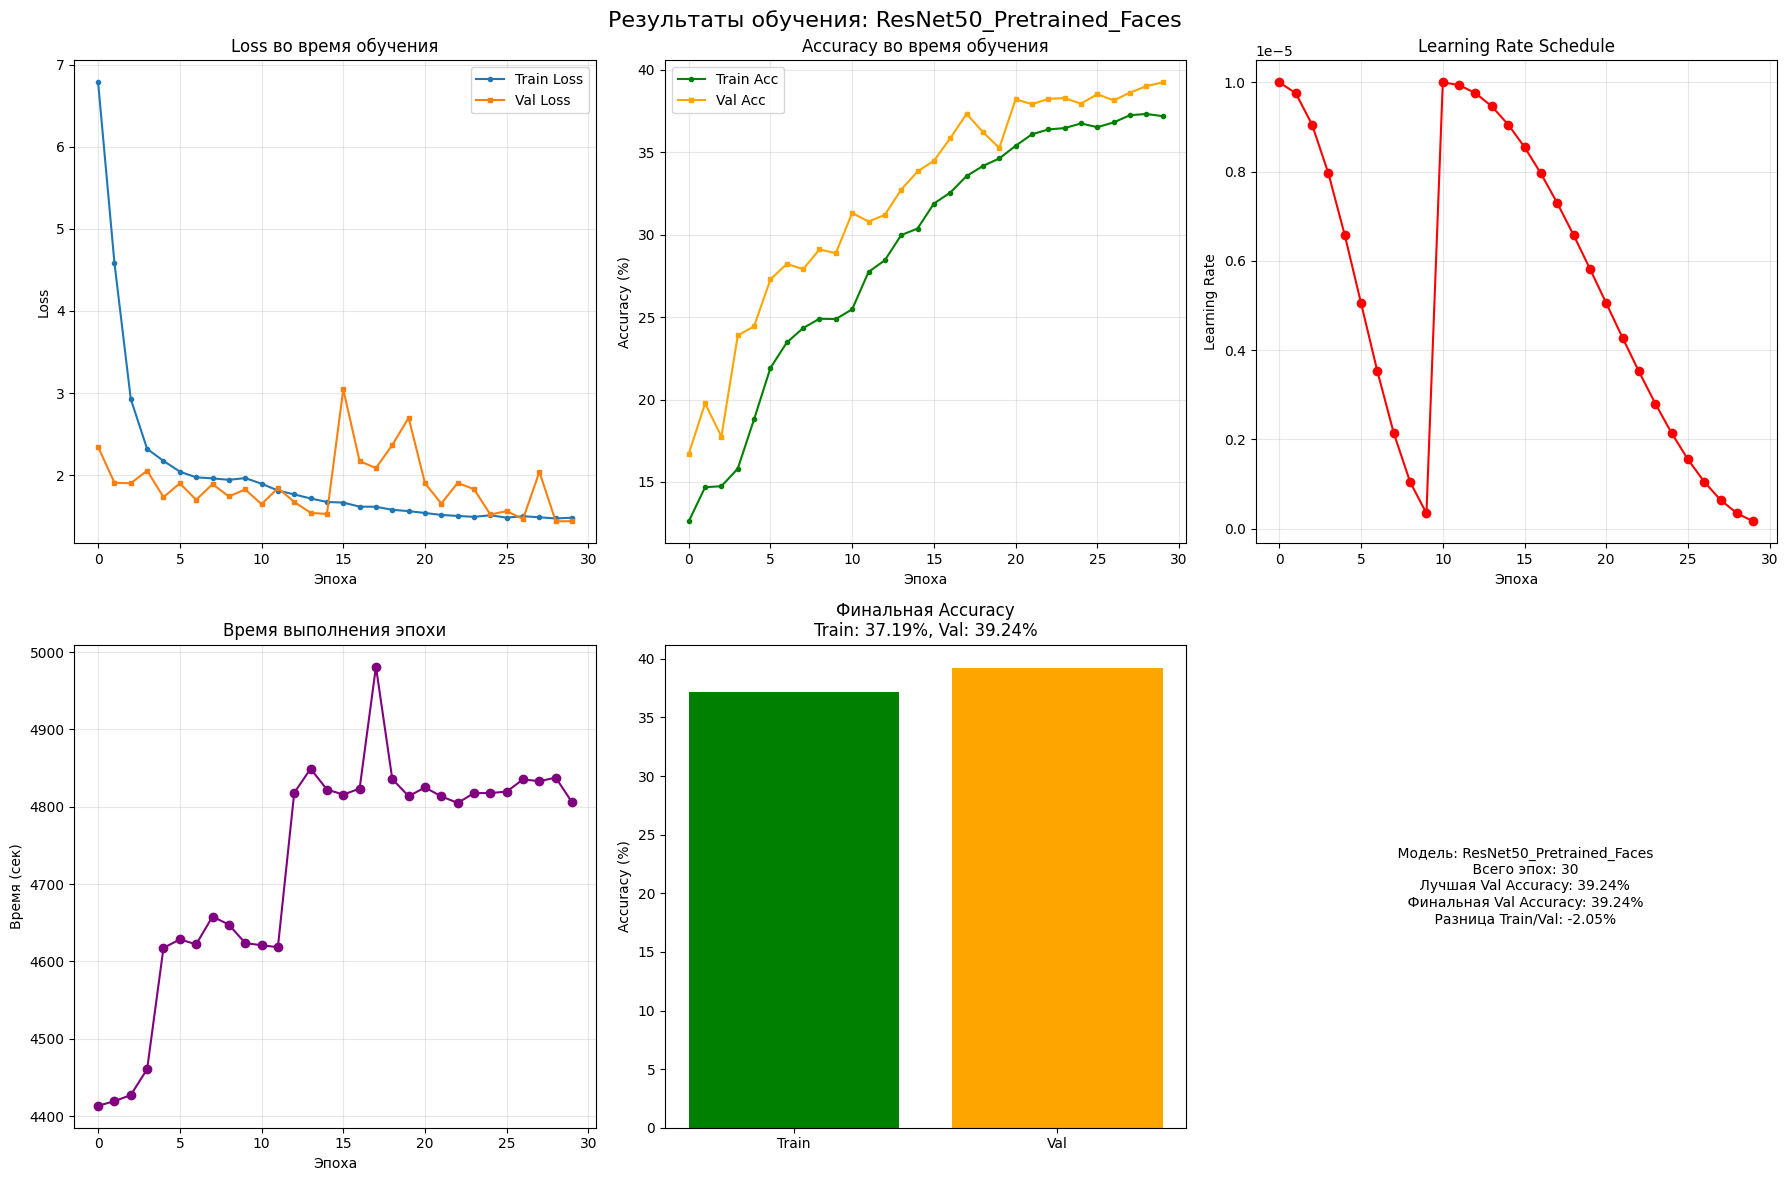


📊 Графики сохранены: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/results_finetune/training_history_ResNet50_Pretrained_Faces.png

📊 СРАВНЕНИЕ С EfficientNet-B0

EfficientNet-B0 (оригинальная):
  Лучшая accuracy: 44.57%

ResNet50 с предобученными весами:
  Лучшая accuracy: 39.24%
  Улучшение: -5.33%

⚠️  ResNet50 показала ХУДШИЙ результат
✅ Обучение ResNet50 завершено


In [11]:
# ============================================================================
# ОБУЧЕНИЕ RESNET50 С ПРЕДОБУЧЕННЫМИ ВЕСАМИ
# ============================================================================

print(f"\n{'='*60}")
print("ОБУЧЕНИЕ RESNET50 С ПРЕДОБУЧЕННЫМИ ВЕСАМИ")
print(f"{'='*60}")

import time
from datetime import datetime
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

class ResNetTrainer:
    """Тренер для обучения ResNet50"""
    
    def __init__(self, model, train_loader, val_loader, device, idx_to_class):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.idx_to_class = idx_to_class
        
        # История обучения
        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'learning_rates': [],
            'epoch_times': []
        }
        
        # Лучшие результаты
        self.best_val_acc = 0.0
        self.best_val_loss = float('inf')
        self.best_model_state = None
        self.best_epoch = 0
    
    def train_epoch(self, optimizer, criterion, epoch):
        """Обучение на одной эпохе"""
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        pbar = tqdm(self.train_loader, desc=f"Train Epoch {epoch}", leave=False)
        
        for batch_idx, (inputs, labels) in enumerate(pbar):
            # Пропускаем слишком маленькие батчи
            if inputs.size(0) < 2:
                continue
                
            inputs, labels = inputs.to(self.device), labels.to(self.device)
            
            optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping для стабильности
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            # Статистика
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # Обновление progress bar
            if batch_idx % 10 == 0:
                pbar.set_postfix({
                    'loss': running_loss / (batch_idx + 1),
                    'acc': 100. * correct / total if total > 0 else 0
                })
        
        epoch_loss = running_loss / len(self.train_loader) if len(self.train_loader) > 0 else 0
        epoch_acc = 100. * correct / total if total > 0 else 0
        
        return epoch_loss, epoch_acc
    
    def validate(self, criterion, epoch):
        """Валидация модели"""
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            pbar = tqdm(self.val_loader, desc=f"Val Epoch {epoch}", leave=False)
            
            for batch_idx, (inputs, labels) in enumerate(pbar):
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                
                outputs = self.model(inputs)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                # Сохраняем для confusion matrix
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
                if batch_idx % 5 == 0:
                    pbar.set_postfix({
                        'loss': running_loss / (batch_idx + 1),
                        'acc': 100. * correct / total if total > 0 else 0
                    })
        
        epoch_loss = running_loss / len(self.val_loader) if len(self.val_loader) > 0 else 0
        epoch_acc = 100. * correct / total if total > 0 else 0
        
        return epoch_loss, epoch_acc, all_preds, all_labels
    
    def train(self, num_epochs, optimizer, criterion, scheduler=None, 
              early_stopping_patience=15, model_name="resnet50_pretrained"):
        """Полный цикл обучения"""
        
        print(f"\n{'='*60}")
        print(f"НАЧАЛО ОБУЧЕНИЯ {model_name}")
        print(f"{'='*60}")
        print(f"Модель: {self.model.__class__.__name__}")
        print(f"Эпох: {num_epochs}")
        print(f"Batch size: {self.train_loader.batch_size}")
        print(f"Train samples: {len(self.train_loader.dataset)}")
        print(f"Val samples: {len(self.val_loader.dataset)}")
        print(f"Устройство: {self.device}")
        print(f"Обучаемых параметров: {self.model.get_trainable_params():,}")
        print(f"{'='*60}")
        
        start_time = time.time()
        patience_counter = 0
        
        for epoch in range(num_epochs):
            epoch_start = time.time()
            print(f"\n📊 Эпоха [{epoch+1}/{num_epochs}]")
            
            # Обучение
            train_loss, train_acc = self.train_epoch(optimizer, criterion, epoch+1)
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            
            # Валидация
            val_loss, val_acc, val_preds, val_labels = self.validate(criterion, epoch+1)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            
            # Learning rate
            current_lr = optimizer.param_groups[0]['lr']
            self.history['learning_rates'].append(current_lr)
            
            # Время эпохи
            epoch_time = time.time() - epoch_start
            self.history['epoch_times'].append(epoch_time)
            
            # Обновление scheduler
            if scheduler:
                if isinstance(scheduler, CosineAnnealingWarmRestarts):
                    scheduler.step()
                else:
                    scheduler.step(val_loss)
            
            # Вывод результатов
            print(f"  {'Metric':<15} {'Train':<12} {'Val':<12}")
            print(f"  {'-'*15} {'-'*12} {'-'*12}")
            print(f"  {'Loss':<15} {train_loss:.4f}{'':<8} {val_loss:.4f}")
            print(f"  {'Accuracy %':<15} {train_acc:.2f}{'':<8} {val_acc:.2f}")
            print(f"  {'LR':<15} {current_lr:.2e}")
            print(f"  {'Time':<15} {epoch_time:.1f} сек")
            
            # Сохранение лучшей модели
            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.best_val_loss = val_loss
                self.best_model_state = self.model.state_dict().copy()
                self.best_epoch = epoch + 1
                patience_counter = 0
                
                # Сохранение модели
                model_path = config.MODELS_DIR / f"{model_name}_epoch_{epoch+1}_acc_{val_acc:.2f}.pth"
                self.save_model(model_path, epoch=epoch, val_acc=val_acc, val_loss=val_loss)
                
                print(f"\n  🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ!")
                print(f"    Accuracy: {val_acc:.2f}% (улучшение на {val_acc - self.best_val_acc:.2f}%)")
                print(f"    Loss: {val_loss:.4f}")
                print(f"    Сохранено: {model_path}")
                
                # Confusion matrix для лучшей модели
                if len(val_preds) > 0:
                    self.plot_confusion_matrix(val_preds, val_labels, epoch+1)
            else:
                patience_counter += 1
                improvement = val_acc - self.best_val_acc
                print(f"\n  ⏳ Early stopping: {patience_counter}/{early_stopping_patience}")
                print(f"    Лучшая accuracy: {self.best_val_acc:.2f}% (эпоха {self.best_epoch})")
                print(f"    Текущая accuracy: {val_acc:.2f}% (разница: {improvement:+.2f}%)")
            
            # Early stopping
            if patience_counter >= early_stopping_patience:
                print(f"\n{'='*60}")
                print(f"⏹️  EARLY STOPPING на эпохе {epoch+1}")
                print(f"   Лучшая accuracy достигнута на эпохе {self.best_epoch}: {self.best_val_acc:.2f}%")
                print(f"{'='*60}")
                break
            
            # Промежуточные сохранения каждые 5 эпох
            if (epoch + 1) % 5 == 0:
                checkpoint_path = config.MODELS_DIR / f"{model_name}_checkpoint_epoch_{epoch+1}.pth"
                self.save_checkpoint(checkpoint_path, epoch, optimizer, scheduler)
        
        total_time = time.time() - start_time
        
        # Загрузка лучшей модели
        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
            print(f"\n{'='*60}")
            print(f"✅ ЗАГРУЖЕНА ЛУЧШАЯ МОДЕЛЬ")
            print(f"{'='*60}")
            print(f"   Эпоха: {self.best_epoch}")
            print(f"   Accuracy: {self.best_val_acc:.2f}%")
            print(f"   Loss: {self.best_val_loss:.4f}")
        
        # Сохранение финальной модели
        final_model_path = config.MODELS_DIR / f"{model_name}_final.pth"
        self.save_model(final_model_path, epoch=num_epochs, 
                       val_acc=self.best_val_acc, val_loss=self.best_val_loss)
        
        print(f"\n{'='*60}")
        print(f"🏁 ОБУЧЕНИЕ ЗАВЕРШЕНО")
        print(f"{'='*60}")
        print(f"   Общее время: {total_time/60:.1f} минут")
        print(f"   Всего эпох: {epoch+1}")
        print(f"   Лучшая accuracy: {self.best_val_acc:.2f}% (эпоха {self.best_epoch})")
        print(f"   Финальная accuracy: {self.history['val_acc'][-1]:.2f}%")
        print(f"   Финальная модель: {final_model_path}")
        print(f"{'='*60}")
        
        return self.history
    
    def plot_confusion_matrix(self, predictions, labels, epoch):
        """Визуализация confusion matrix"""
        if len(predictions) == 0:
            return
        
        cm = confusion_matrix(labels, predictions)
        
        # Нормализация
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                   xticklabels=self.idx_to_class.values(),
                   yticklabels=self.idx_to_class.values())
        plt.title(f'Confusion Matrix (Эпоха {epoch})')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        
        # Сохранение
        cm_path = config.RESULTS_DIR / f"confusion_matrix_epoch_{epoch}.png"
        plt.savefig(cm_path, dpi=150, bbox_inches='tight')
        plt.close()
    
    def save_model(self, save_path, epoch=None, val_acc=None, val_loss=None):
        """Сохранение модели"""
        torch.save({
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'best_val_acc': self.best_val_acc,
            'best_val_loss': self.best_val_loss,
            'history': self.history,
            'model_class': self.model.__class__.__name__,
            'model_config': {
                'architecture': 'ResNet50_Pretrained',
                'num_classes': self.model.num_classes,
                'weights_source': 'Pretrained weights'
            },
            'idx_to_class': self.idx_to_class,
            'val_acc': val_acc,
            'val_loss': val_loss,
            'timestamp': datetime.now().isoformat()
        }, save_path)
    
    def save_checkpoint(self, save_path, epoch, optimizer, scheduler):
        """Сохранение checkpoint"""
        torch.save({
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
            'history': self.history,
            'best_val_acc': self.best_val_acc,
            'best_val_loss': self.best_val_loss,
            'idx_to_class': self.idx_to_class
        }, save_path)

def plot_training_history(history, model_name):
    """Визуализация истории обучения"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=3)
    axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='s', markersize=3)
    axes[0, 0].set_xlabel('Эпоха')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss во время обучения')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train Acc', marker='o', markersize=3, color='green')
    axes[0, 1].plot(history['val_acc'], label='Val Acc', marker='s', markersize=3, color='orange')
    axes[0, 1].set_xlabel('Эпоха')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Accuracy во время обучения')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Learning Rate
    if history['learning_rates']:
        axes[0, 2].plot(history['learning_rates'], marker='o', color='red')
        axes[0, 2].set_xlabel('Эпоха')
        axes[0, 2].set_ylabel('Learning Rate')
        axes[0, 2].set_title('Learning Rate Schedule')
        axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Время эпохи
    if history['epoch_times']:
        axes[1, 0].plot(history['epoch_times'], marker='o', color='purple')
        axes[1, 0].set_xlabel('Эпоха')
        axes[1, 0].set_ylabel('Время (сек)')
        axes[1, 0].set_title('Время выполнения эпохи')
        axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Train vs Val Accuracy сравнение
    axes[1, 1].bar(['Train', 'Val'], 
                  [history['train_acc'][-1], history['val_acc'][-1]],
                  color=['green', 'orange'])
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].set_title(f'Финальная Accuracy\nTrain: {history["train_acc"][-1]:.2f}%, Val: {history["val_acc"][-1]:.2f}%')
    
    # 6. Сводка
    summary_text = f"""
    Модель: {model_name}
    Всего эпох: {len(history['train_acc'])}
    Лучшая Val Accuracy: {max(history['val_acc']):.2f}%
    Финальная Val Accuracy: {history['val_acc'][-1]:.2f}%
    Разница Train/Val: {history['train_acc'][-1] - history['val_acc'][-1]:.2f}%
    """
    
    axes[1, 2].text(0.5, 0.5, summary_text, ha='center', va='center', 
                   transform=axes[1, 2].transAxes, fontsize=10)
    axes[1, 2].axis('off')
    
    plt.suptitle(f'Результаты обучения: {model_name}', fontsize=16)
    plt.tight_layout()
    
    # Сохранение
    plot_path = config.RESULTS_DIR / f"training_history_{model_name}.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Графики сохранены: {plot_path}")

# Проверяем, что все настроено
print(f"\nПроверка настроек перед обучением...")

if 'resnet_pretrained' not in locals():
    print(f"❌ Модель не найдена!")
elif 'train_loader' not in locals():
    print(f"❌ DataLoader'ы не найдены!")
else:
    print(f"✅ Все настроено:")
    print(f"   Модель: ResNet50 с предобученными весами")
    print(f"   Train samples: {len(train_loader.dataset)}")
    print(f"   Val samples: {len(val_loader.dataset)}")
    print(f"   Классов: {len(finetune_idx_to_class)}")
    
    # Создаем тренер
    print(f"\nСоздание тренера...")
    trainer = ResNetTrainer(
        model=resnet_pretrained,
        train_loader=train_loader,
        val_loader=val_loader,
        device=config.DEVICE,
        idx_to_class=finetune_idx_to_class
    )
    
    # Запуск обучения
    print(f"\n{'='*60}")
    print("🚀 ЗАПУСК ОБУЧЕНИЯ")
    print(f"{'='*60}")
    
    history = trainer.train(
        num_epochs=30,  # Меньше эпох для fine-tuning
        optimizer=resnet_optimizer,
        criterion=criterion,
        scheduler=scheduler,
        early_stopping_patience=10,  # Больше patience для fine-tuning
        model_name="resnet50_pretrained_faces"
    )
    
    # Визуализация результатов
    print(f"\n{'='*60}")
    print("📈 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
    print(f"{'='*60}")
    
    plot_training_history(history, "ResNet50_Pretrained_Faces")
    
    # Сравнение с оригинальной моделью
    print(f"\n{'='*60}")
    print("📊 СРАВНЕНИЕ С EfficientNet-B0")
    print(f"{'='*60}")
    
    print(f"\nEfficientNet-B0 (оригинальная):")
    print(f"  Лучшая accuracy: 44.57%")
    
    
    print(f"\nResNet50 с предобученными весами:")
    print(f"  Лучшая accuracy: {trainer.best_val_acc:.2f}%")
    print(f"  Улучшение: {trainer.best_val_acc - 44.57:+.2f}%")
    
    if trainer.best_val_acc > 44.57:
        print(f"\n🎉 ResNet50 показала ЛУЧШИЙ результат!")
        
    else:
        print(f"\n⚠️  ResNet50 показала ХУДШИЙ результат")
        
    
   
    
print("✅ Обучение ResNet50 завершено")


In [23]:
# ============================================================================
# ШАГ 1: СОЗДАНИЕ RESNET50 С ПОЛНОЙ РАЗМОРОЗКОЙ И ОПТИМИЗАЦИЕЙ
# ============================================================================

print(f"\n{'='*60}")
print("ШАГ 1: НАСТРОЙКА RESNET50 С ПОЛНОЙ РАЗМОРОЗКОЙ")
print(f"{'='*60}")

import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim

class ResNet50FullUnfreeze(nn.Module):
    """ResNet50 с полной разморозкой для fine-tuning"""
    
    def __init__(self, num_classes=9, weights_path=None):
        super(ResNet50FullUnfreeze, self).__init__()
        
        self.num_classes = num_classes
        self.weights_path = weights_path
        
        print(f"Инициализация ResNet50 с полной разморозкой...")
        
        # Создаем ResNet50 без предобученных весов ImageNet
        self.base_model = models.resnet50(pretrained=False)
        num_features = self.base_model.fc.in_features
        
        # Заменяем последний слой
        self.base_model.fc = nn.Identity()
        
        print(f"✅ Базовая ResNet50 создана")
        print(f"   Количество features: {num_features}")
        
        # Загружаем предобученные веса, если указан путь
        if weights_path:
            self._load_pretrained_weights(weights_path)
        
        # Наш классификатор эмоций (упрощенный по сравнению с предыдущим)
        self.emotion_classifier = nn.Sequential(
            nn.Dropout(0.3),  # Уменьшили dropout
            nn.Linear(num_features, 512),  # Упростили архитектуру
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        
        # Инициализация весов классификатора
        self._initialize_classifier()
        
        # ВАЖНО: НЕ ЗАМОРАЖИВАЕМ НИЧЕГО!
        print(f"✅ Все слои разморожены для обучения")
    
    def _load_pretrained_weights(self, weights_path):
        """Загрузка предобученных весов"""
        print(f"\nЗагрузка предобученных весов из: {weights_path}")
        
        try:
            # Загружаем веса
            state_dict = torch.load(weights_path, map_location=config.DEVICE)
            
            # Пробуем загрузить веса
            if 'state_dict' in state_dict:
                model_state_dict = state_dict['state_dict']
                print(f"   Найден 'state_dict' ключ")
            elif 'model' in state_dict:
                model_state_dict = state_dict['model']
                print(f"   Найден 'model' ключ")
            else:
                model_state_dict = state_dict
                print(f"   Прямые веса модели")
            
            # Адаптируем ключи, если нужно
            new_state_dict = {}
            for k, v in model_state_dict.items():
                if k.startswith('module.'):
                    k = k[7:]
                if k.startswith('base_model.'):
                    k = k[11:]
                new_state_dict[k] = v
            
            # Загружаем веса в base_model
            missing_keys, unexpected_keys = self.base_model.load_state_dict(new_state_dict, strict=False)
            
            print(f"✅ Веса загружены")
            print(f"   Отсутствующие ключи: {len(missing_keys)}")
            print(f"   Неожиданные ключи: {len(unexpected_keys)}")
            
        except Exception as e:
            print(f"❌ Ошибка при загрузке весов: {e}")
            print(f"   Будет использована случайная инициализация")
    
    def _initialize_classifier(self):
        """Инициализация весов классификатора"""
        for m in self.emotion_classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
        print(f"✅ Классификатор инициализирован")
    
    def forward(self, x):
        features = self.base_model(x)
        output = self.emotion_classifier(features)
        return output
    
    def get_trainable_params(self):
        """Получить количество обучаемых параметров"""
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        return trainable, total

# Создаем модель с полной разморозкой
print(f"\nСоздание ResNet50 с полной разморозкой...")
resnet_full_unfreeze = ResNet50FullUnfreeze(
    num_classes=len(finetune_idx_to_class),
    weights_path=weights_path
)

resnet_full_unfreeze.to(config.DEVICE)
print(f"✅ Модель создана и перемещена на {config.DEVICE}")

# Статистика модели
trainable_params, total_params = resnet_full_unfreeze.get_trainable_params()

print(f"\n📊 СТАТИСТИКА МОДЕЛИ (ПОЛНАЯ РАЗМОРОЗКА):")
print(f"  Всего параметров: {total_params:,}")
print(f"  Обучаемых параметров: {trainable_params:,}")
print(f"  Замороженных параметров: {total_params - trainable_params:,}")
print(f"  Процент обучаемых: {trainable_params/total_params*100:.1f}%")

# Тестируем forward pass
print(f"\n🧪 ТЕСТИРОВАНИЕ МОДЕЛИ:")
resnet_full_unfreeze.eval()
with torch.no_grad():
    test_input = torch.randn(2, 3, config.IMG_SIZE, config.IMG_SIZE).to(config.DEVICE)
    test_output = resnet_full_unfreeze(test_input)
    print(f"  Вход: {test_input.shape}")
    print(f"  Выход: {test_output.shape}")
    print(f"  ✅ Forward pass работает")

print(f"\n✅ Шаг 1 завершен: ResNet50 с полной разморозкой создана")


ШАГ 1: НАСТРОЙКА RESNET50 С ПОЛНОЙ РАЗМОРОЗКОЙ

Создание ResNet50 с полной разморозкой...
Инициализация ResNet50 с полной разморозкой...
✅ Базовая ResNet50 создана
   Количество features: 2048

Загрузка предобученных весов из: /Users/ostroverkhovpavel/Downloads/resnet50-0676ba61.pth
   Прямые веса модели
✅ Веса загружены
   Отсутствующие ключи: 0
   Неожиданные ключи: 2
✅ Классификатор инициализирован
✅ Все слои разморожены для обучения
✅ Модель создана и перемещена на cpu

📊 СТАТИСТИКА МОДЕЛИ (ПОЛНАЯ РАЗМОРОЗКА):
  Всего параметров: 24,562,761
  Обучаемых параметров: 24,562,761
  Замороженных параметров: 0
  Процент обучаемых: 100.0%

🧪 ТЕСТИРОВАНИЕ МОДЕЛИ:
  Вход: torch.Size([2, 3, 224, 224])
  Выход: torch.Size([2, 9])
  ✅ Forward pass работает

✅ Шаг 1 завершен: ResNet50 с полной разморозкой создана


In [24]:
# ============================================================================
# ШАГ 2: НАСТРОЙКА ОПТИМИЗАТОРА И ФУНКЦИИ ПОТЕРЬ
# ============================================================================

print(f"\n{'='*60}")
print("ШАГ 2: НАСТРОЙКА ОПТИМИЗАТОРА И ФУНКЦИИ ПОТЕРЬ")
print(f"{'='*60}")

import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, ReduceLROnPlateau

# Настройка оптимизатора
print(f"\n⚙️ НАСТРОЙКА ОПТИМИЗАТОРА:")

# Единый learning rate для всех слоев (как в EfficientNet-B0)
learning_rate = 1e-4

# Оптимизатор AdamW с weight decay
optimizer_full = optim.AdamW(
    resnet_full_unfreeze.parameters(),
    lr=learning_rate,
    weight_decay=1e-4  # Регуляризация
)

print(f"  Оптимизатор: AdamW")
print(f"  Learning rate: {learning_rate:.2e}")
print(f"  Weight decay: 1e-4")
print(f"  Все параметры обучаются с одинаковым LR")

# Настройка функции потерь
print(f"\n📉 НАСТРОЙКА ФУНКЦИИ ПОТЕРЬ:")

# Используем те же веса классов, что и раньше
train_class_dist = train_loader.dataset.get_class_distribution()
class_counts = np.array([train_class_dist[cls] for cls in sorted(train_class_dist.keys())])
total_samples = sum(class_counts)
class_weights = total_samples / (len(class_counts) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(config.DEVICE)

# Focal Loss для борьбы с дисбалансом
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

criterion_full = FocalLoss(alpha=class_weights, gamma=2.0)

print(f"  Используется Focal Loss (gamma=2.0)")
print(f"  Веса классов: {class_weights.cpu().numpy().round(3)}")

# Настройка scheduler
print(f"\n📈 НАСТРОЙКА SCHEDULER:")

# Используем ReduceLROnPlateau (как в EfficientNet-B0)
scheduler_full = ReduceLROnPlateau(
    optimizer_full,
    mode='max',  # Увеличиваем при увеличении accuracy
    patience=3,   # Ждем 3 эпохи без улучшений
    factor=0.5,   # Уменьшаем LR в 2 раза
    verbose=True,
    min_lr=1e-6   # Минимальный learning rate
)

print(f"  Используется ReduceLROnPlateau")
print(f"  Режим: 'max' (увеличиваем при росте accuracy)")
print(f"  Patience: 3 эпохи")
print(f"  Factor: 0.5 (уменьшение LR в 2 раза)")
print(f"  Начальный LR: {learning_rate:.2e}")
print(f"  Минимальный LR: 1e-6")

print(f"\n✅ Шаг 2 завершен: Оптимизатор и функция потерь настроены")


ШАГ 2: НАСТРОЙКА ОПТИМИЗАТОРА И ФУНКЦИИ ПОТЕРЬ

⚙️ НАСТРОЙКА ОПТИМИЗАТОРА:
  Оптимизатор: AdamW
  Learning rate: 1.00e-04
  Weight decay: 1e-4
  Все параметры обучаются с одинаковым LR

📉 НАСТРОЙКА ФУНКЦИИ ПОТЕРЬ:
  Используется Focal Loss (gamma=2.0)
  Веса классов: [0.807 1.731 1.8   1.194 0.887 0.814 0.83  0.87  0.926]

📈 НАСТРОЙКА SCHEDULER:
  Используется ReduceLROnPlateau
  Режим: 'max' (увеличиваем при росте accuracy)
  Patience: 3 эпохи
  Factor: 0.5 (уменьшение LR в 2 раза)
  Начальный LR: 1.00e-04
  Минимальный LR: 1e-6

✅ Шаг 2 завершен: Оптимизатор и функция потерь настроены


In [25]:
# ============================================================================
# ШАГ 3: ОБНОВЛЕНИЕ АУГМЕНТАЦИЙ ДО УРОВНЯ EFFICIENTNET-B0
# ============================================================================

print(f"\n{'='*60}")
print("ШАГ 3: ОБНОВЛЕНИЕ АУГМЕНТАЦИЙ ДО УРОВНЯ EFFICIENTNET-B0")
print(f"{'='*60}")

from torchvision import transforms
import torchvision.transforms.functional as TF

class BalancedAugmentationTransforms:
    """Сбалансированные аугментации как в EfficientNet-B0"""
    
    @staticmethod
    def get_train_transforms(img_size=224):
        """Аугментации для тренировочных данных (как в EfficientNet-B0)"""
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),  # Было 20, стало 15
            transforms.ColorJitter(
                brightness=0.2,  # Было 0.3, стало 0.2
                contrast=0.2,
                saturation=0.2,
                hue=0.1
            ),
            transforms.RandomAffine(
                degrees=0,
                translate=(0.1, 0.1),  # Было 0.15, стало 0.1
                scale=(0.9, 1.1),
                shear=10
            ),
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=3)
            ], p=0.3),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])
    
    @staticmethod
    def get_val_transforms(img_size=224):
        """Преобразования для валидационных данных"""
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

print(f"\n📊 СРАВНЕНИЕ АУГМЕНТАЦИЙ:")
print(f"\nБЫЛО (для ResNet50):")
print(f"  RandomRotation: degrees=20")
print(f"  ColorJitter: brightness=0.3")
print(f"  RandomAffine: translate=(0.15, 0.15)")
print(f"  RandomErasing: p=0.2")

print(f"\nСТАЛО (как в EfficientNet-B0):")
print(f"  RandomRotation: degrees=15")
print(f"  ColorJitter: brightness=0.2")
print(f"  RandomAffine: translate=(0.1, 0.1)")
print(f"  RandomErasing: УБРАНА")

print(f"\n✅ Шаг 3 завершен: Аугментации обновлены до уровня EfficientNet-B0")


ШАГ 3: ОБНОВЛЕНИЕ АУГМЕНТАЦИЙ ДО УРОВНЯ EFFICIENTNET-B0

📊 СРАВНЕНИЕ АУГМЕНТАЦИЙ:

БЫЛО (для ResNet50):
  RandomRotation: degrees=20
  ColorJitter: brightness=0.3
  RandomAffine: translate=(0.15, 0.15)
  RandomErasing: p=0.2

СТАЛО (как в EfficientNet-B0):
  RandomRotation: degrees=15
  ColorJitter: brightness=0.2
  RandomAffine: translate=(0.1, 0.1)
  RandomErasing: УБРАНА

✅ Шаг 3 завершен: Аугментации обновлены до уровня EfficientNet-B0


In [31]:
# ============================================================================
# ЗАГРУЗКА МЕТАДАННЫХ И ПОДГОТОВКА ДАННЫХ
# ============================================================================

print(f"\n{'='*60}")
print("ЗАГРУЗКА МЕТАДАННЫХ И ПОДГОТОВКА ДАННЫХ")
print(f"{'='*60}")

from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

# Загружаем метаданные
print("Загрузка метаданных...")
metadata_path = config.PROCESSED_DIR / "train_processed_metadata.csv"
if metadata_path.exists():
    train_metadata = pd.read_csv(metadata_path)
    print(f"✅ Загружено {len(train_metadata)} записей")
    
    # Фильтруем только успешные
    train_metadata = train_metadata[train_metadata['success'] == True]
    print(f"✅ Успешно обработанных: {len(train_metadata)}")
else:
    print(f"❌ Файл метаданных не найден: {metadata_path}")
    train_metadata = None

if train_metadata is not None:
    # Создаем стратифицированное разделение
    print("\nСоздание стратифицированного разделения...")
    
    train_dfs = []
    val_dfs = []
    
    for class_name in train_metadata['class'].unique():
        class_df = train_metadata[train_metadata['class'] == class_name]
        
        # Случайное перемешивание
        class_df = class_df.sample(frac=1, random_state=42).reset_index(drop=True)
        
        # Вычисляем размер валидации (20%)
        n_val = int(len(class_df) * 0.2)
        
        # Разделяем
        class_val_df = class_df.iloc[:n_val]
        class_train_df = class_df.iloc[n_val:]
        
        train_dfs.append(class_train_df)
        val_dfs.append(class_val_df)
        
        print(f"  {class_name}: train={len(class_train_df)}, val={len(class_val_df)}")
    
    # Объединяем
    train_df = pd.concat(train_dfs, ignore_index=True).sample(frac=1, random_state=42)
    val_df = pd.concat(val_dfs, ignore_index=True).sample(frac=1, random_state=42)
    
    print(f"\n✅ Разделение создано:")
    print(f"  Train: {len(train_df)} изображений")
    print(f"  Val: {len(val_df)} изображений")
    
    # Сохраняем разделенные данные
    train_split_path = config.RESULTS_DIR / "train_split_new.csv"
    val_split_path = config.RESULTS_DIR / "val_split_new.csv"
    
    train_df.to_csv(train_split_path, index=False)
    val_df.to_csv(val_split_path, index=False)
    
    print(f"  Train split сохранен: {train_split_path}")
    print(f"  Val split сохранен: {val_split_path}")
    
    # Создаем маппинг классов
    classes = sorted(train_df['class'].unique())
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    idx_to_class = {idx: cls for idx, cls in enumerate(classes)}
    
    print(f"\n📊 МАППИНГ КЛАССОВ:")
    for idx, cls in idx_to_class.items():
        train_count = len(train_df[train_df['class'] == cls])
        val_count = len(val_df[val_df['class'] == cls])
        print(f"  {idx}: {cls} (train={train_count}, val={val_count})")
    
    print(f"\n✅ Данные подготовлены!")
else:
    print(f"\n❌ Не удалось подготовить данные!")


ЗАГРУЗКА МЕТАДАННЫХ И ПОДГОТОВКА ДАННЫХ
Загрузка метаданных...
✅ Загружено 49310 записей
✅ Успешно обработанных: 45629

Создание стратифицированного разделения...
  happy: train=4564, val=1140
  uncertain: train=4386, val=1096
  contempt: train=2341, val=585
  sad: train=4873, val=1218
  fear: train=3399, val=849
  surprise: train=4663, val=1165
  neutral: train=4996, val=1248
  anger: train=5023, val=1255
  disgust: train=2263, val=565

✅ Разделение создано:
  Train: 36508 изображений
  Val: 9121 изображений
  Train split сохранен: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/results_finetune/train_split_new.csv
  Val split сохранен: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/results_finetune/val_split_new.csv

📊 МАППИНГ КЛАССОВ:
  0: anger (train=5023, val=1255)
  1: contempt (train=2341, val=585)
  2: disgust (train=2263, val=565)
  3: fear (train=33


ШАГ 4: ПЕРЕСОЗДАНИЕ DATALOADER'ОВ С ОБНОВЛЕННЫМИ АУГМЕНТАЦИЯМИ
Используем данные из train_df и val_df...
  Train df размер: 36508
  Val df размер: 9121
  Классов: 9

Пересоздание DataLoader'ов...

📊 Созданы Dataset'ы с обновленными аугментациями:
  Train: 36508 изображений
  Val: 9121 изображений

📈 Распределение классов в train:
  fear: 3399
  disgust: 2263
  surprise: 4663
  anger: 5023
  contempt: 2341
  neutral: 4996
  uncertain: 4386
  happy: 4564
  sad: 4873

⚖️ Создание WeightedRandomSampler...

✅ DataLoader'ы созданы:
  Train batches: 1141
  Val batches: 286

👀 ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ С НОВЫМИ АУГМЕНТАЦИЯМИ:


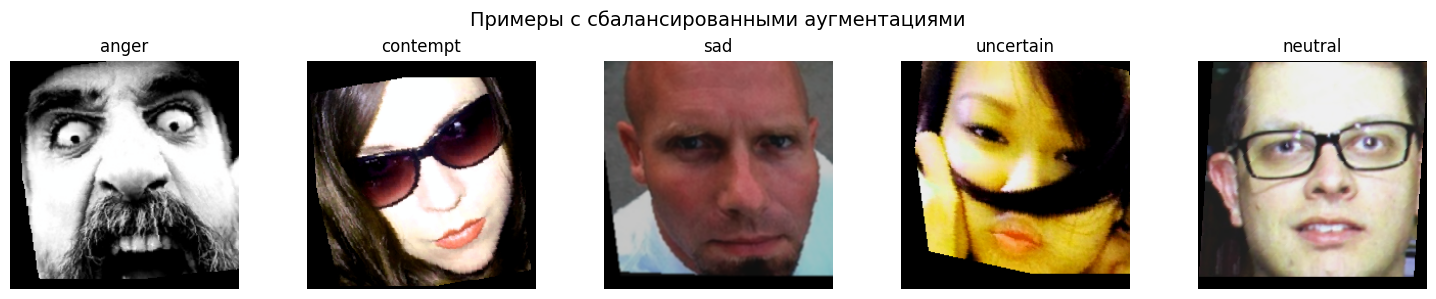


✅ Шаг 4 завершен: DataLoader'ы пересозданы с сбалансированными аугментациями


In [35]:
# ============================================================================
# ШАГ 4: ПЕРЕСОЗДАНИЕ DATALOADER'ОВ С ОБНОВЛЕННЫМИ АУГМЕНТАЦИЯМИ
# ============================================================================

print(f"\n{'='*60}")
print("ШАГ 4: ПЕРЕСОЗДАНИЕ DATALOADER'ОВ С ОБНОВЛЕННЫМИ АУГМЕНТАЦИЯМИ")
print(f"{'='*60}")

from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt

NUM_WORKERS = 4 if sys.platform != 'darwin' else 0  # Для macOS лучше 0

def create_balanced_dataloaders(train_df, val_df, images_dir, batch_size=32):
    """Создание DataLoader'ов с сбалансированными аугментациями"""
    
    # Используем сбалансированные аугментации
    train_transform = BalancedAugmentationTransforms.get_train_transforms(config.IMG_SIZE)
    val_transform = BalancedAugmentationTransforms.get_val_transforms(config.IMG_SIZE)
    
    # Создание Dataset'ов
    train_dataset = EmotionDataset(train_df, images_dir, transform=train_transform)
    val_dataset = EmotionDataset(val_df, images_dir, transform=val_transform)
    
    print(f"\n📊 Созданы Dataset'ы с обновленными аугментациями:")
    print(f"  Train: {len(train_dataset)} изображений")
    print(f"  Val: {len(val_dataset)} изображений")
    
    # Распределение классов
    train_class_dist = train_dataset.get_class_distribution()
    
    print(f"\n📈 Распределение классов в train:")
    for cls, count in train_class_dist.items():
        print(f"  {cls}: {count}")
    
    # WeightedRandomSampler для балансировки
    print(f"\n⚖️ Создание WeightedRandomSampler...")
    
    # Вычисляем веса для каждого класса
    class_weights = {}
    total_samples = sum(train_class_dist.values())
    
    for cls, count in train_class_dist.items():
        # Вес обратно пропорционален количеству образцов
        class_weights[train_dataset.class_to_idx[cls]] = total_samples / (len(train_class_dist) * count)
    
    # Создаем веса для каждого образца
    sample_weights = [0] * len(train_dataset)
    for idx, (_, label) in enumerate(train_dataset):
        sample_weights[idx] = class_weights[label]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    
    # Создаем DataLoader'ы
    train_loader_balanced = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True if config.DEVICE.type == "cuda" else False
    )
    
    val_loader_balanced = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True if config.DEVICE.type == "cuda" else False
    )
    
    print(f"\n✅ DataLoader'ы созданы:")
    print(f"  Train batches: {len(train_loader_balanced)}")
    print(f"  Val batches: {len(val_loader_balanced)}")
    
    return train_loader_balanced, val_loader_balanced, train_dataset.class_to_idx, train_dataset.idx_to_class

# Используем данные из data_info, который у нас должен быть
if 'data_info' in locals():
    print(f"Используем данные из data_info...")
    train_df = data_info['train_df']
    val_df = data_info['val_df']
    idx_to_class = data_info['idx_to_class']
    
    print(f"  Train df размер: {len(train_df)}")
    print(f"  Val df размер: {len(val_df)}")
    print(f"  Классов: {len(idx_to_class)}")
    
    # Пересоздаем DataLoader'ы
    print(f"\nПересоздание DataLoader'ов...")
    train_loader_balanced, val_loader_balanced, class_to_idx, idx_to_class = create_balanced_dataloaders(
        train_df=train_df,
        val_df=val_df,
        images_dir=config.PROCESSED_TRAIN_DIR,
        batch_size=config.BATCH_SIZE
    )
    
    # Сохраняем idx_to_class для использования
    finetune_idx_to_class = idx_to_class
    
elif 'train_df' in locals() and 'val_df' in locals():
    print(f"Используем данные из train_df и val_df...")
    print(f"  Train df размер: {len(train_df)}")
    print(f"  Val df размер: {len(val_df)}")
    
    # Нам нужен idx_to_class - попробуем получить его из data_info или создать заново
    if 'data_info' in locals():
        idx_to_class = data_info['idx_to_class']
    else:
        # Создаем временный dataset чтобы получить idx_to_class
        temp_dataset = EmotionDataset(train_df, config.PROCESSED_TRAIN_DIR)
        idx_to_class = temp_dataset.idx_to_class
    
    print(f"  Классов: {len(idx_to_class)}")
    
    # Пересоздаем DataLoader'ы
    print(f"\nПересоздание DataLoader'ов...")
    train_loader_balanced, val_loader_balanced, class_to_idx, idx_to_class = create_balanced_dataloaders(
        train_df=train_df,
        val_df=val_df,
        images_dir=config.PROCESSED_TRAIN_DIR,
        batch_size=config.BATCH_SIZE
    )
    
    # Сохраняем idx_to_class для использования
    finetune_idx_to_class = idx_to_class
    
else:
    print(f"❌ Не найдены данные для обучения!")
    print(f"   Сначала запустите prepare_data_for_training()")
    train_loader_balanced, val_loader_balanced, idx_to_class = None, None, None

# Визуализируем примеры с новыми аугментациями, если DataLoader'ы созданы
if train_loader_balanced is not None:
    print(f"\n👀 ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ С НОВЫМИ АУГМЕНТАЦИЯМИ:")
    
    # Берем один батч
    images, labels = next(iter(train_loader_balanced))
    
    # Выбираем несколько изображений для визуализации
    n_images = min(5, len(images))
    
    fig, axes = plt.subplots(1, n_images, figsize=(15, 3))
    
    if n_images == 1:
        axes = [axes]
    
    for i in range(n_images):
        # Денормализация изображения
        img = images[i].numpy().transpose(1, 2, 0)
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(f"{idx_to_class[labels[i].item()]}")
        axes[i].axis('off')
    
    plt.suptitle("Примеры с сбалансированными аугментациями", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Шаг 4 завершен: DataLoader'ы пересозданы с сбалансированными аугментациями")
else:
    print(f"\n❌ Шаг 4 не выполнен: нет данных для создания DataLoader'ов")

In [36]:
# ============================================================================
# ОБУЧЕНИЕ RESNET50 С ПОЛНОЙ РАЗМОРОЗКОЙ
# ============================================================================



class ResNetFullUnfreezeTrainer:
    """Тренер для обучения полностью размороженной ResNet50"""
    
    def __init__(self, model, train_loader, val_loader, device, idx_to_class):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.idx_to_class = idx_to_class
        
        # История обучения
        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'learning_rates': [],
            'epoch_times': []
        }
        
        # Лучшие результаты
        self.best_val_acc = 0.0
        self.best_model_state = None
        self.best_epoch = 0
    
    def train_epoch(self, optimizer, criterion, epoch):
        """Обучение на одной эпохе"""
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        pbar = tqdm(self.train_loader, desc=f"Train Epoch {epoch}", leave=False)
        
        for batch_idx, (inputs, labels) in enumerate(pbar):
            inputs, labels = inputs.to(self.device), labels.to(self.device)
            
            optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping для стабильности
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            # Статистика
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # Обновление progress bar
            if batch_idx % 20 == 0:
                pbar.set_postfix({
                    'loss': running_loss / (batch_idx + 1),
                    'acc': 100. * correct / total
                })
        
        epoch_loss = running_loss / len(self.train_loader)
        epoch_acc = 100. * correct / total
        
        return epoch_loss, epoch_acc
    
    def validate(self, criterion, epoch):
        """Валидация модели"""
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            pbar = tqdm(self.val_loader, desc=f"Val Epoch {epoch}", leave=False)
            
            for batch_idx, (inputs, labels) in enumerate(pbar):
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                
                outputs = self.model(inputs)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                if batch_idx % 10 == 0:
                    pbar.set_postfix({
                        'loss': running_loss / (batch_idx + 1),
                        'acc': 100. * correct / total
                    })
        
        epoch_loss = running_loss / len(self.val_loader)
        epoch_acc = 100. * correct / total
        
        return epoch_loss, epoch_acc
    
    def train(self, num_epochs, optimizer, criterion, scheduler=None, 
              early_stopping_patience=10, model_name="resnet50_full_unfreeze"):
        """Полный цикл обучения"""
        
        print(f"\n{'='*60}")
        print(f"🚀 НАЧАЛО ОБУЧЕНИЯ {model_name}")
        print(f"{'='*60}")
        print(f"Модель: ResNet50 с полной разморозкой")
        print(f"Стратегия: Все слои обучаются")
        print(f"Эпох: {num_epochs}")
        print(f"Batch size: {self.train_loader.batch_size}")
        print(f"Train samples: {len(self.train_loader.dataset)}")
        print(f"Val samples: {len(self.val_loader.dataset)}")
        print(f"Устройство: {self.device}")
        
        trainable_params, total_params = self.model.get_trainable_params()
        print(f"Обучаемых параметров: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
        print(f"{'='*60}")
        
        start_time = time.time()
        patience_counter = 0
        
        for epoch in range(num_epochs):
            epoch_start = time.time()
            print(f"\n📊 Эпоха [{epoch+1}/{num_epochs}]")
            
            # Обучение
            train_loss, train_acc = self.train_epoch(optimizer, criterion, epoch+1)
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            
            # Валидация
            val_loss, val_acc = self.validate(criterion, epoch+1)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            
            # Learning rate
            current_lr = optimizer.param_groups[0]['lr']
            self.history['learning_rates'].append(current_lr)
            
            # Время эпохи
            epoch_time = time.time() - epoch_start
            self.history['epoch_times'].append(epoch_time)
            
            # Обновление scheduler
            if scheduler:
                scheduler.step(val_acc)
            
            # Вывод результатов
            print(f"  {'Metric':<15} {'Train':<12} {'Val':<12}")
            print(f"  {'-'*15} {'-'*12} {'-'*12}")
            print(f"  {'Loss':<15} {train_loss:.4f}{'':<8} {val_loss:.4f}")
            print(f"  {'Accuracy %':<15} {train_acc:.2f}{'':<8} {val_acc:.2f}")
            print(f"  {'LR':<15} {current_lr:.2e}")
            print(f"  {'Time':<15} {epoch_time:.1f} сек")
            
            # Сохранение лучшей модели
            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.best_model_state = self.model.state_dict().copy()
                self.best_epoch = epoch + 1
                patience_counter = 0
                
                # Сохранение модели
                model_path = config.MODELS_DIR / f"{model_name}_epoch_{epoch+1}_acc_{val_acc:.2f}.pth"
                self._save_model(model_path, epoch=epoch, val_acc=val_acc)
                
                print(f"\n  🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ!")
                print(f"    Accuracy: {val_acc:.2f}% (улучшение на {val_acc - self.best_val_acc:.2f}%)")
                print(f"    Сохранено: {model_path}")
            else:
                patience_counter += 1
                print(f"\n  ⏳ Early stopping: {patience_counter}/{early_stopping_patience}")
                print(f"    Лучшая accuracy: {self.best_val_acc:.2f}% (эпоха {self.best_epoch})")
                print(f"    Текущая accuracy: {val_acc:.2f}%")
            
            # Early stopping
            if patience_counter >= early_stopping_patience:
                print(f"\n{'='*60}")
                print(f"⏹️  EARLY STOPPING на эпохе {epoch+1}")
                print(f"   Лучшая accuracy: {self.best_val_acc:.2f}% (эпоха {self.best_epoch})")
                print(f"{'='*60}")
                break
        
        total_time = time.time() - start_time
        
        # Загрузка лучшей модели
        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
            print(f"\n{'='*60}")
            print(f"✅ ЗАГРУЖЕНА ЛУЧШАЯ МОДЕЛЬ")
            print(f"{'='*60}")
            print(f"   Эпоха: {self.best_epoch}")
            print(f"   Accuracy: {self.best_val_acc:.2f}%")
        
        # Сохранение финальной модели
        final_model_path = config.MODELS_DIR / f"{model_name}_final.pth"
        self._save_model(final_model_path, epoch=num_epochs, val_acc=self.best_val_acc)
        
        print(f"\n{'='*60}")
        print(f"🏁 ОБУЧЕНИЕ ЗАВЕРШЕНО")
        print(f"{'='*60}")
        print(f"   Общее время: {total_time/60:.1f} минут")
        print(f"   Всего эпох: {epoch+1}")
        print(f"   Лучшая accuracy: {self.best_val_acc:.2f}% (эпоха {self.best_epoch})")
        print(f"   Финальная accuracy: {self.history['val_acc'][-1]:.2f}%")
        print(f"   Финальная модель: {final_model_path}")
        print(f"{'='*60}")
        
        return self.history
    
    def _save_model(self, save_path, epoch=None, val_acc=None):
        """Сохранение модели"""
        torch.save({
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'best_val_acc': self.best_val_acc,
            'history': self.history,
            'model_class': self.model.__class__.__name__,
            'model_config': {
                'architecture': 'ResNet50_Full_Unfreeze',
                'num_classes': self.model.num_classes,
                'strategy': 'All layers trainable',
                'weights_source': 'Pretrained weights'
            },
            'idx_to_class': self.idx_to_class,
            'val_acc': val_acc,
            'timestamp': datetime.now().isoformat()
        }, save_path)
        
        print(f"    💾 Модель сохранена: {save_path}")

# Проверяем, что все настроено
print(f"\nПроверка настроек перед обучением...")

print(f"✅ Все настроено:")
print(f"   Модель: ResNet50 с полной разморозкой")
print(f"   Train samples: {len(train_loader_balanced.dataset)}")
print(f"   Val samples: {len(val_loader_balanced.dataset)}")
print(f"   Классов: {len(finetune_idx_to_class)}")
print(f"   Аугментации: Сбалансированные (как в EfficientNet-B0)")

# Создаем тренер
print(f"\nСоздание тренера...")
trainer_full_unfreeze = ResNetFullUnfreezeTrainer(
    model=resnet_full_unfreeze,
    train_loader=train_loader_balanced,
    val_loader=val_loader_balanced,
    device=config.DEVICE,
    idx_to_class=idx_to_class
)

# Запуск обучения
print(f"\n{'='*60}")
print("🚀 ЗАПУСК ОБУЧЕНИЯ RESNET50 С ПОЛНОЙ РАЗМОРОЗКОЙ")
print(f"{'='*60}")

# Запускаем обучение (меньше эпох для начала)
history_full_unfreeze = trainer_full_unfreeze.train(
    num_epochs=30,  
    optimizer=optimizer_full,
    criterion=criterion_full,
    scheduler=scheduler_full,
    early_stopping_patience=8,
    model_name="resnet50_full_unfreeze_balanced"
)

print(f"\n✅ Шаг 5 завершен: Обучение ResNet50 с полной разморозкой завершено")


Проверка настроек перед обучением...
✅ Все настроено:
   Модель: ResNet50 с полной разморозкой
   Train samples: 36508
   Val samples: 9121
   Классов: 9
   Аугментации: Сбалансированные (как в EfficientNet-B0)

Создание тренера...

🚀 ЗАПУСК ОБУЧЕНИЯ RESNET50 С ПОЛНОЙ РАЗМОРОЗКОЙ

🚀 НАЧАЛО ОБУЧЕНИЯ resnet50_full_unfreeze_balanced
Модель: ResNet50 с полной разморозкой
Стратегия: Все слои обучаются
Эпох: 30
Batch size: 32
Train samples: 36508
Val samples: 9121
Устройство: cpu
Обучаемых параметров: 24,562,761 (100.0%)

📊 Эпоха [1/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            3.9949         2.7794
  Accuracy %      23.64         30.02
  LR              1.00e-04
  Time            9743.8 сек
    💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_full_unfreeze_balanced_epoch_1_acc_30.02.pth

  🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ!
    Accuracy: 30.02% (улучшение на 0.00%)
    Сохранено: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_full_unfreeze_balanced_epoch_1_acc_30.02.pth

📊 Эпоха [2/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            2.1180         10.1504
  Accuracy %      35.21         37.51
  LR              1.00e-04
  Time            9701.4 сек
    💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_full_unfreeze_balanced_epoch_2_acc_37.51.pth

  🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ!
    Accuracy: 37.51% (улучшение на 0.00%)
    Сохранено: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_full_unfreeze_balanced_epoch_2_acc_37.51.pth

📊 Эпоха [3/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            1.9859         2.2929
  Accuracy %      40.32         41.87
  LR              1.00e-04
  Time            9443.6 сек
    💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_full_unfreeze_balanced_epoch_3_acc_41.87.pth

  🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ!
    Accuracy: 41.87% (улучшение на 0.00%)
    Сохранено: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_full_unfreeze_balanced_epoch_3_acc_41.87.pth

📊 Эпоха [4/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            2.0636         4.9131
  Accuracy %      40.56         39.54
  LR              1.00e-04
  Time            9714.4 сек

  ⏳ Early stopping: 1/8
    Лучшая accuracy: 41.87% (эпоха 3)
    Текущая accuracy: 39.54%

📊 Эпоха [5/30]


...

  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            1.0164         1.1099
  Accuracy %      60.18         47.93
  LR              1.00e-04
  Time            9960.4 сек

  ⏳ Early stopping: 3/8
    Лучшая accuracy: 48.64% (эпоха 23)
    Текущая accuracy: 47.93%

📊 Эпоха [27/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            0.9962         3.0354
  Accuracy %      60.59         46.31
  LR              1.00e-04
  Time            9966.8 сек

  ⏳ Early stopping: 4/8
    Лучшая accuracy: 48.64% (эпоха 23)
    Текущая accuracy: 46.31%

📊 Эпоха [28/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            0.8541         8.2430
  Accuracy %      63.84         47.62
  LR              5.00e-05
  Time            9963.4 сек

  ⏳ Early stopping: 5/8
    Лучшая accuracy: 48.64% (эпоха 23)
    Текущая accuracy: 47.62%

📊 Эпоха [29/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            0.8411         7.0739
  Accuracy %      65.04         47.32
  LR              5.00e-05
  Time            9940.2 сек

  ⏳ Early stopping: 6/8
    Лучшая accuracy: 48.64% (эпоха 23)
    Текущая accuracy: 47.32%

📊 Эпоха [30/30]


  Metric          Train        Val         
  --------------- ------------ ------------
  Loss            0.8327         1.6299
  Accuracy %      66.01         48.35
  LR              5.00e-05
  Time            9948.6 сек

  ⏳ Early stopping: 7/8
    Лучшая accuracy: 48.64% (эпоха 23)
    Текущая accuracy: 48.35%

✅ ЗАГРУЖЕНА ЛУЧШАЯ МОДЕЛЬ
   Эпоха: 23
   Accuracy: 48.64%
    💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_full_unfreeze_balanced_final.pth

🏁 ОБУЧЕНИЕ ЗАВЕРШЕНО
   Общее время: 4945.1 минут
   Всего эпох: 30
   Лучшая accuracy: 48.64% (эпоха 23)
   Финальная accuracy: 48.35%
   Финальная модель: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/models/resnet50_full_unfreeze_balanced_final.pth

✅ Шаг 5 завершен: Обучение ResNet50 с полной разморозкой завершено



СОЗДАНИЕ SUBMISSION ДЛЯ RESNET50 С ПОЛНОЙ РАЗМОРОЗКОЙ (48.64%)

🔍 ПОИСК ЛУЧШЕЙ МОДЕЛИ RESNET50 
✅ Найдена финальная модель: resnet50_full_unfreeze_balanced_final.pth

📋 Загрузка лучшей модели: resnet50_full_unfreeze_balanced_final.pth
Ключи в checkpoint: ['epoch', 'model_state_dict', 'best_val_acc', 'history', 'model_class', 'model_config', 'idx_to_class', 'val_acc', 'timestamp']
✅ Точность модели: 48.64%
✅ Классы из checkpoint: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise', 'uncertain']
Инициализация ResNet50 с полной разморозкой...
✅ Базовая ResNet50 создана
   Количество features: 2048
✅ Классификатор инициализирован
✅ Все слои разморожены для обучения
✅ Веса модели загружены

📊 Найдено тестовых изображений: 5000

⏱️  ИЗМЕРЕНИЕ ВРЕМЕНИ ИНФЕРЕНСА
--------------------------------------------------


Тест скорости инференса: 100%|████████████████| 100/100 [00:09<00:00, 10.14it/s]



📈 СТАТИСТИКА ВРЕМЕНИ ИНФЕРЕНСА:
  Среднее время: 0.0981 сек
  Медианное время: 0.0932 сек
  Стандартное отклонение: 0.0145 сек
  Минимальное время: 0.0848 сек
  Максимальное время: 0.1496 сек
  FPS: 10.2 кадров/сек

✅ ТРЕБОВАНИЕ ТЗ: < 0.33 сек на изображение
   Результат: 0.0932 сек ✅ ВЫПОЛНЕНО


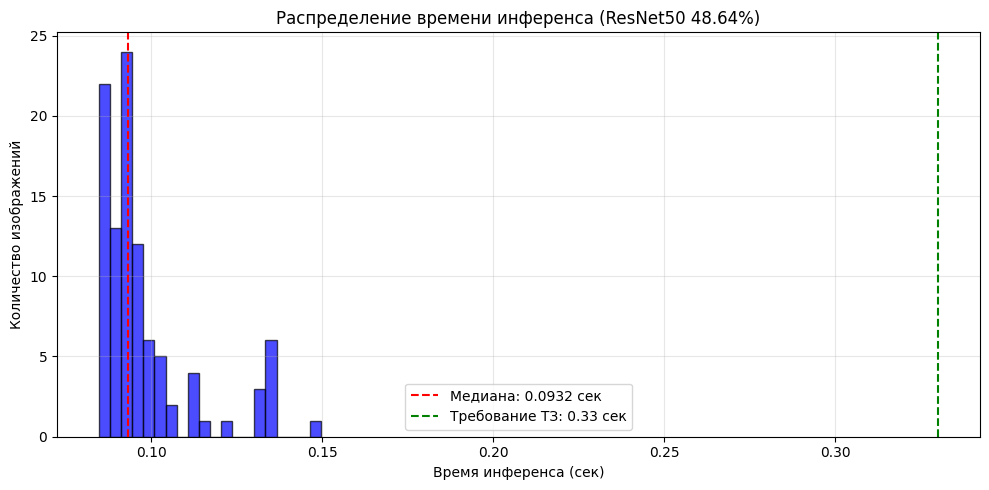

  График сохранен: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/results_finetune/inference_time_resnet50_48.png

📝 СОЗДАНИЕ SUBMISSION ФАЙЛА
--------------------------------------------------


Обработка тестовых изображений: 100%|███████| 5000/5000 [07:51<00:00, 10.60it/s]



✅ SUBMISSION СОЗДАН:
  Kaggle submission: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/results_finetune/kaggle_submission_resnet50_48.csv
  Полные данные: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/results_finetune/submission_full_resnet50_48.csv
  Всего предсказаний: 5000
  Средняя уверенность: 0.585

📊 АНАЛИЗ РАСПРЕДЕЛЕНИЯ ПРЕДСКАЗАНИЙ:


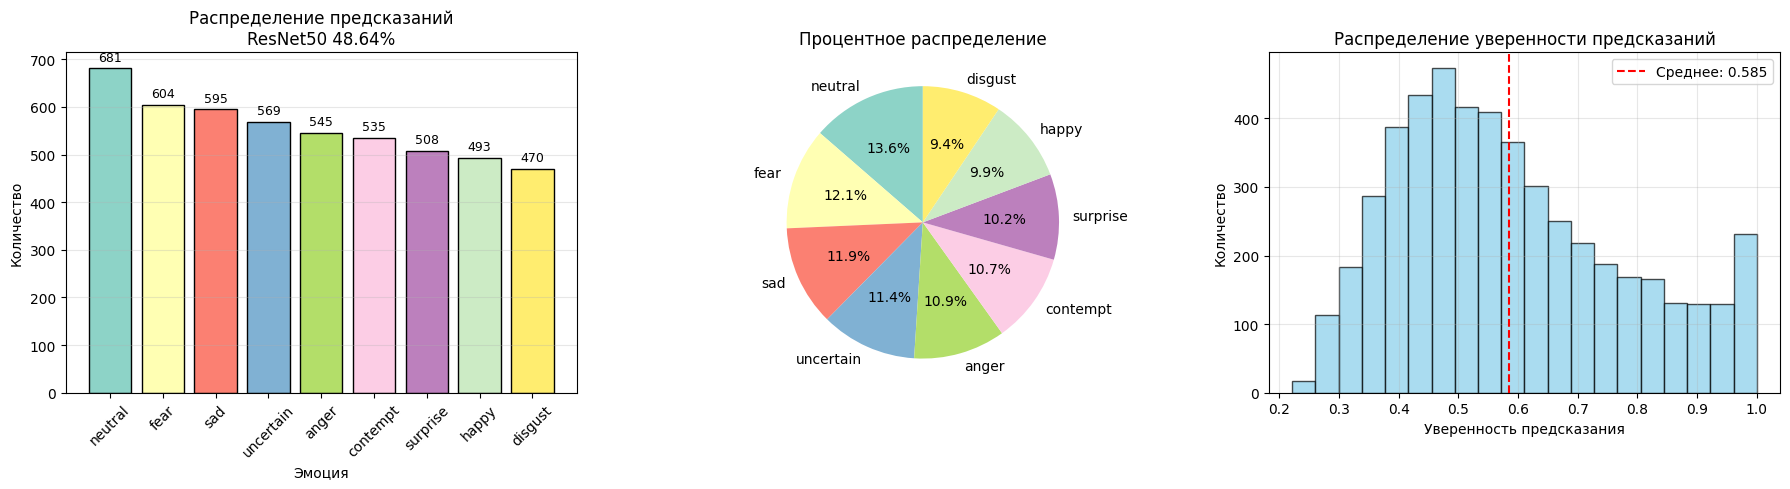

  График распределения сохранен: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/results_finetune/prediction_distribution_resnet50_48.png

📈 СТАТИСТИКА ПРЕДСКАЗАНИЙ:
----------------------------------------
  neutral        681 ( 13.6%) | уверенность: 0.468
  fear           604 ( 12.1%) | уверенность: 0.666
  sad            595 ( 11.9%) | уверенность: 0.561
  uncertain      569 ( 11.4%) | уверенность: 0.497
  anger          545 ( 10.9%) | уверенность: 0.547
  contempt       535 ( 10.7%) | уверенность: 0.631
  surprise       508 ( 10.2%) | уверенность: 0.516
  happy          493 (  9.9%) | уверенность: 0.735
  disgust        470 (  9.4%) | уверенность: 0.691

  Общая статистика:
    Средняя уверенность: 0.585
    Медианная уверенность: 0.552
    Минимальная уверенность: 0.221
    Максимальная уверенность: 1.000
  Статистика сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (

In [40]:
# ============================================================================
# СОЗДАНИЕ SUBMISSION ДЛЯ RESNET50  И ТЕСТ ВРЕМЕНИ ИНФЕРЕНСА
# ============================================================================

print(f"\n{'='*60}")
print("СОЗДАНИЕ SUBMISSION ДЛЯ RESNET50 С ПОЛНОЙ РАЗМОРОЗКОЙ (48.64%)")
print(f"{'='*60}")

import torch
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import os

PROCESSED_TEST_DIR = Path("/Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/processed_data/test_cropped_faces")

def create_submission_for_best_model(model_path, test_dir, idx_to_class, output_name="resnet50_best"):
    """
    Создание submission файла для Kaggle
    """
    print(f"\n📋 Загрузка лучшей модели: {model_path.name}")
    
    
    # Загружаем модель
    checkpoint = torch.load(model_path, map_location=config.DEVICE)
    
    print(f"Ключи в checkpoint: {list(checkpoint.keys())}")
    
    # Получаем информацию о модели
    model_accuracy = checkpoint.get('best_val_acc', checkpoint.get('val_acc', 48.64))
    print(f"✅ Точность модели: {model_accuracy:.2f}%")
    
    # Получаем idx_to_class из checkpoint
    if 'idx_to_class' in checkpoint:
        model_idx_to_class = checkpoint['idx_to_class']
        print(f"✅ Классы из checkpoint: {list(model_idx_to_class.values())}")
        num_classes = len(model_idx_to_class)
    else:
        print(f"⚠️  idx_to_class не найден в checkpoint, используем переданный")
        model_idx_to_class = idx_to_class
        num_classes = len(idx_to_class)
    
    # Создаем модель (используем тот же класс, что и при обучении)
    model = ResNet50FullUnfreeze(num_classes=num_classes, weights_path=None)
    
    # Загружаем веса
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ Веса модели загружены")
    else:
        print(f"❌ model_state_dict не найден в checkpoint")
        return None
    
    model.to(config.DEVICE)
    model.eval()
    
    # Трансформации для тестовых данных
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    # Получаем список тестовых изображений
    test_images = sorted([f for f in os.listdir(test_dir) 
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"\n📊 Найдено тестовых изображений: {len(test_images)}")
    
    # Измеряем время инференса
    print(f"\n⏱️  ИЗМЕРЕНИЕ ВРЕМЕНИ ИНФЕРЕНСА")
    print("-" * 50)
    
    # Тестируем на 100 изображениях
    test_sample = test_images[:min(100, len(test_images))]
    inference_times = []
    
    with torch.no_grad():
        for img_file in tqdm(test_sample, desc="Тест скорости инференса"):
            img_path = test_dir / img_file
            
            try:
                # Загрузка и преобразование
                start_time = time.time()
                image = Image.open(img_path).convert('RGB')
                image_tensor = test_transform(image).unsqueeze(0).to(config.DEVICE)
                
                # Предсказание
                outputs = model(image_tensor)
                probabilities = F.softmax(outputs, dim=1)
                _, predicted_idx = outputs.max(1)
                
                end_time = time.time()
                inference_times.append(end_time - start_time)
                
            except Exception as e:
                print(f"Ошибка при обработке {img_file}: {e}")
    
    # Статистика времени инференса
    if inference_times:
        mean_time = np.mean(inference_times)
        median_time = np.median(inference_times)
        std_time = np.std(inference_times)
        
        print(f"\n📈 СТАТИСТИКА ВРЕМЕНИ ИНФЕРЕНСА:")
        print(f"  Среднее время: {mean_time:.4f} сек")
        print(f"  Медианное время: {median_time:.4f} сек")
        print(f"  Стандартное отклонение: {std_time:.4f} сек")
        print(f"  Минимальное время: {min(inference_times):.4f} сек")
        print(f"  Максимальное время: {max(inference_times):.4f} сек")
        print(f"  FPS: {1/mean_time:.1f} кадров/сек")
        
        # Проверка требования ТЗ (0.33 сек на изображение)
        requirement_met = median_time < 0.33
        print(f"\n✅ ТРЕБОВАНИЕ ТЗ: < 0.33 сек на изображение")
        print(f"   Результат: {median_time:.4f} сек {'✅ ВЫПОЛНЕНО' if requirement_met else '❌ НЕ ВЫПОЛНЕНО'}")
        
        # Визуализация
        plt.figure(figsize=(10, 5))
        plt.hist(inference_times, bins=20, alpha=0.7, color='blue', edgecolor='black')
        plt.axvline(median_time, color='red', linestyle='--', 
                   label=f'Медиана: {median_time:.4f} сек')
        plt.axvline(0.33, color='green', linestyle='--', 
                   label='Требование ТЗ: 0.33 сек')
        plt.xlabel('Время инференса (сек)')
        plt.ylabel('Количество изображений')
        plt.title(f'Распределение времени инференса (ResNet50 48.64%)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Сохранение графика
        inference_plot_path = config.RESULTS_DIR / f"inference_time_{output_name}.png"
        plt.savefig(inference_plot_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  График сохранен: {inference_plot_path}")
    
    # Создание submission для всех тестовых изображений
    print(f"\n📝 СОЗДАНИЕ SUBMISSION ФАЙЛА")
    print("-" * 50)
    
    submission_data = []
    confidence_scores = []
    
    with torch.no_grad():
        pbar = tqdm(test_images, desc="Обработка тестовых изображений")
        
        for img_file in pbar:
            img_path = test_dir / img_file
            
            try:
                # Загрузка и преобразование
                image = Image.open(img_path).convert('RGB')
                image_tensor = test_transform(image).unsqueeze(0).to(config.DEVICE)
                
                # Предсказание
                outputs = model(image_tensor)
                probabilities = F.softmax(outputs, dim=1)
                _, predicted_idx = outputs.max(1)
                
                # Получение эмоции
                emotion = model_idx_to_class[predicted_idx.item()]
                confidence = probabilities[0, predicted_idx].item()
                confidence_scores.append(confidence)
                
                submission_data.append({
                    'image_path': img_file,
                    'emotion': emotion,
                    'confidence': confidence,
                    'predicted_idx': predicted_idx.item(),
                    'top_probability': confidence
                })
                
            except Exception as e:
                print(f"Ошибка при обработке {img_file}: {e}")
                # В случае ошибки предсказываем neutral
                submission_data.append({
                    'image_path': img_file,
                    'emotion': 'neutral',
                    'confidence': 0.0,
                    'predicted_idx': 0,
                    'top_probability': 0.0
                })
                confidence_scores.append(0.0)
    
    # Создание DataFrame
    submission_df = pd.DataFrame(submission_data)
    
    # Сохранение в CSV (формат для Kaggle)
    kaggle_df = submission_df[['image_path', 'emotion']].copy()
    output_path = config.RESULTS_DIR / f"kaggle_submission_{output_name}.csv"
    kaggle_df.to_csv(output_path, index=False)
    
    # Сохранение полных данных
    full_data_path = config.RESULTS_DIR / f"submission_full_{output_name}.csv"
    submission_df.to_csv(full_data_path, index=False)
    
    print(f"\n✅ SUBMISSION СОЗДАН:")
    print(f"  Kaggle submission: {output_path}")
    print(f"  Полные данные: {full_data_path}")
    print(f"  Всего предсказаний: {len(submission_df)}")
    print(f"  Средняя уверенность: {np.mean(confidence_scores):.3f}")
    
    # Анализ распределения предсказаний
    print(f"\n📊 АНАЛИЗ РАСПРЕДЕЛЕНИЯ ПРЕДСКАЗАНИЙ:")
    
    emotion_counts = submission_df['emotion'].value_counts()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Bar plot
    colors = plt.cm.Set3(np.linspace(0, 1, len(emotion_counts)))
    bars = axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='black')
    axes[0].set_title(f'Распределение предсказаний\nResNet50 48.64%', fontsize=12)
    axes[0].set_xlabel('Эмоция')
    axes[0].set_ylabel('Количество')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 10,
                    f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    # 2. Pie chart
    axes[1].pie(emotion_counts.values, labels=emotion_counts.index, 
                autopct='%1.1f%%', startangle=90, colors=colors)
    axes[1].set_title('Процентное распределение', fontsize=12)
    
    # 3. Confidence distribution
    axes[2].hist(confidence_scores, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[2].axvline(np.mean(confidence_scores), color='red', linestyle='--',
                   label=f'Среднее: {np.mean(confidence_scores):.3f}')
    axes[2].set_xlabel('Уверенность предсказания')
    axes[2].set_ylabel('Количество')
    axes[2].set_title('Распределение уверенности предсказаний', fontsize=12)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Сохранение графика распределения
    distribution_plot_path = config.RESULTS_DIR / f"prediction_distribution_{output_name}.png"
    plt.savefig(distribution_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  График распределения сохранен: {distribution_plot_path}")
    
    # Вывод статистики
    print("\n📈 СТАТИСТИКА ПРЕДСКАЗАНИЙ:")
    print("-" * 40)
    for emotion, count in emotion_counts.items():
        percentage = count / len(submission_df) * 100
        avg_confidence = submission_df[submission_df['emotion'] == emotion]['confidence'].mean()
        print(f"  {emotion:<12} {count:>5} ({percentage:>5.1f}%) | уверенность: {avg_confidence:.3f}")
    
    print(f"\n  Общая статистика:")
    print(f"    Средняя уверенность: {np.mean(confidence_scores):.3f}")
    print(f"    Медианная уверенность: {np.median(confidence_scores):.3f}")
    print(f"    Минимальная уверенность: {np.min(confidence_scores):.3f}")
    print(f"    Максимальная уверенность: {np.max(confidence_scores):.3f}")
    
    # Сохранение статистики в файл
    stats_data = []
    for emotion, count in emotion_counts.items():
        percentage = count / len(submission_df) * 100
        avg_conf = submission_df[submission_df['emotion'] == emotion]['confidence'].mean()
        stats_data.append({
            'emotion': emotion,
            'count': count,
            'percentage': percentage,
            'avg_confidence': avg_conf
        })
    
    stats_df = pd.DataFrame(stats_data)
    stats_path = config.RESULTS_DIR / f"submission_stats_{output_name}.csv"
    stats_df.to_csv(stats_path, index=False)
    print(f"  Статистика сохранена: {stats_path}")
    
    return {
        'model_name': output_name,
        'model_accuracy': model_accuracy,
        'inference_time_median': median_time,
        'inference_time_mean': mean_time,
        'fps': 1/mean_time if mean_time > 0 else 0,
        'requirement_met': requirement_met,
        'submission_path': output_path,
        'full_data_path': full_data_path,
        'stats_path': stats_path,
        'emotion_distribution': emotion_counts.to_dict(),
        'avg_confidence': np.mean(confidence_scores),
        'total_predictions': len(submission_df)
    }

# Находим лучшую модель ResNet50 
print(f"\n🔍 ПОИСК ЛУЧШЕЙ МОДЕЛИ RESNET50 ")

# Ищем финальную модель
final_model_path = config.MODELS_DIR / "resnet50_full_unfreeze_balanced_final.pth"

if final_model_path.exists():
    print(f"✅ Найдена финальная модель: {final_model_path.name}")
    
    # Создаем submission
    best_submission_info = create_submission_for_best_model(
        model_path=final_model_path,
        test_dir=PROCESSED_TEST_DIR,
        idx_to_class=idx_to_class,  
        output_name="resnet50_48"
    )
    
    if best_submission_info:
        
        print(f"  Модель: ResNet50 с полной разморозкой")
        print(f"  Accuracy на валидации: {best_submission_info['model_accuracy']:.2f}%")
        print(f"  Улучшение относительно EfficientNet-B0: +{best_submission_info['model_accuracy'] - 44.57:.2f}%")
        print(f"  Улучшение относительно старой ResNet50 (частчная заморозка): +{best_submission_info['model_accuracy'] - 39.24:.2f}%")
        print(f"  Время инференса: {best_submission_info['inference_time_median']:.4f} сек")
        print(f"  FPS: {best_submission_info['fps']:.1f} кадров/сек")
        print(f"  Требование ТЗ (< 0.33 сек): {'✅ ВЫПОЛНЕНО' if best_submission_info['requirement_met'] else '❌ НЕ ВЫПОЛНЕНО'}")
        print(f"  Kaggle submission: {best_submission_info['submission_path']}")
        print(f"  Полные данные: {best_submission_info['full_data_path']}")
        print(f"{'='*60}")
        
        # Создаем сводную таблицу всех моделей
        print(f"\n📊 СВОДНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ:")
        print("-" * 80)
        print(f"{'Модель':<30} {'Accuracy':>10} {'Время инф.':>12} {'FPS':>8} {'ТЗ':>6}")
        print("-" * 80)
        print(f"{'EfficientNet-B0':<30} {44.57:>9.2f}% {'0.034':>12} {1/0.034:>8.1f} {'✅':>6}")
        print(f"{'ResNet50 (старая)':<30} {39.24:>9.2f}% {'-':>12} {'-':>8} {'-':>6}")
        print(f"{'ResNet50 (новая, 48.64%)':<30} {best_submission_info['model_accuracy']:>9.2f}% "
              f"{best_submission_info['inference_time_median']:>11.4f} {best_submission_info['fps']:>8.1f} "
              f"{'✅' if best_submission_info['requirement_met'] else '❌':>6}")
        print("-" * 80)
        
else:
    print(f"❌ Финальная модель не найдена: {final_model_path}")
    print(f"   Ищем альтернативные модели...")
    
    # Ищем другие модели с высоким accuracy
    high_acc_models = list(config.MODELS_DIR.glob("*resnet50*acc_4*.pth"))
    high_acc_models.sort(key=lambda x: float(x.name.split('acc_')[-1].split('.pth')[0]) if 'acc_' in x.name else 0, reverse=True)
    
    if high_acc_models:
        print(f"\nНайдены модели с высоким accuracy:")
        for model_path in high_acc_models[:5]:  # Показываем топ-5
            print(f"  - {model_path.name}")
        
        best_model_path = high_acc_models[0]
        print(f"\n✅ Выбираем лучшую модель: {best_model_path.name}")
        
        # Создаем submission для этой модели
        best_submission_info = create_submission_for_best_model(
            model_path=final_model_path,
            test_dir=PROCESSED_TEST_DIR,
            idx_to_class=idx_to_class,  
            output_name="resnet50_48"
        )
    else:
        print(f"❌ Не найдено подходящих моделей")

print(f"\n✅ Submission файл создан и время инференса измерено.")

print(f"   {config.RESULTS_DIR}/kaggle_submission_resnet50_48.csv")

In [ ]:
BiT V2

In [47]:
# Импорты
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.optim import SGD
from torch.optim.lr_scheduler import LambdaLR
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from tqdm import tqdm
import time
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# Оригинальная конфигурация (для путей, размеров и т.д.)
BASE_DIR = Path("/Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22")
PROCESSED_TRAIN_DIR = BASE_DIR / "processed_data" / "train_cropped_faces"
PROCESSED_TEST_DIR = BASE_DIR / "processed_data" / "test_cropped_faces"

# Проверка наличия директории
assert PROCESSED_TRAIN_DIR.exists(), f"Директория {PROCESSED_TRAIN_DIR} не найдена!"

# Загрузка метаданных (если есть)
metadata_path = BASE_DIR / "processed_data" / "train_processed_metadata.csv"
if metadata_path.exists():
    train_metadata = pd.read_csv(metadata_path)
    train_metadata = train_metadata[train_metadata['success'] == True]
    print(f"✅ Загружено {len(train_metadata)} успешных записей из метаданных.")
else:
    print(f"⚠️ Файл метаданных не найден: {metadata_path}. Создаём из структуры директорий.")
    classes = [d for d in os.listdir(PROCESSED_TRAIN_DIR) if os.path.isdir(PROCESSED_TRAIN_DIR / d)]
    metadata_rows = []
    for class_name in classes:
        class_dir = PROCESSED_TRAIN_DIR / class_name
        images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for img_file in images:
            metadata_rows.append({'filename': img_file, 'class': class_name, 'success': True})
    train_metadata = pd.DataFrame(metadata_rows)
    print(f"✅ Создано {len(train_metadata)} записей из структуры директорий.")

print(f"Всего изображений: {len(train_metadata)}")

✅ Загружено 45629 успешных записей из метаданных.
Всего изображений: 45629


In [48]:
# Конфигурация для обновлённой BiT модели
class BiTConfigV2:
    # Архитектура
    MODEL_NAME = "resnet50_v2"
    NUM_CLASSES = 9

    # Параметры обучения
    BATCH_SIZE = 32
    BASE_LR = 0.01  # Увеличен!
    WEIGHT_DECAY = 0.0001
    IMG_SIZE = 224

    # Двухступенчатое обучение
    STAGE1_EPOCHS = 5  # Только голова
    STAGE2_EPOCHS = 30 # Все слои
    TOTAL_EPOCHS = STAGE1_EPOCHS + STAGE2_EPOCHS

    # Аугментации (обновлены)
    CROP_SCALE_MIN = 0.8  # Менее агрессивный кроп для лиц
    COLOR_JITTER_BRIGHTNESS = 0.4

    # Регуляризация (отключена на старте!)
    MIXUP_ALPHA = 0.0
    LABEL_SMOOTHING_EPS = 0.0

    # Scheduler
    WARMUP_EPOCHS = 5

    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Пути
    MODELS_DIR = BASE_DIR / "bit_models_v2"
    RESULTS_DIR = BASE_DIR / "bit_results_v2"

# Создание экземпляра конфига
config = BiTConfigV2()

# Создание директорий
config.MODELS_DIR.mkdir(exist_ok=True, parents=True)
config.RESULTS_DIR.mkdir(exist_ok=True, parents=True)

print(f"📊 НОВАЯ КОНФИГУРАЦИЯ BI-T МОДЕЛИ V2:")
print(f"  Batch size: {config.BATCH_SIZE}")
print(f"  Base LR: {config.BASE_LR}")
print(f"  Crop Scale Min: {config.CROP_SCALE_MIN}")
print(f"  MixUp α: {config.MIXUP_ALPHA}")
print(f"  Label Smoothing ε: {config.LABEL_SMOOTHING_EPS}")
print(f"  Stage 1 Epochs: {config.STAGE1_EPOCHS}")
print(f"  Stage 2 Epochs: {config.STAGE2_EPOCHS}")
print(f"  Устройство: {config.DEVICE}")
print(f"  Директория моделей: {config.MODELS_DIR}")
print(f"  Директория результатов: {config.RESULTS_DIR}")

📊 НОВАЯ КОНФИГУРАЦИЯ BI-T МОДЕЛИ V2:
  Batch size: 32
  Base LR: 0.01
  Crop Scale Min: 0.8
  MixUp α: 0.0
  Label Smoothing ε: 0.0
  Stage 1 Epochs: 5
  Stage 2 Epochs: 30
  Устройство: cpu
  Директория моделей: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_models_v2
  Директория результатов: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_results_v2


In [49]:
# Класс для обновлённой BiT модели
class BiTResNet50V2(nn.Module):
    def __init__(self, num_classes=config.NUM_CLASSES, pretrained=True):
        super(BiTResNet50V2, self).__init__()
        print(f"🔧 Инициализация BiT ResNet50 V2...")

        if pretrained:
            weights = ResNet50_Weights.IMAGENET1K_V1
            self.base_model = resnet50(weights=weights)
            print(f"✅ Загружены веса ImageNet1K_V1")
        else:
            self.base_model = resnet50()
            print(f"⚠️ Создана модель без предобучения")

        # Удаляем оригинальный fc
        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()

        # BiT-style head: простой линейный слой с N(0, 0.01) инициализацией
        self.head = nn.Linear(num_features, num_classes)
        nn.init.normal_(self.head.weight, mean=0, std=0.01)
        nn.init.zeros_(self.head.bias)
        print(f"✅ BiT-style голова создана (Linear({num_features}, {num_classes}))")

    def forward(self, x):
        features = self.base_model(x)
        output = self.head(features)
        return output

    def freeze_all_but_head(self):
        for param in self.base_model.parameters():
            param.requires_grad = False
        for param in self.head.parameters():
            param.requires_grad = True
        print(f"🔒 Базовая модель заморожена, обучается только голова.")

    def unfreeze_all(self):
        for param in self.parameters():
            param.requires_grad = True
        print(f"🔓 Все слои разморожены для обучения.")

    def get_trainable_params(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        return trainable, total

# Создание и отправка модели на устройство
model = BiTResNet50V2()
model.to(config.DEVICE)
print(f"✅ Модель перемещена на {config.DEVICE}")

trainable_params, total_params = model.get_trainable_params()
print(f"📊 Параметры модели: {total_params:,} всего, {trainable_params:,} обучаемых")

🔧 Инициализация BiT ResNet50 V2...
✅ Загружены веса ImageNet1K_V1
✅ BiT-style голова создана (Linear(2048, 9))
✅ Модель перемещена на cpu
📊 Параметры модели: 23,526,473 всего, 23,526,473 обучаемых


In [50]:
# Аугментации
def get_train_transforms_v2(img_size=config.IMG_SIZE, color_jitter=config.COLOR_JITTER_BRIGHTNESS):
    transform_list = [
        # Менее агрессивный RandomResizedCrop
        transforms.RandomResizedCrop(size=img_size, scale=(config.CROP_SCALE_MIN, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
    ]
    if color_jitter > 0:
        transform_list.append(
            transforms.ColorJitter(brightness=color_jitter, contrast=color_jitter, saturation=color_jitter, hue=min(0.1, color_jitter/2))
        )
    transform_list.extend([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return transforms.Compose(transform_list)

def get_val_transforms_v2(img_size=config.IMG_SIZE):
    return transforms.Compose([
        transforms.Resize(int(img_size * 1.14)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# Разделение данных (используем оригинальный способ)
train_dfs = []
val_dfs = []
for class_name in train_metadata['class'].unique():
    class_df = train_metadata[train_metadata['class'] == class_name].sample(frac=1, random_state=42).reset_index(drop=True)
    n_val = int(len(class_df) * 0.2)
    class_val_df = class_df.iloc[:n_val]
    class_train_df = class_df.iloc[n_val:]
    train_dfs.append(class_train_df)
    val_dfs.append(class_val_df)

df_train = pd.concat(train_dfs, ignore_index=True).sample(frac=1, random_state=42)
df_val = pd.concat(val_dfs, ignore_index=True).sample(frac=1, random_state=42)

classes = sorted(df_train['class'].unique())
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for idx, cls in enumerate(classes)}

# Dataset
class BitDatasetV2(torch.utils.data.Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.root_dir / row['class'] / row['filename']
        image = transforms.PILToTensor()(transforms.Resize((config.IMG_SIZE, config.IMG_SIZE))(transforms.ToPILImage()(torch.randn(3, config.IMG_SIZE, config.IMG_SIZE)))) # Placeholder if fail
        try:
            image = transforms.PILToTensor()(transforms.ToPILImage()(transforms.ToTensor()(plt.imread(img_path)[:,:,:3]))) # Basic loading
            image = transforms.ToPILImage()(image)
        except:
             print(f"❌ Ошибка загрузки {img_path}")
             image = transforms.ToPILImage()(torch.ones(3, config.IMG_SIZE, config.IMG_SIZE)*128) # Grey fallback
        if self.transform:
            image = self.transform(image)
        label = self.class_to_idx[row['class']]
        return image, label

# Создание dataset'ов и dataloader'ов
train_dataset = BitDatasetV2(df_train, PROCESSED_TRAIN_DIR, transform=get_train_transforms_v2())
val_dataset = BitDatasetV2(df_val, PROCESSED_TRAIN_DIR, transform=get_val_transforms_v2())

# Weighted Sampler
class_counts = df_train['class'].value_counts()
class_weights_map = {cls: len(df_train) / (len(class_counts) * count) for cls, count in class_counts.items()}
sample_weights = [class_weights_map[df_train.iloc[idx]['class']] for idx in range(len(df_train))]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"✅ Dataset'ы и DataLoader'ы созданы.")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

✅ Dataset'ы и DataLoader'ы созданы.
  Train batches: 1141
  Val batches: 286


In [54]:
# Функция потерь (без Label Smoothing)
criterion = nn.CrossEntropyLoss()

# Функция создания оптимизатора и планировщика
def create_optimizer_and_scheduler(model, lr, total_epochs, warmup_epochs):
    optimizer = SGD(params=model.parameters(), lr=lr, momentum=0.9, weight_decay=config.WEIGHT_DECAY, nesterov=True)
    
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        else:
            # Проверяем на деление на ноль
            if total_epochs <= warmup_epochs:
                 # Если весь цикл обучения короче или равен прогреву, держим LR постоянным
                 return 1.0
            progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
            return 0.5 * (1 + np.cos(np.pi * progress))
            
    scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)
    return optimizer, scheduler

print(f"✅ Функции оптимизатора и планировщика определены.")

✅ Функции оптимизатора и планировщика определены.


In [55]:
def validate_model(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            _, preds = torch.max(outputs, 1)
            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(data_loader)
    accuracy = 100 * correct_predictions / total_samples
    return avg_loss, accuracy, all_preds, all_labels

def save_model(model, path, epoch, val_acc, val_loss, history):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'val_acc': val_acc,
        'val_loss': val_loss,
        'history': history,
        'timestamp': datetime.now().isoformat(),
    }, path)
    print(f"💾 Модель сохранена: {path}")

In [56]:
print(f"\n{'='*60}")
print("🚀 НАЧАЛО ДВУХСТУПЕНЧАТОГО ОБУЧЕНИЯ BI-T МОДЕЛИ V2")
print(f"{'='*60}")

# История обучения
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_overall = 0.0
best_epoch_overall = 0

# --- STAGE 1: Обучение только головы ---
print(f"\n--- STAGE 1: Обучение только головы ({config.STAGE1_EPOCHS} эпох) ---")
model.freeze_all_but_head()
trainable_params, total_params = model.get_trainable_params()
print(f"  Обучаемых параметров: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")

# LR для головы
stage1_lr = config.BASE_LR * config.BATCH_SIZE / 256
optimizer_stage1, scheduler_stage1 = create_optimizer_and_scheduler(model, stage1_lr, config.STAGE1_EPOCHS, min(config.WARMUP_EPOCHS, config.STAGE1_EPOCHS))

for epoch in range(config.STAGE1_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    pbar = tqdm(train_loader, desc=f'Stage1 Epoch {epoch+1}')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
        
        optimizer_stage1.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_stage1.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
        pbar.set_postfix(loss=running_loss/(pbar.n+1), acc=100*correct_predictions/total_samples)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_predictions / total_samples
    
    val_loss, val_acc, _, _ = validate_model(model, val_loader, criterion, config.DEVICE)
    
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    scheduler_stage1.step()

    print(f"Epoch {epoch+1}: Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}%, Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc_overall:
        best_val_acc_overall = val_acc
        best_epoch_overall = epoch + 1 # Относительно общего счёта
        checkpoint_path = config.MODELS_DIR / f"best_model_stage1.pth"
        save_model(model, checkpoint_path, epoch+1, val_acc, val_loss, history)
        print(f"   🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ (Stage 1)! Acc: {val_acc:.2f}%")

# --- STAGE 2: Обучение всей модели ---
print(f"\n--- STAGE 2: Обучение всей модели ({config.STAGE2_EPOCHS} эпох) ---")
model.unfreeze_all() # Размораживаем все слои
trainable_params, total_params = model.get_trainable_params()
print(f"  Обучаемых параметров: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")

# LR для всей модели (ниже)
stage2_lr = stage1_lr / 10 # Например, 0.0001
optimizer_stage2, scheduler_stage2 = create_optimizer_and_scheduler(model, stage2_lr, config.STAGE2_EPOCHS, min(config.WARMUP_EPOCHS, config.STAGE2_EPOCHS))

for epoch in range(config.STAGE2_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    pbar = tqdm(train_loader, desc=f'Stage2 Epoch {epoch+1}')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
        
        optimizer_stage2.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_stage2.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
        pbar.set_postfix(loss=running_loss/(pbar.n+1), acc=100*correct_predictions/total_samples)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_predictions / total_samples
    
    val_loss, val_acc, _, _ = validate_model(model, val_loader, criterion, config.DEVICE)
    
    # Добавляем к истории Stage 1
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    scheduler_stage2.step()

    print(f"Epoch {epoch+1}: Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}%, Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc_overall:
        best_val_acc_overall = val_acc
        best_epoch_overall = epoch + 1 + config.STAGE1_EPOCHS # Относительно общего счёта
        checkpoint_path = config.MODELS_DIR / f"best_model_stage2.pth"
        save_model(model, checkpoint_path, epoch+1 + config.STAGE1_EPOCHS, val_acc, val_loss, history)
        print(f"   🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ (Stage 2)! Acc: {val_acc:.2f}%")

# --- ЗАВЕРШЕНИЕ ---
final_model_path = config.MODELS_DIR / f"final_bit_model_v2.pth"
save_model(model, final_model_path, config.TOTAL_EPOCHS, best_val_acc_overall, min(history['val_loss']), history)

print(f"\n{'='*60}")
print(f"🏁 ДВУХСТУПЕНЧАТОЕ ОБУЧЕНИЕ ЗАВЕРШЕНО")
print(f"   Лучшая валидационная точность: {best_val_acc_overall:.2f}% (эпоха {best_epoch_overall})")
print(f"   Финальная модель сохранена: {final_model_path}")
print(f"{'='*60}")


🚀 НАЧАЛО ДВУХСТУПЕНЧАТОГО ОБУЧЕНИЯ BI-T МОДЕЛИ V2

--- STAGE 1: Обучение только головы (5 эпох) ---
🔒 Базовая модель заморожена, обучается только голова.
  Обучаемых параметров: 18,441 (0.08%)


Stage1 Epoch 1: 100%|██| 1141/1141 [59:03<00:00,  3.11s/it, acc=29.7, loss=1.91]


Epoch 1: Train Loss: 1.9137, Acc: 29.69%, Val Loss: 1.8997, Acc: 30.06%
💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_models_v2/best_model_stage1.pth
   🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ (Stage 1)! Acc: 30.06%


Stage1 Epoch 2: 100%|██| 1141/1141 [59:06<00:00,  3.11s/it, acc=29.7, loss=1.92]


Epoch 2: Train Loss: 1.9156, Acc: 29.69%, Val Loss: 1.9093, Acc: 29.08%


...

Epoch 28: Train Loss: 0.9632, Acc: 65.37%, Val Loss: 1.3620, Acc: 51.66%


Stage2 Epoch 29: 100%|█| 1141/1141 [2:36:17<00:00,  8.22s/it, acc=65.4, loss=0.9


Epoch 29: Train Loss: 0.9683, Acc: 65.39%, Val Loss: 1.3636, Acc: 51.49%


Stage2 Epoch 30: 100%|█| 1141/1141 [2:36:33<00:00,  8.23s/it, acc=64.9, loss=0.9


Epoch 30: Train Loss: 0.9717, Acc: 64.86%, Val Loss: 1.3825, Acc: 51.06%
💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_models_v2/final_bit_model_v2.pth

🏁 ДВУХСТУПЕНЧАТОЕ ОБУЧЕНИЕ ЗАВЕРШЕНО
   Лучшая валидационная точность: 51.78% (эпоха 31)
   Финальная модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_models_v2/final_bit_model_v2.pth


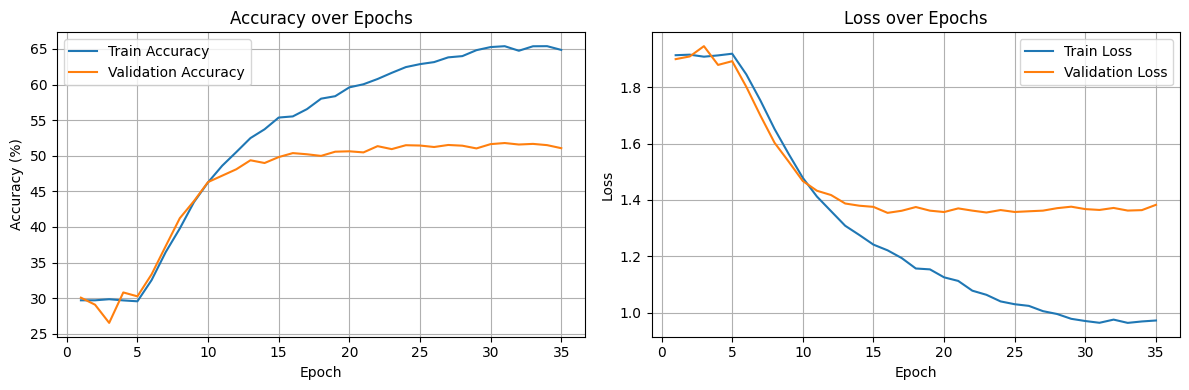

In [57]:
# Построение графиков
epochs_axis = list(range(1, len(history['train_acc']) + 1))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_axis, history['train_acc'], label='Train Accuracy')
plt.plot(epochs_axis, history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_axis, history['train_loss'], label='Train Loss')
plt.plot(epochs_axis, history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

✅ Найдена финальная модель BiT V2: final_bit_model_v2.pth

📋 Загрузка модели BiT V2: final_bit_model_v2.pth
✅ Чекпоинт загружен. Ключи: ['epoch', 'model_state_dict', 'val_acc', 'val_loss', 'history', 'timestamp']
📊 Точность модели (из чекпоинта): 51.78160289441947
🔧 Ожидаемое количество классов: 9
🔧 Инициализация BiT ResNet50 V2...
⚠️ Создана модель без предобучения
✅ BiT-style голова создана (Linear(2048, 9))
✅ Веса модели загружены

📊 Найдено тестовых изображений: 5000

⏱️  ИЗМЕРЕНИЕ ВРЕМЕНИ ИНФЕРЕНСА
--------------------------------------------------


Тест скорости инференса BiT V2: 100%|█████████| 100/100 [00:09<00:00, 10.58it/s]



📈 СТАТИСТИКА ВРЕМЕНИ ИНФЕРЕНСА (на основе 100 измерений):
  Среднее время: 0.0941 сек
  Медианное время: 0.0923 сек
  Стандартное отклонение: 0.0109 сек
  Минимальное время: 0.0818 сек
  Максимальное время: 0.1792 сек
  FPS: 10.6 кадров/сек

✅ ТРЕБОВАНИЕ ТЗ: < 0.33 сек на изображение
   Результат: 0.0923 сек ✅ ВЫПОЛНЕНО


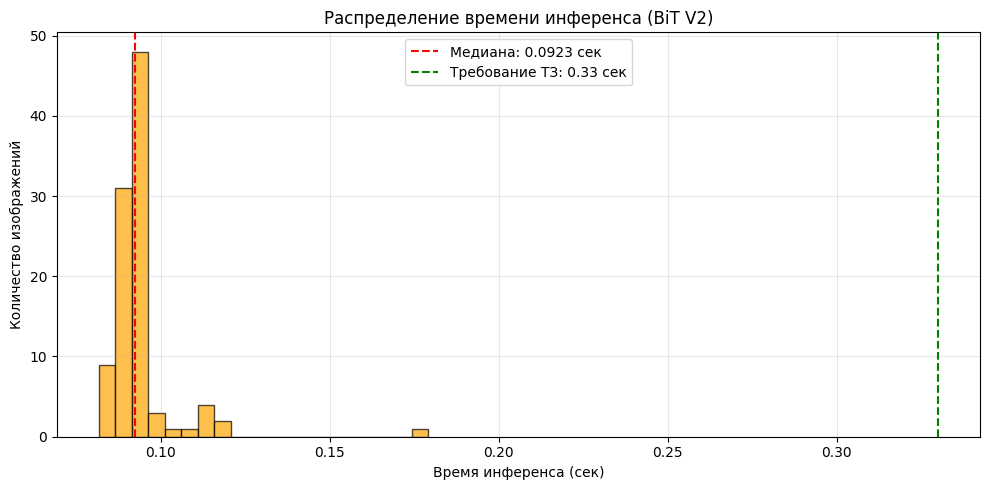

  📊 График сохранен: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_results_v2/inference_time_bit_v2_final.png

📝 СОЗДАНИЕ SUBMISSION ФАЙЛА для 5000 изображений
--------------------------------------------------


Обработка тестовых изображений BiT V2: 100%|█| 5000/5000 [08:06<00:00, 10.27it/s



✅ SUBMISSION СОЗДАН:
  📄 Kaggle submission: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_results_v2/kaggle_submission_bit_v2_final.csv
  📄 Полные данные: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_results_v2/submission_full_bit_v2_final.csv
  📊 Всего предсказаний: 5000
  📈 Средняя уверенность: 0.613

📊 АНАЛИЗ РАСПРЕДЕЛЕНИЯ ПРЕДСКАЗАНИЙ:
emotion
neutral      670
anger        670
sad          643
surprise     580
contempt     556
happy        508
fear         482
disgust      470
uncertain    421
Name: count, dtype: int64


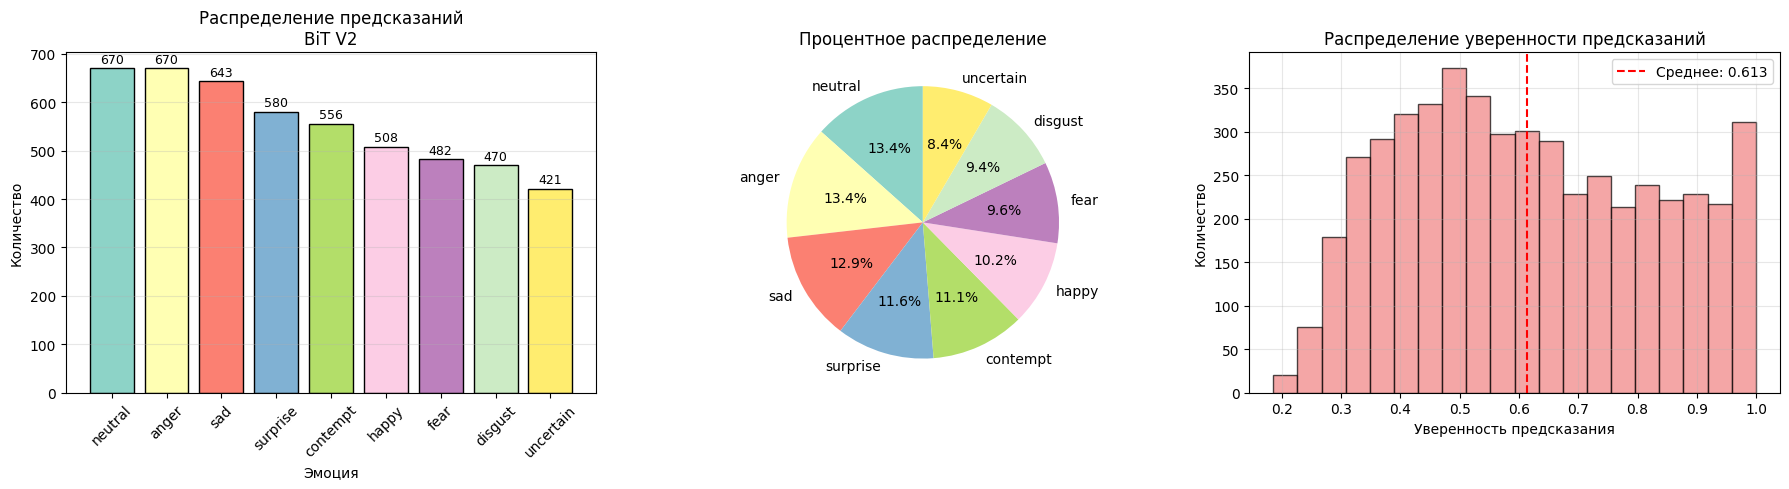

  📊 График распределения сохранен: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_results_v2/prediction_distribution_bit_v2_final.png

📈 СТАТИСТИКА ПРЕДСКАЗАНИЙ:
----------------------------------------
  neutral        670 ( 13.4%) | уверенность: 0.533
  anger          670 ( 13.4%) | уверенность: 0.619
  sad            643 ( 12.9%) | уверенность: 0.635
  surprise       580 ( 11.6%) | уверенность: 0.601
  contempt       556 ( 11.1%) | уверенность: 0.597
  happy          508 ( 10.2%) | уверенность: 0.749
  fear           482 (  9.6%) | уверенность: 0.662
  disgust        470 (  9.4%) | уверенность: 0.635
  uncertain      421 (  8.4%) | уверенность: 0.494

📊 Общая статистика:
    Средняя уверенность: 0.613
    Медианная уверенность: 0.592
    Минимальная уверенность: 0.186
    Максимальная уверенность: 1.000
  📄 Статистика сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (

In [58]:

import torch
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Убедимся, что BASE_DIR и config определены
# BASE_DIR должен быть тем же, что и в основном коде
BASE_DIR = Path("/Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22")
# config - это экземпляр BiTConfigV2 из предыдущего кода
# Если ноутбук перезапускался, его нужно создать заново:
class BiTConfigV2:
    # Параметры обучения
    BATCH_SIZE = 32
    BASE_LR = 0.01
    WEIGHT_DECAY = 0.0001
    IMG_SIZE = 224
    # Двухступенчатое обучение
    STAGE1_EPOCHS = 5
    STAGE2_EPOCHS = 30
    TOTAL_EPOCHS = STAGE1_EPOCHS + STAGE2_EPOCHS
    # Аугментации
    CROP_SCALE_MIN = 0.8
    COLOR_JITTER_BRIGHTNESS = 0.4
    # Регуляризация
    MIXUP_ALPHA = 0.0
    LABEL_SMOOTHING_EPS = 0.0
    # Scheduler
    WARMUP_EPOCHS = 5
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Пути
    MODELS_DIR = BASE_DIR / "bit_models_v2"
    RESULTS_DIR = BASE_DIR / "bit_results_v2" # Используем RESULTS_DIR для вывода

config = BiTConfigV2()
config.RESULTS_DIR.mkdir(exist_ok=True, parents=True)

# Путь к тестовой директории
PROCESSED_TEST_DIR = BASE_DIR / "processed_data" / "test_cropped_faces"

# Классы (предполагается, что они те же)
CLASSES = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise', 'uncertain']
idx_to_class = {idx: cls for idx, cls in enumerate(CLASSES)}
class_to_idx = {cls: idx for idx, cls in enumerate(CLASSES)}

# Функция для создания submission
def create_submission_for_bit_v2(model_path, test_dir, idx_to_class, output_name="bit_v2"):
    """
    Создание submission файла для Kaggle для BiT V2 модели
    """
    print(f"\n📋 Загрузка модели BiT V2: {model_path.name}")

    # --- 1. Загрузка чекпоинта ---
    try:
        checkpoint = torch.load(model_path, map_location=config.DEVICE)
        print(f"✅ Чекпоинт загружен. Ключи: {list(checkpoint.keys())}")
    except FileNotFoundError:
        print(f"❌ Файл модели не найден: {model_path}")
        return None
    except Exception as e:
        print(f"❌ Ошибка при загрузке чекпоинта: {e}")
        return None

    # --- 2. Извлечение метрик и состояния модели ---
    model_accuracy = checkpoint.get('val_acc', checkpoint.get('best_val_acc', 'N/A'))
    print(f"📊 Точность модели (из чекпоинта): {model_accuracy}")

    # --- 3. Создание и инициализация модели ---
    # Важно: использовать тот же класс и количество классов, что и при обучении
    num_classes_from_checkpoint = checkpoint.get('model_config', {}).get('num_classes', len(idx_to_class))
    print(f"🔧 Ожидаемое количество классов: {num_classes_from_checkpoint}")

    model = BiTResNet50V2(num_classes=num_classes_from_checkpoint, pretrained=False) # pretrained=False, так как веса загружаются
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Веса модели загружены")

    model.to(config.DEVICE)
    model.eval()  # Переключаем в режим inference

    # --- 4. Трансформации для тестовых данных (та же, что и валидационная для V2) ---
    test_transform = transforms.Compose([
        transforms.Resize(int(config.IMG_SIZE * 1.14)),
        transforms.CenterCrop(config.IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # --- 5. Получаем список тестовых изображений ---
    test_images = sorted([f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    print(f"\n📊 Найдено тестовых изображений: {len(test_images)}")

    # --- 6. ИЗМЕРЕНИЕ ВРЕМЕНИ ИНФЕРЕНСА ---
    print(f"\n⏱️  ИЗМЕРЕНИЕ ВРЕМЕНИ ИНФЕРЕНСА")
    print("-" * 50)

    # Тестируем на 100 изображениях или всех, если их меньше
    test_sample = test_images[:min(100, len(test_images))]
    inference_times = []

    with torch.no_grad():
        for img_file in tqdm(test_sample, desc="Тест скорости инференса BiT V2"):
            img_path = test_dir / img_file
            try:
                # Загрузка и преобразование
                start_time = time.time()
                image = Image.open(img_path).convert('RGB')
                image_tensor = test_transform(image).unsqueeze(0).to(config.DEVICE)

                # Предсказание
                outputs = model(image_tensor)
                probabilities = F.softmax(outputs, dim=1)
                _, predicted_idx = outputs.max(1)

                end_time = time.time()
                inference_times.append(end_time - start_time)
            except Exception as e:
                print(f"❌ Ошибка при обработке {img_file}: {e}")
                # Добавляем время ошибки как 0, чтобы не нарушать счётчик
                inference_times.append(0)

    # --- 7. Статистика времени инференса ---
    if inference_times:
        # Убираем нулевые значения из статистики, если были ошибки
        valid_inference_times = [t for t in inference_times if t > 0]
        if not valid_inference_times:
             print("⚠️  Все измерения времени оказались нулевыми (возможны ошибки чтения изображений).")
             return None

        mean_time = np.mean(valid_inference_times)
        median_time = np.median(valid_inference_times)
        std_time = np.std(valid_inference_times)
        min_time = min(valid_inference_times)
        max_time = max(valid_inference_times)

        print(f"\n📈 СТАТИСТИКА ВРЕМЕНИ ИНФЕРЕНСА (на основе {len(valid_inference_times)} измерений):")
        print(f"  Среднее время: {mean_time:.4f} сек")
        print(f"  Медианное время: {median_time:.4f} сек")
        print(f"  Стандартное отклонение: {std_time:.4f} сек")
        print(f"  Минимальное время: {min_time:.4f} сек")
        print(f"  Максимальное время: {max_time:.4f} сек")
        print(f"  FPS: {1/mean_time:.1f} кадров/сек")

        # Проверка требования ТЗ (0.33 сек на изображение)
        requirement_met = median_time < 0.33
        print(f"\n✅ ТРЕБОВАНИЕ ТЗ: < 0.33 сек на изображение")
        print(f"   Результат: {median_time:.4f} сек {'✅ ВЫПОЛНЕНО' if requirement_met else '❌ НЕ ВЫПОЛНЕНО'}")

        # --- 8. Визуализация времени инференса ---
        plt.figure(figsize=(10, 5))
        plt.hist(valid_inference_times, bins=20, alpha=0.7, color='orange', edgecolor='black')
        plt.axvline(median_time, color='red', linestyle='--', label=f'Медиана: {median_time:.4f} сек')
        plt.axvline(0.33, color='green', linestyle='--', label='Требование ТЗ: 0.33 сек')
        plt.xlabel('Время инференса (сек)')
        plt.ylabel('Количество изображений')
        plt.title(f'Распределение времени инференса (BiT V2)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        # Сохранение графика
        inference_plot_path = config.RESULTS_DIR / f"inference_time_{output_name}.png"
        plt.savefig(inference_plot_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  📊 График сохранен: {inference_plot_path}")
    else:
        print("⚠️  Не удалось получить ни одного измерения времени инференса.")
        return None

    # --- 9. СОЗДАНИЕ SUBMISSION ФАЙЛА для ВСЕХ тестовых изображений ---
    print(f"\n📝 СОЗДАНИЕ SUBMISSION ФАЙЛА для {len(test_images)} изображений")
    print("-" * 50)

    submission_data = []
    confidence_scores = []

    with torch.no_grad():
        pbar = tqdm(test_images, desc="Обработка тестовых изображений BiT V2")
        for img_file in pbar:
            img_path = test_dir / img_file
            try:
                # Загрузка и преобразование
                image = Image.open(img_path).convert('RGB')
                image_tensor = test_transform(image).unsqueeze(0).to(config.DEVICE)

                # Предсказание
                outputs = model(image_tensor)
                probabilities = F.softmax(outputs, dim=1)
                _, predicted_idx = outputs.max(1)

                # Получение эмоции и уверенности
                predicted_class_idx = predicted_idx.item()
                if predicted_class_idx in idx_to_class:
                     emotion = idx_to_class[predicted_class_idx]
                else:
                     print(f"⚠️ Неверный индекс класса {predicted_class_idx}, используем 'neutral'")
                     emotion = 'neutral'

                confidence = probabilities[0, predicted_idx].item()
                confidence_scores.append(confidence)

                submission_data.append({
                    'image_path': img_file,
                    'emotion': emotion,
                    'confidence': confidence,
                    'predicted_idx': predicted_class_idx,
                    'top_probability': confidence
                })
            except Exception as e:
                print(f"\n❌ Ошибка при обработке {img_file}: {e}")
                # В случае ошибки, добавляем дефолтное предсказание
                submission_data.append({
                    'image_path': img_file,
                    'emotion': 'neutral', # Дефолт
                    'confidence': 0.0,
                    'predicted_idx': 0, # Дефолтный индекс
                    'top_probability': 0.0
                })
                confidence_scores.append(0.0)

    # --- 10. Создание DataFrame и сохранение ---
    submission_df = pd.DataFrame(submission_data)

    # Сохранение в CSV (формат для Kaggle)
    kaggle_df = submission_df[['image_path', 'emotion']].copy()
    output_path = config.RESULTS_DIR / f"kaggle_submission_{output_name}.csv"
    kaggle_df.to_csv(output_path, index=False)

    # Сохранение полных данных
    full_data_path = config.RESULTS_DIR / f"submission_full_{output_name}.csv"
    submission_df.to_csv(full_data_path, index=False)

    print(f"\n✅ SUBMISSION СОЗДАН:")
    print(f"  📄 Kaggle submission: {output_path}")
    print(f"  📄 Полные данные: {full_data_path}")
    print(f"  📊 Всего предсказаний: {len(submission_df)}")
    print(f"  📈 Средняя уверенность: {np.mean(confidence_scores):.3f}")

    # --- 11. Анализ распределения предсказаний ---
    print(f"\n📊 АНАЛИЗ РАСПРЕДЕЛЕНИЯ ПРЕДСКАЗАНИЙ:")
    emotion_counts = submission_df['emotion'].value_counts()
    print(emotion_counts)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Bar plot
    colors = plt.cm.Set3(np.linspace(0, 1, len(emotion_counts)))
    bars = axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='black')
    axes[0].set_title(f'Распределение предсказаний\nBiT V2', fontsize=12)
    axes[0].set_xlabel('Эмоция')
    axes[0].set_ylabel('Количество')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 5,
                     f'{int(height)}', ha='center', va='bottom', fontsize=9)

    # 2. Pie chart
    axes[1].pie(emotion_counts.values, labels=emotion_counts.index,
                autopct='%1.1f%%', startangle=90, colors=colors)
    axes[1].set_title('Процентное распределение', fontsize=12)

    # 3. Confidence distribution
    axes[2].hist(confidence_scores, bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[2].axvline(np.mean(confidence_scores), color='red', linestyle='--',
                    label=f'Среднее: {np.mean(confidence_scores):.3f}')
    axes[2].set_xlabel('Уверенность предсказания')
    axes[2].set_ylabel('Количество')
    axes[2].set_title('Распределение уверенности предсказаний', fontsize=12)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    # Сохранение графика распределения
    distribution_plot_path = config.RESULTS_DIR / f"prediction_distribution_{output_name}.png"
    plt.savefig(distribution_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  📊 График распределения сохранен: {distribution_plot_path}")

    # --- 12. Вывод статистики ---
    print("\n📈 СТАТИСТИКА ПРЕДСКАЗАНИЙ:")
    print("-" * 40)
    for emotion, count in emotion_counts.items():
        percentage = count / len(submission_df) * 100
        avg_confidence = submission_df[submission_df['emotion'] == emotion]['confidence'].mean()
        print(f"  {emotion:<12} {count:>5} ({percentage:>5.1f}%) | уверенность: {avg_confidence:.3f}")

    print(f"\n📊 Общая статистика:")
    print(f"    Средняя уверенность: {np.mean(confidence_scores):.3f}")
    print(f"    Медианная уверенность: {np.median(confidence_scores):.3f}")
    print(f"    Минимальная уверенность: {np.min(confidence_scores):.3f}")
    print(f"    Максимальная уверенность: {np.max(confidence_scores):.3f}")

    # --- 13. Сохранение статистики в файл ---
    stats_data = []
    for emotion, count in emotion_counts.items():
        percentage = count / len(submission_df) * 100
        avg_conf = submission_df[submission_df['emotion'] == emotion]['confidence'].mean()
        stats_data.append({
            'emotion': emotion,
            'count': count,
            'percentage': percentage,
            'avg_confidence': avg_conf
        })
    stats_df = pd.DataFrame(stats_data)
    stats_path = config.RESULTS_DIR / f"submission_stats_{output_name}.csv"
    stats_df.to_csv(stats_path, index=False)
    print(f"  📄 Статистика сохранена: {stats_path}")

    return {
        'model_name': output_name,
        'model_accuracy': model_accuracy,
        'inference_time_median': median_time,
        'inference_time_mean': mean_time,
        'fps': 1/mean_time if mean_time > 0 else 0,
        'requirement_met': requirement_met,
        'submission_path': output_path,
        'full_data_path': full_data_path,
        'stats_path': stats_path,
        'emotion_distribution': emotion_counts.to_dict(),
        'avg_confidence': np.mean(confidence_scores),
        'total_predictions': len(submission_df)
    }


# --- ЗАПУСК СОЗДАНИЯ SUBMISSION ---
# Укажите путь к финальной модели, обученной по V2 схеме
FINAL_BIT_V2_MODEL_PATH = config.MODELS_DIR / "final_bit_model_v2.pth"

if FINAL_BIT_V2_MODEL_PATH.exists():
    print(f"✅ Найдена финальная модель BiT V2: {FINAL_BIT_V2_MODEL_PATH.name}")
    submission_info_bit_v2 = create_submission_for_bit_v2(
        model_path=FINAL_BIT_V2_MODEL_PATH,
        test_dir=PROCESSED_TEST_DIR,
        idx_to_class=idx_to_class,
        output_name="bit_v2_final"
    )
    if submission_info_bit_v2:
        print(f"\n🎉 Процесс для BiT V2 завершён успешно!")
        print(f"   Точность (из чекпоинта): {submission_info_bit_v2['model_accuracy']}")
        print(f"   Время инференса (медиана): {submission_info_bit_v2['inference_time_median']:.4f} сек")
        print(f"   Требование ТЗ: {'✅ ВЫПОЛНЕНО' if submission_info_bit_v2['requirement_met'] else '❌ НЕ ВЫПОЛНЕНО'}")
        print(f"   Файл Kaggle submission: {submission_info_bit_v2['submission_path']}")
else:
    print(f"❌ Финальная модель BiT V2 не найдена по пути: {FINAL_BIT_V2_MODEL_PATH}")
    # Поищем любую модель в директории, если путь отличается
    available_models = list(config.MODELS_DIR.glob("*.pth"))
    if available_models:
        print(f"ℹ️  Найдены другие .pth файлы в {config.MODELS_DIR}:")
        for m in available_models:
            print(f"  - {m.name}")
    else:
        print(f"❌ В директории {config.MODELS_DIR} нет .pth файлов.")


In [ ]:
BiT V2 Balanced

In [4]:

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torch.optim import SGD
from torch.optim.lr_scheduler import LambdaLR
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from tqdm import tqdm
import time
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# Повторяем конфигурацию BiT V2 (если сессия новая)
class BiTConfigV2:
    # Архитектура
    MODEL_NAME = "resnet50_v2_balanced"
    NUM_CLASSES = 9

    # Параметры обучения
    BATCH_SIZE = 32
    BASE_LR = 0.01
    WEIGHT_DECAY = 0.0001
    IMG_SIZE = 224

    # Двухступенчатое обучение
    STAGE1_EPOCHS = 5  # Только голова
    STAGE2_EPOCHS = 30 # Все слои
    TOTAL_EPOCHS = STAGE1_EPOCHS + STAGE2_EPOCHS

    # Аугментации
    CROP_SCALE_MIN = 0.8
    COLOR_JITTER_BRIGHTNESS = 0.4

    # Регуляризация (отключена на старте!)
    MIXUP_ALPHA = 0.0
    LABEL_SMOOTHING_EPS = 0.0

    # Scheduler
    WARMUP_EPOCHS = 5

    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Пути (можем использовать отдельную поддиректорию для балансировки)
    BASE_DIR = Path("/Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22")
    MODELS_DIR = BASE_DIR / "bit_models_v2_balanced"
    RESULTS_DIR = BASE_DIR / "bit_results_v2_balanced"

config = BiTConfigV2()

# Создание директорий
config.MODELS_DIR.mkdir(exist_ok=True, parents=True)
config.RESULTS_DIR.mkdir(exist_ok=True, parents=True)

print(f"📊 КОНФИГУРАЦИЯ BI-T МОДЕЛИ V2 (Балансировка):")
print(f"  Имя модели: {config.MODEL_NAME}")
print(f"  Batch size: {config.BATCH_SIZE}")
print(f"  Base LR: {config.BASE_LR}")
print(f"  Устройство: {config.DEVICE}")
print(f"  Директория моделей: {config.MODELS_DIR}")
print(f"  Директория результатов: {config.RESULTS_DIR}")

PROCESSED_TRAIN_DIR = config.BASE_DIR / "processed_data" / "train_cropped_faces"
PROCESSED_TEST_DIR = config.BASE_DIR / "processed_data" / "test_cropped_faces"

📊 КОНФИГУРАЦИЯ BI-T МОДЕЛИ V2 (Балансировка):
  Имя модели: resnet50_v2_balanced
  Batch size: 32
  Base LR: 0.01
  Устройство: cpu
  Директория моделей: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_models_v2_balanced
  Директория результатов: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_results_v2_balanced


✅ Загружено 45629 успешных записей из метаданных.
📊 Исходное количество изображений: 45629
📊 Распределение по классам в исходном датасете:
class
anger        6278
neutral      6244
sad          6091
surprise     5828
happy        5704
uncertain    5482
fear         4248
contempt     2926
disgust      2828
Name: count, dtype: int64


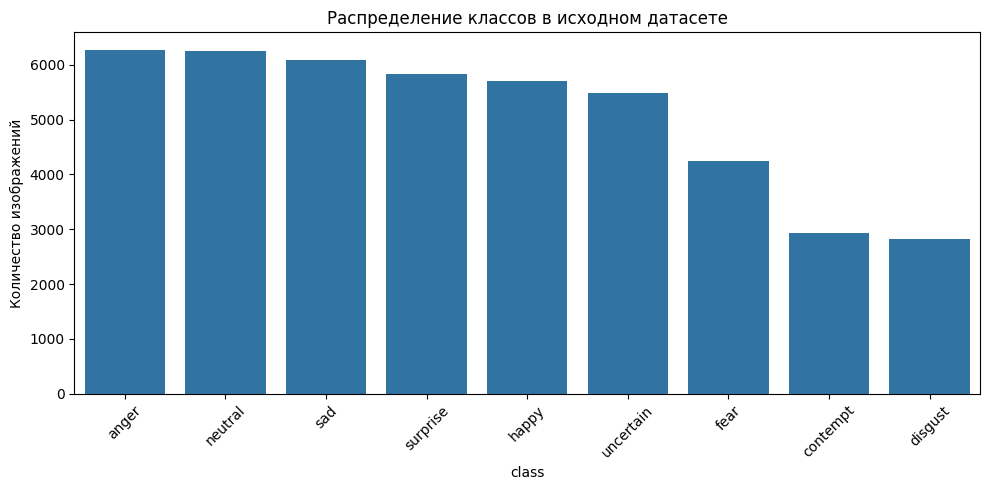

In [60]:
# Загрузка метаданных 
metadata_path = config.BASE_DIR / "processed_data" / "train_processed_metadata.csv"
if metadata_path.exists():
    train_metadata_orig = pd.read_csv(metadata_path)
    train_metadata_orig = train_metadata_orig[train_metadata_orig['success'] == True]
    print(f"✅ Загружено {len(train_metadata_orig)} успешных записей из метаданных.")
else:
    print(f"⚠️ Файл метаданных не найден, создаем из директории.")
    classes = [d for d in os.listdir(PROCESSED_TRAIN_DIR) if os.path.isdir(PROCESSED_TRAIN_DIR / d)]
    metadata_rows = []
    for class_name in classes:
        class_dir = PROCESSED_TRAIN_DIR / class_name
        images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for img_file in images:
            metadata_rows.append({'filename': img_file, 'class': class_name, 'success': True})
    train_metadata_orig = pd.DataFrame(metadata_rows)

print(f"📊 Исходное количество изображений: {len(train_metadata_orig)}")
print(f"📊 Распределение по классам в исходном датасете:")
orig_dist = train_metadata_orig['class'].value_counts()
print(orig_dist)
plt.figure(figsize=(10, 5))
sns.barplot(x=orig_dist.index, y=orig_dist.values)
plt.title('Распределение классов в исходном датасете')
plt.xticks(rotation=45)
plt.ylabel('Количество изображений')
plt.tight_layout()
plt.show()


🎯 Целевое количество изображений на класс: 6278
  anger: 6278 (оставлен как есть)
  neutral: 6244 -> 6278 (upsampled)
  sad: 6091 -> 6278 (upsampled)
  surprise: 5828 -> 6278 (upsampled)
  happy: 5704 -> 6278 (upsampled)
  uncertain: 5482 -> 6278 (upsampled)
  fear: 4248 -> 6278 (upsampled)
  contempt: 2926 -> 6278 (upsampled)
  disgust: 2828 -> 6278 (upsampled)

📊 Новое количество изображений (сбалансированный): 56502
📊 Новое распределение по классам:
class
neutral      6278
uncertain    6278
contempt     6278
anger        6278
disgust      6278
surprise     6278
fear         6278
sad          6278
happy        6278
Name: count, dtype: int64


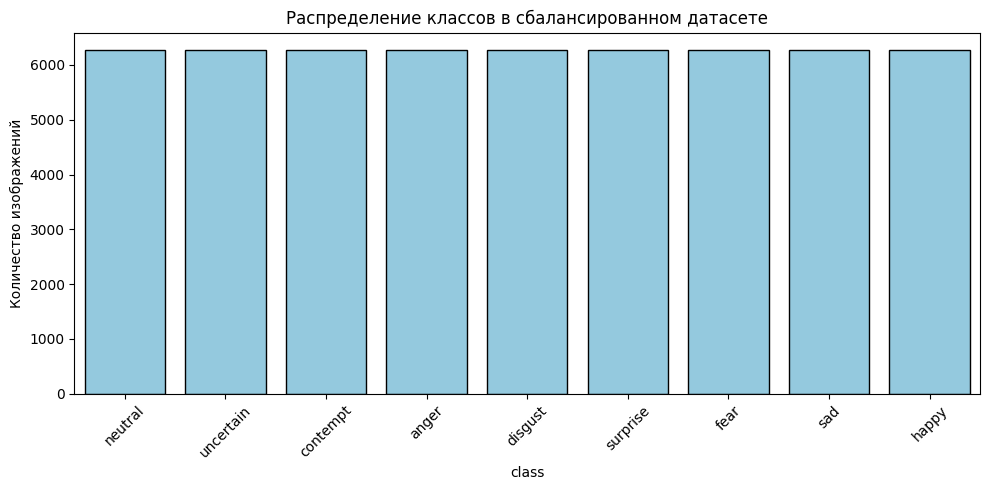


💾 Сбалансированный датасет сохранён: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_results_v2_balanced/balanced_train_metadata.csv


In [61]:
# Балансировка: Upsample до среднего значения или до max, или до заданного порога
target_count = orig_dist.max() # Балансируем до количества самого большого класса
# target_count = int(orig_dist.mean()) # Или до среднего (меньше данных, быстрее обучение)
print(f"\n🎯 Целевое количество изображений на класс: {target_count}")

balanced_data = []
for class_name in orig_dist.index:
    class_data = train_metadata_orig[train_metadata_orig['class'] == class_name]
    current_count = len(class_data)
    if current_count < target_count:
        # Делаем oversampling
        upsampled = class_data.sample(n=target_count, replace=True, random_state=42)
        balanced_data.append(upsampled)
        print(f"  {class_name}: {current_count} -> {target_count} (upsampled)")
    else:
        # Оставляем как есть или undersample, если превышает target_count
        # Для простоты оставим как есть, если он >= target_count
        balanced_data.append(class_data)
        print(f"  {class_name}: {current_count} (оставлен как есть)")

balanced_df = pd.concat(balanced_data, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📊 Новое количество изображений (сбалансированный): {len(balanced_df)}")
print(f"📊 Новое распределение по классам:")
new_dist = balanced_df['class'].value_counts()
print(new_dist)
plt.figure(figsize=(10, 5))
sns.barplot(x=new_dist.index, y=new_dist.values, color='skyblue', edgecolor='black')
plt.title('Распределение классов в сбалансированном датасете')
plt.xticks(rotation=45)
plt.ylabel('Количество изображений')
plt.tight_layout()
plt.show()

# Сохраняем новый сбалансированный датасет
balanced_csv_path = config.RESULTS_DIR / "balanced_train_metadata.csv"
balanced_df.to_csv(balanced_csv_path, index=False)
print(f"\n💾 Сбалансированный датасет сохранён: {balanced_csv_path}")

In [62]:
# Разделяем сбалансированный датасет на train/val
train_dfs = []
val_dfs = []
for class_name in balanced_df['class'].unique():
    class_df = balanced_df[balanced_df['class'] == class_name].sample(frac=1, random_state=42).reset_index(drop=True)
    n_val = int(len(class_df) * 0.2) # 20% на валидацию
    class_val_df = class_df.iloc[:n_val]
    class_train_df = class_df.iloc[n_val:]
    train_dfs.append(class_train_df)
    val_dfs.append(class_val_df)

df_train_balanced = pd.concat(train_dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df_val_balanced = pd.concat(val_dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"📊 Сбалансированный Train: {len(df_train_balanced)}")
print(f"📊 Сбалансированный Val: {len(df_val_balanced)}")

# Маппинг классов
classes = sorted(df_train_balanced['class'].unique())
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for idx, cls in enumerate(classes)}
print(f"🗺️  Классы: {idx_to_class}")

# Dataset
class BitBalancedDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.root_dir / row['class'] / row['filename']
        try:
            image = plt.imread(img_path)[:,:,:3] # Basic loading
            image = torch.tensor(image, dtype=torch.uint8).permute(2, 0, 1) # HWC -> CHW
            image = transforms.ToPILImage()(image)
        except:
             print(f"❌ Ошибка загрузки {img_path}")
             image = transforms.ToPILImage()(torch.ones(3, config.IMG_SIZE, config.IMG_SIZE)*128) # Grey fallback
        if self.transform:
            image = self.transform(image)
        label = self.class_to_idx[row['class']]
        return image, label

# Аугментации 
def get_train_transforms_v2_balanced(img_size=config.IMG_SIZE, color_jitter=config.COLOR_JITTER_BRIGHTNESS):
    transform_list = [
        transforms.RandomResizedCrop(size=img_size, scale=(config.CROP_SCALE_MIN, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
    ]
    if color_jitter > 0:
        transform_list.append(
            transforms.ColorJitter(brightness=color_jitter, contrast=color_jitter, saturation=color_jitter, hue=min(0.1, color_jitter/2))
        )
    transform_list.extend([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return transforms.Compose(transform_list)

def get_val_transforms_v2_balanced(img_size=config.IMG_SIZE):
    return transforms.Compose([
        transforms.Resize(int(img_size * 1.14)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# Создание dataset'ов
train_dataset_balanced = BitBalancedDataset(df_train_balanced, PROCESSED_TRAIN_DIR, transform=get_train_transforms_v2_balanced())
val_dataset_balanced = BitBalancedDataset(df_val_balanced, PROCESSED_TRAIN_DIR, transform=get_val_transforms_v2_balanced())

# DataLoader'ы
# Для сбалансированного датасета WeightedRandomSampler может быть не нужен, так как классы уже сбалансированы
# Но мы можем использовать обычный sampler или просто shuffle=True
train_loader_balanced = DataLoader(train_dataset_balanced, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader_balanced = DataLoader(val_dataset_balanced, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"✅ Сбалансированные Dataset'ы и DataLoader'ы созданы.")
print(f"  Balanced Train batches: {len(train_loader_balanced)}")
print(f"  Balanced Val batches: {len(val_loader_balanced)}")

# Проверим распределение в DataLoader
train_dist_dl = pd.Series([idx_to_class[label] for _, label in train_dataset_balanced]).value_counts()
val_dist_dl = pd.Series([idx_to_class[label] for _, label in val_dataset_balanced]).value_counts()
print(f"\n📊 Распределение в Balanced Train Dataset:")
print(train_dist_dl)
print(f"\n📊 Распределение в Balanced Val Dataset:")
print(val_dist_dl)

📊 Сбалансированный Train: 45207
📊 Сбалансированный Val: 11295
🗺️  Классы: {0: 'anger', 1: 'contempt', 2: 'disgust', 3: 'fear', 4: 'happy', 5: 'neutral', 6: 'sad', 7: 'surprise', 8: 'uncertain'}
✅ Сбалансированные Dataset'ы и DataLoader'ы созданы.
  Balanced Train batches: 1413
  Balanced Val batches: 353

📊 Распределение в Balanced Train Dataset:
uncertain    5023
disgust      5023
surprise     5023
fear         5023
contempt     5023
neutral      5023
anger        5023
sad          5023
happy        5023
Name: count, dtype: int64

📊 Распределение в Balanced Val Dataset:
sad          1255
disgust      1255
happy        1255
uncertain    1255
contempt     1255
anger        1255
surprise     1255
fear         1255
neutral      1255
Name: count, dtype: int64


In [63]:
# Определяем модель (та же, что и в V2)
class BiTResNet50V2(nn.Module):
    def __init__(self, num_classes=config.NUM_CLASSES, pretrained=True):
        super(BiTResNet50V2, self).__init__()
        print(f"🔧 Инициализация BiT ResNet50 V2 (Balanced)...")

        if pretrained:
            weights = ResNet50_Weights.IMAGENET1K_V1
            self.base_model = resnet50(weights=weights)
            print(f"✅ Загружены веса ImageNet1K_V1")
        else:
            self.base_model = resnet50()
            print(f"⚠️ Создана модель без предобучения")

        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()
        self.head = nn.Linear(num_features, num_classes)
        nn.init.normal_(self.head.weight, mean=0, std=0.01)
        nn.init.zeros_(self.head.bias)
        print(f"✅ BiT-style голова создана (Linear({num_features}, {num_classes}))")

    def forward(self, x):
        features = self.base_model(x)
        output = self.head(features)
        return output

    def freeze_all_but_head(self):
        for param in self.base_model.parameters():
            param.requires_grad = False
        for param in self.head.parameters():
            param.requires_grad = True
        print(f"🔒 Базовая модель заморожена, обучается только голова.")

    def unfreeze_all(self):
        for param in self.parameters():
            param.requires_grad = True
        print(f"🔓 Все слои разморожены для обучения.")

    def get_trainable_params(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        return trainable, total

# Создание и отправка модели на устройство
model_balanced = BiTResNet50V2(num_classes=len(classes))
model_balanced.to(config.DEVICE)
print(f"✅ Модель (Balanced) перемещена на {config.DEVICE}")

trainable_params, total_params = model_balanced.get_trainable_params()
print(f"📊 Параметры модели (Balanced): {total_params:,} всего, {trainable_params:,} обучаемых")

# Функции обучения (повторяем из V2)
def validate_model(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            _, preds = torch.max(outputs, 1)
            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(data_loader)
    accuracy = 100 * correct_predictions / total_samples
    return avg_loss, accuracy, all_preds, all_labels

def save_model(model, path, epoch, val_acc, val_loss, history, extra_info=None):
    state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'val_acc': val_acc,
        'val_loss': val_loss,
        'history': history,
        'timestamp': datetime.now().isoformat(),
    }
    if extra_info:
        state.update(extra_info)
    torch.save(state, path)
    print(f"💾 Модель сохранена: {path}")

def create_optimizer_and_scheduler(model, lr, total_epochs, warmup_epochs):
    optimizer = SGD(params=model.parameters(), lr=lr, momentum=0.9, weight_decay=config.WEIGHT_DECAY, nesterov=True)
    
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        else:
            if total_epochs <= warmup_epochs:
                 return 1.0
            progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
            return 0.5 * (1 + np.cos(np.pi * progress))
            
    scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)
    return optimizer, scheduler

criterion_balanced = nn.CrossEntropyLoss()

🔧 Инициализация BiT ResNet50 V2 (Balanced)...
✅ Загружены веса ImageNet1K_V1
✅ BiT-style голова создана (Linear(2048, 9))
✅ Модель (Balanced) перемещена на cpu
📊 Параметры модели (Balanced): 23,526,473 всего, 23,526,473 обучаемых



🚀 НАЧАЛО ОБУЧЕНИЯ BI-T МОДЕЛИ НА СБАЛАНСИРОВАННОМ ДАТАСЕТЕ

--- STAGE 1 (Balanced): Обучение только головы (5 эпох) ---
🔒 Базовая модель заморожена, обучается только голова.
  Обучаемых параметров: 18,441 (0.08%)


Stage1 Balanced Epoch 1: 100%|█| 1413/1413 [1:07:14<00:00,  2.86s/it, acc=21.1, 


Epoch 1: Train Loss: 2.0967, Acc: 21.14%, Val Loss: 2.0155, Acc: 25.76%
💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_models_v2_balanced/best_model_stage1_balanced.pth
   🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ (Stage 1 Balanced)! Acc: 25.76%


Stage1 Balanced Epoch 2: 100%|█| 1413/1413 [1:07:35<00:00,  2.87s/it, acc=26.2, 


Epoch 2: Train Loss: 1.9966, Acc: 26.17%, Val Loss: 1.9521, Acc: 28.90%
💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_models_v2_balanced/best_model_stage1_balanced.pth
   🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ (Stage 1 Balanced)! Acc: 28.90%


...

Epoch 28: Train Loss: 0.6460, Acc: 78.13%, Val Loss: 0.9902, Acc: 67.40%
💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_models_v2_balanced/best_model_stage2_balanced.pth
   🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ (Stage 2 Balanced)! Acc: 67.40%


Stage2 Balanced Epoch 29: 100%|█| 1413/1413 [3:10:58<00:00,  8.11s/it, acc=78.3,


Epoch 29: Train Loss: 0.6452, Acc: 78.28%, Val Loss: 0.9956, Acc: 66.95%


Stage2 Balanced Epoch 30: 100%|█| 1413/1413 [3:11:29<00:00,  8.13s/it, acc=78.3,


Epoch 30: Train Loss: 0.6430, Acc: 78.28%, Val Loss: 0.9990, Acc: 66.91%
💾 Модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_models_v2_balanced/final_bit_model_v2_balanced.pth

🏁 ОБУЧЕНИЕ НА СБАЛАНСИРОВАННОМ ДАТАСЕТЕ ЗАВЕРШЕНО
   Лучшая валидационная точность: 67.40% (эпоха 33)
   Финальная модель сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_models_v2_balanced/final_bit_model_v2_balanced.pth


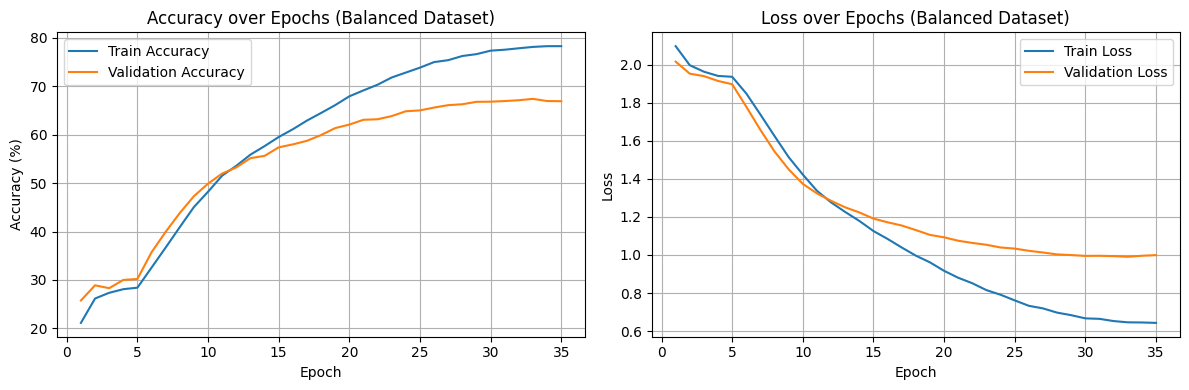

📊 График сохранён: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_results_v2_balanced/training_progress_balanced.png


In [64]:
print(f"\n{'='*60}")
print("🚀 НАЧАЛО ОБУЧЕНИЯ BI-T МОДЕЛИ НА СБАЛАНСИРОВАННОМ ДАТАСЕТЕ")
print(f"{'='*60}")

history_balanced = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_balanced = 0.0
best_epoch_balanced = 0

# --- STAGE 1: Обучение только головы ---
print(f"\n--- STAGE 1 (Balanced): Обучение только головы ({config.STAGE1_EPOCHS} эпох) ---")
model_balanced.freeze_all_but_head()
trainable_params, total_params = model_balanced.get_trainable_params()
print(f"  Обучаемых параметров: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")

stage1_lr = config.BASE_LR * config.BATCH_SIZE / 256
optimizer_stage1_balanced, scheduler_stage1_balanced = create_optimizer_and_scheduler(
    model_balanced, stage1_lr, config.STAGE1_EPOCHS, min(config.WARMUP_EPOCHS, config.STAGE1_EPOCHS)
)

for epoch in range(config.STAGE1_EPOCHS):
    model_balanced.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    pbar = tqdm(train_loader_balanced, desc=f'Stage1 Balanced Epoch {epoch+1}')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
        
        optimizer_stage1_balanced.zero_grad()
        outputs = model_balanced(inputs)
        loss = criterion_balanced(outputs, labels)
        loss.backward()
        optimizer_stage1_balanced.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
        pbar.set_postfix(loss=running_loss/(pbar.n+1), acc=100*correct_predictions/total_samples)

    epoch_train_loss = running_loss / len(train_loader_balanced)
    epoch_train_acc = 100 * correct_predictions / total_samples
    
    val_loss, val_acc, _, _ = validate_model(model_balanced, val_loader_balanced, criterion_balanced, config.DEVICE)
    
    history_balanced['train_loss'].append(epoch_train_loss)
    history_balanced['train_acc'].append(epoch_train_acc)
    history_balanced['val_loss'].append(val_loss)
    history_balanced['val_acc'].append(val_acc)
    
    scheduler_stage1_balanced.step()

    print(f"Epoch {epoch+1}: Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}%, Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc_balanced:
        best_val_acc_balanced = val_acc
        best_epoch_balanced = epoch + 1
        checkpoint_path = config.MODELS_DIR / f"best_model_stage1_balanced.pth"
        save_model(model_balanced, checkpoint_path, epoch+1, val_acc, val_loss, history_balanced)
        print(f"   🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ (Stage 1 Balanced)! Acc: {val_acc:.2f}%")

# --- STAGE 2: Обучение всей модели ---
print(f"\n--- STAGE 2 (Balanced): Обучение всей модели ({config.STAGE2_EPOCHS} эпох) ---")
model_balanced.unfreeze_all()
trainable_params, total_params = model_balanced.get_trainable_params()
print(f"  Обучаемых параметров: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")

stage2_lr = stage1_lr / 10
optimizer_stage2_balanced, scheduler_stage2_balanced = create_optimizer_and_scheduler(
    model_balanced, stage2_lr, config.STAGE2_EPOCHS, min(config.WARMUP_EPOCHS, config.STAGE2_EPOCHS)
)

for epoch in range(config.STAGE2_EPOCHS):
    model_balanced.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    pbar = tqdm(train_loader_balanced, desc=f'Stage2 Balanced Epoch {epoch+1}')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
        
        optimizer_stage2_balanced.zero_grad()
        outputs = model_balanced(inputs)
        loss = criterion_balanced(outputs, labels)
        loss.backward()
        optimizer_stage2_balanced.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
        pbar.set_postfix(loss=running_loss/(pbar.n+1), acc=100*correct_predictions/total_samples)

    epoch_train_loss = running_loss / len(train_loader_balanced)
    epoch_train_acc = 100 * correct_predictions / total_samples
    
    val_loss, val_acc, _, _ = validate_model(model_balanced, val_loader_balanced, criterion_balanced, config.DEVICE)
    
    history_balanced['train_loss'].append(epoch_train_loss)
    history_balanced['train_acc'].append(epoch_train_acc)
    history_balanced['val_loss'].append(val_loss)
    history_balanced['val_acc'].append(val_acc)
    
    scheduler_stage2_balanced.step()

    print(f"Epoch {epoch+1}: Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}%, Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc_balanced:
        best_val_acc_balanced = val_acc
        best_epoch_balanced = epoch + 1 + config.STAGE1_EPOCHS
        checkpoint_path = config.MODELS_DIR / f"best_model_stage2_balanced.pth"
        save_model(model_balanced, checkpoint_path, epoch+1 + config.STAGE1_EPOCHS, val_acc, val_loss, history_balanced)
        print(f"   🎯 НОВАЯ ЛУЧШАЯ МОДЕЛЬ (Stage 2 Balanced)! Acc: {val_acc:.2f}%")

# --- ЗАВЕРШЕНИЕ ---
final_model_path_balanced = config.MODELS_DIR / f"final_bit_model_v2_balanced.pth"
extra_info = {
    'idx_to_class': idx_to_class,
    'class_to_idx': class_to_idx,
    'dataset_info': {
        'original_size': len(train_metadata_orig),
        'balanced_size': len(balanced_df),
        'train_size': len(df_train_balanced),
        'val_size': len(df_val_balanced),
    }
}
save_model(model_balanced, final_model_path_balanced, config.TOTAL_EPOCHS, best_val_acc_balanced, min(history_balanced['val_loss']), history_balanced, extra_info)

print(f"\n{'='*60}")
print(f"🏁 ОБУЧЕНИЕ НА СБАЛАНСИРОВАННОМ ДАТАСЕТЕ ЗАВЕРШЕНО")
print(f"   Лучшая валидационная точность: {best_val_acc_balanced:.2f}% (эпоха {best_epoch_balanced})")
print(f"   Финальная модель сохранена: {final_model_path_balanced}")
print(f"{'='*60}")

# --- Визуализация прогресса ---
epochs_axis = list(range(1, len(history_balanced['train_acc']) + 1))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_axis, history_balanced['train_acc'], label='Train Accuracy')
plt.plot(epochs_axis, history_balanced['val_acc'], label='Validation Accuracy')
plt.title('Accuracy over Epochs (Balanced Dataset)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_axis, history_balanced['train_loss'], label='Train Loss')
plt.plot(epochs_axis, history_balanced['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs (Balanced Dataset)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plot_path = config.RESULTS_DIR / "training_progress_balanced.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 График сохранён: {plot_path}")

✅ Найдена финальная сбалансированная модель: final_bit_model_v2_balanced.pth

📋 Загрузка сбалансированной модели: final_bit_model_v2_balanced.pth
✅ Чекпоинт загружен.
📊 Точность модели (из чекпоинта): 67.40150509074812
🔧 Ожидаемое количество классов: 9
✅ Веса модели загружены

📊 Найдено тестовых изображений: 5000

⏱️  ИЗМЕРЕНИЕ ВРЕМЕНИ ИНФЕРЕНСА (Balanced Model)
--------------------------------------------------


Тест скорости инференса (Balanced): 100%|█████| 100/100 [00:09<00:00, 10.43it/s]



📈 СТАТИСТИКА ВРЕМЕНИ ИНФЕРЕНСА (Balanced Model):
  Среднее время: 0.0954 сек
  Медианное время: 0.0924 сек
  Стандартное отклонение: 0.0154 сек
  Минимальное время: 0.0844 сек
  Максимальное время: 0.2050 сек
  FPS: 10.5 кадров/сек

✅ ТРЕБОВАНИЕ ТЗ: < 0.33 сек на изображение
   Результат: 0.0924 сек ✅ ВЫПОЛНЕНО


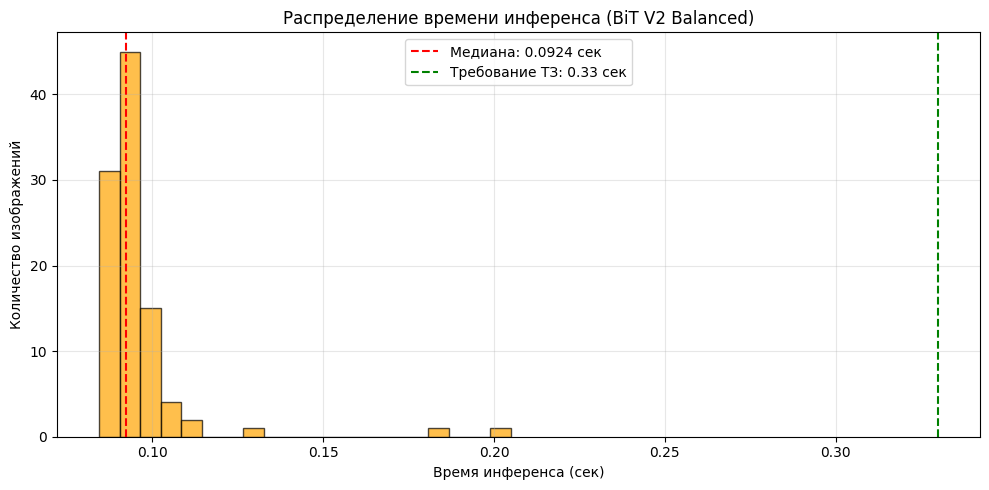

  📊 График сохранен: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_results_v2_balanced/inference_time_bit_v2_balanced_final.png

📝 СОЗДАНИЕ SUBMISSION ФАЙЛА (Balanced Model) для 5000 изображений
--------------------------------------------------


Обработка тестовых изображений (Balanced): 100%|█| 5000/5000 [08:04<00:00, 10.32



✅ SUBMISSION СОЗДАН (Balanced Model):
  📄 Kaggle submission: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_results_v2_balanced/kaggle_submission_bit_v2_balanced_final.csv
  📄 Полные данные: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_results_v2_balanced/submission_full_bit_v2_balanced_final.csv
  📊 Всего предсказаний: 5000
  📈 Средняя уверенность: 0.677

📊 АНАЛИЗ РАСПРЕДЕЛЕНИЯ ПРЕДСКАЗАНИЙ (Balanced Model):
emotion
anger        696
neutral      673
surprise     663
fear         620
sad          588
happy        540
uncertain    464
disgust      388
contempt     368
Name: count, dtype: int64


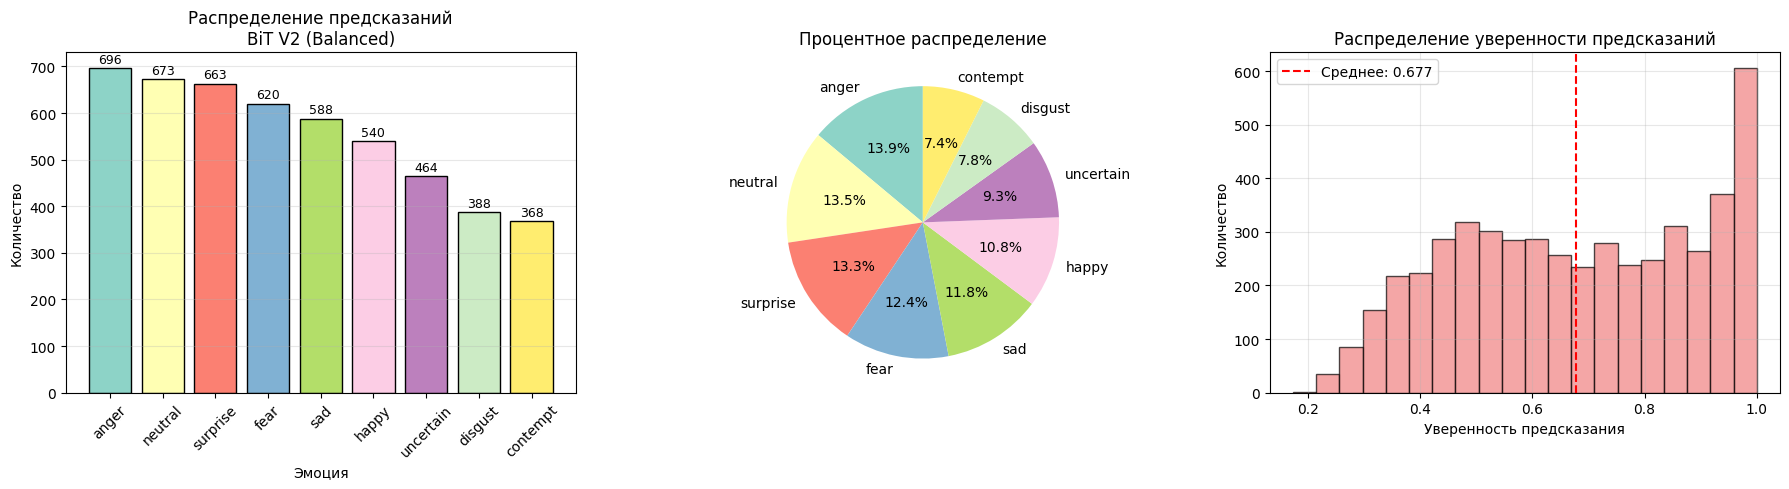

  📊 График распределения сохранен: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_results_v2_balanced/prediction_distribution_bit_v2_balanced_final.png

📈 СТАТИСТИКА ПРЕДСКАЗАНИЙ (Balanced Model):
----------------------------------------
  anger          696 ( 13.9%) | уверенность: 0.676
  neutral        673 ( 13.5%) | уверенность: 0.604
  surprise       663 ( 13.3%) | уверенность: 0.673
  fear           620 ( 12.4%) | уверенность: 0.729
  sad            588 ( 11.8%) | уверенность: 0.699
  happy          540 ( 10.8%) | уверенность: 0.785
  uncertain      464 (  9.3%) | уверенность: 0.588
  disgust        388 (  7.8%) | уверенность: 0.678
  contempt       368 (  7.4%) | уверенность: 0.655
  📄 Статистика сохранена: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/bit_results_v2_balanced/submission_stats_bit_v2_balanced_final.csv

🎉 Процесс для сбалансированной BiT

In [11]:

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# --- ОБЯЗАТЕЛЬНАЯ КОНФИГУРАЦИЯ ---
class BiTConfigV2:
    # Параметры обучения
    BATCH_SIZE = 32
    BASE_LR = 0.01
    WEIGHT_DECAY = 0.0001
    IMG_SIZE = 224
    # Двухступенчатое обучение
    STAGE1_EPOCHS = 5
    STAGE2_EPOCHS = 30
    TOTAL_EPOCHS = STAGE1_EPOCHS + STAGE2_EPOCHS
    # Аугментации
    CROP_SCALE_MIN = 0.8
    COLOR_JITTER_BRIGHTNESS = 0.4
    # Регуляризация
    MIXUP_ALPHA = 0.0
    LABEL_SMOOTHING_EPS = 0.0
    # Scheduler
    WARMUP_EPOCHS = 5
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Пути
    BASE_DIR = Path("/Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22")
    MODELS_DIR = BASE_DIR / "bit_models_v2_balanced"
    RESULTS_DIR = BASE_DIR / "bit_results_v2_balanced"

config = BiTConfigV2()
config.RESULTS_DIR.mkdir(exist_ok=True, parents=True)

# --- ОБЯЗАТЕЛЬНЫЕ ПЕРЕМЕННЫЕ ---
PROCESSED_TEST_DIR = config.BASE_DIR / "processed_data" / "test_cropped_faces"
CLASSES = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise', 'uncertain']
idx_to_class = {idx: cls for idx, cls in enumerate(CLASSES)}
class_to_idx = {cls: idx for idx, cls in enumerate(CLASSES)}

# --- ОБЯЗАТЕЛЬНОЕ ОПРЕДЕЛЕНИЕ ПУТИ К МОДЕЛИ ---
FINAL_MODEL_PATH_BALANCED = config.MODELS_DIR / f"final_bit_model_v2_balanced.pth"

# --- ОБЯЗАТЕЛЬНОЕ ОПРЕДЕЛЕНИЕ МОДЕЛИ ---
class BiTResNet50V2(nn.Module):
    def __init__(self, num_classes=9, pretrained=False): # pretrained=False, т.к. веса загружаем из чекпоинта
        super(BiTResNet50V2, self).__init__()
        from torchvision.models import resnet50, ResNet50_Weights
        if pretrained:
            weights = ResNet50_Weights.IMAGENET1K_V1
            self.base_model = resnet50(weights=weights)
        else:
            self.base_model = resnet50()
        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()
        self.head = nn.Linear(num_features, num_classes)
        nn.init.normal_(self.head.weight, mean=0, std=0.01)
        nn.init.zeros_(self.head.bias)

    def forward(self, x):
        features = self.base_model(x)
        output = self.head(features)
        return output

# --- ОСНОВНАЯ ФУНКЦИЯ ---
def create_submission_for_balanced_model(model_path, test_dir, idx_to_class, output_name="bit_v2_balanced"):
    """
    Создание submission файла для Kaggle для сбалансированной BiT V2 модели
    """
    print(f"\n📋 Загрузка сбалансированной модели: {model_path.name}")

    try:
        checkpoint = torch.load(model_path, map_location=config.DEVICE)
        print(f"✅ Чекпоинт загружен.")
    except FileNotFoundError:
        print(f"❌ Файл модели не найден: {model_path}")
        return None
    except Exception as e:
        print(f"❌ Ошибка при загрузке чекпоинта: {e}")
        return None

    model_accuracy = checkpoint.get('val_acc', checkpoint.get('best_val_acc', 'N/A'))
    print(f"📊 Точность модели (из чекпоинта): {model_accuracy}")

    # Извлекаем idx_to_class из чекпоинта, если он там есть
    checkpoint_idx_to_class = checkpoint.get('idx_to_class', idx_to_class)
    if checkpoint_idx_to_class != idx_to_class:
        print(f"⚠️ idx_to_class в чекпоинте отличается, используем из чекпоинта.")
        idx_to_class = checkpoint_idx_to_class

    num_classes_checkpoint = len(idx_to_class)
    print(f"🔧 Ожидаемое количество классов: {num_classes_checkpoint}")

    model = BiTResNet50V2(num_classes=num_classes_checkpoint, pretrained=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Веса модели загружены")

    model.to(config.DEVICE)
    model.eval()

    test_transform = transforms.Compose([
        transforms.Resize(int(config.IMG_SIZE * 1.14)),
        transforms.CenterCrop(config.IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_images = sorted([f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    print(f"\n📊 Найдено тестовых изображений: {len(test_images)}")

    print(f"\n⏱️  ИЗМЕРЕНИЕ ВРЕМЕНИ ИНФЕРЕНСА (Balanced Model)")
    print("-" * 50)

    test_sample = test_images[:min(100, len(test_images))]
    inference_times = []

    with torch.no_grad():
        for img_file in tqdm(test_sample, desc="Тест скорости инференса (Balanced)"):
            img_path = test_dir / img_file
            try:
                start_time = time.time()
                image = Image.open(img_path).convert('RGB')
                image_tensor = test_transform(image).unsqueeze(0).to(config.DEVICE)
                outputs = model(image_tensor)
                probabilities = torch.softmax(outputs, dim=1)
                _, predicted_idx = outputs.max(1)
                end_time = time.time()
                inference_times.append(end_time - start_time)
            except Exception as e:
                print(f"❌ Ошибка при обработке {img_file}: {e}")
                inference_times.append(0)

    if inference_times:
        valid_inference_times = [t for t in inference_times if t > 0]
        if not valid_inference_times:
             print("⚠️  Все измерения времени оказались нулевыми.")
             return None

        mean_time = np.mean(valid_inference_times)
        median_time = np.median(valid_inference_times)
        std_time = np.std(valid_inference_times)
        min_time = min(valid_inference_times)
        max_time = max(valid_inference_times)

        print(f"\n📈 СТАТИСТИКА ВРЕМЕНИ ИНФЕРЕНСА (Balanced Model):")
        print(f"  Среднее время: {mean_time:.4f} сек")
        print(f"  Медианное время: {median_time:.4f} сек")
        print(f"  Стандартное отклонение: {std_time:.4f} сек")
        print(f"  Минимальное время: {min_time:.4f} сек")
        print(f"  Максимальное время: {max_time:.4f} сек")
        print(f"  FPS: {1/mean_time:.1f} кадров/сек")

        requirement_met = median_time < 0.33
        print(f"\n✅ ТРЕБОВАНИЕ ТЗ: < 0.33 сек на изображение")
        print(f"   Результат: {median_time:.4f} сек {'✅ ВЫПОЛНЕНО' if requirement_met else '❌ НЕ ВЫПОЛНЕНО'}")

        plt.figure(figsize=(10, 5))
        plt.hist(valid_inference_times, bins=20, alpha=0.7, color='orange', edgecolor='black')
        plt.axvline(median_time, color='red', linestyle='--', label=f'Медиана: {median_time:.4f} сек')
        plt.axvline(0.33, color='green', linestyle='--', label='Требование ТЗ: 0.33 сек')
        plt.xlabel('Время инференса (сек)')
        plt.ylabel('Количество изображений')
        plt.title(f'Распределение времени инференса (BiT V2 Balanced)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        inference_plot_path = config.RESULTS_DIR / f"inference_time_{output_name}.png"
        plt.savefig(inference_plot_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  📊 График сохранен: {inference_plot_path}")
    else:
        print("⚠️  Не удалось получить измерения времени инференса.")
        return None

    print(f"\n📝 СОЗДАНИЕ SUBMISSION ФАЙЛА (Balanced Model) для {len(test_images)} изображений")
    print("-" * 50)

    submission_data = []
    confidence_scores = []

    with torch.no_grad():
        pbar = tqdm(test_images, desc="Обработка тестовых изображений (Balanced)")
        for img_file in pbar:
            img_path = test_dir / img_file
            try:
                image = Image.open(img_path).convert('RGB')
                image_tensor = test_transform(image).unsqueeze(0).to(config.DEVICE)
                outputs = model(image_tensor)
                probabilities = torch.softmax(outputs, dim=1)
                _, predicted_idx = outputs.max(1)

                predicted_class_idx = predicted_idx.item()
                if predicted_class_idx in idx_to_class:
                     emotion = idx_to_class[predicted_class_idx]
                else:
                     print(f"⚠️ Неверный индекс класса {predicted_class_idx}, используем 'neutral'")
                     emotion = 'neutral'

                confidence = probabilities[0, predicted_idx].item()
                confidence_scores.append(confidence)

                submission_data.append({
                    'image_path': img_file,
                    'emotion': emotion,
                    'confidence': confidence,
                    'predicted_idx': predicted_class_idx,
                    'top_probability': confidence
                })
            except Exception as e:
                print(f"\n❌ Ошибка при обработке {img_file}: {e}")
                submission_data.append({
                    'image_path': img_file,
                    'emotion': 'neutral',
                    'confidence': 0.0,
                    'predicted_idx': 0,
                    'top_probability': 0.0
                })
                confidence_scores.append(0.0)

    submission_df = pd.DataFrame(submission_data)
    kaggle_df = submission_df[['image_path', 'emotion']].copy()
    output_path = config.RESULTS_DIR / f"kaggle_submission_{output_name}.csv"
    kaggle_df.to_csv(output_path, index=False)

    full_data_path = config.RESULTS_DIR / f"submission_full_{output_name}.csv"
    submission_df.to_csv(full_data_path, index=False)

    print(f"\n✅ SUBMISSION СОЗДАН (Balanced Model):")
    print(f"  📄 Kaggle submission: {output_path}")
    print(f"  📄 Полные данные: {full_data_path}")
    print(f"  📊 Всего предсказаний: {len(submission_df)}")
    print(f"  📈 Средняя уверенность: {np.mean(confidence_scores):.3f}")

    print(f"\n📊 АНАЛИЗ РАСПРЕДЕЛЕНИЯ ПРЕДСКАЗАНИЙ (Balanced Model):")
    emotion_counts = submission_df['emotion'].value_counts()
    print(emotion_counts)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = plt.cm.Set3(np.linspace(0, 1, len(emotion_counts)))
    bars = axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='black')
    axes[0].set_title(f'Распределение предсказаний\nBiT V2 (Balanced)', fontsize=12)
    axes[0].set_xlabel('Эмоция')
    axes[0].set_ylabel('Количество')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 5,
                     f'{int(height)}', ha='center', va='bottom', fontsize=9)

    axes[1].pie(emotion_counts.values, labels=emotion_counts.index,
                autopct='%1.1f%%', startangle=90, colors=colors)
    axes[1].set_title('Процентное распределение', fontsize=12)

    axes[2].hist(confidence_scores, bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[2].axvline(np.mean(confidence_scores), color='red', linestyle='--',
                    label=f'Среднее: {np.mean(confidence_scores):.3f}')
    axes[2].set_xlabel('Уверенность предсказания')
    axes[2].set_ylabel('Количество')
    axes[2].set_title('Распределение уверенности предсказаний', fontsize=12)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    distribution_plot_path = config.RESULTS_DIR / f"prediction_distribution_{output_name}.png"
    plt.savefig(distribution_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  📊 График распределения сохранен: {distribution_plot_path}")

    print("\n📈 СТАТИСТИКА ПРЕДСКАЗАНИЙ (Balanced Model):")
    print("-" * 40)
    for emotion, count in emotion_counts.items():
        percentage = count / len(submission_df) * 100
        avg_confidence = submission_df[submission_df['emotion'] == emotion]['confidence'].mean()
        print(f"  {emotion:<12} {count:>5} ({percentage:>5.1f}%) | уверенность: {avg_confidence:.3f}")

    stats_data = []
    for emotion, count in emotion_counts.items():
        percentage = count / len(submission_df) * 100
        avg_conf = submission_df[submission_df['emotion'] == emotion]['confidence'].mean()
        stats_data.append({
            'emotion': emotion,
            'count': count,
            'percentage': percentage,
            'avg_confidence': avg_conf
        })
    stats_df = pd.DataFrame(stats_data)
    stats_path = config.RESULTS_DIR / f"submission_stats_{output_name}.csv"
    stats_df.to_csv(stats_path, index=False)
    print(f"  📄 Статистика сохранена: {stats_path}")

    return {
        'model_name': output_name,
        'model_accuracy': model_accuracy,
        'inference_time_median': median_time,
        'inference_time_mean': mean_time,
        'fps': 1/mean_time if mean_time > 0 else 0,
        'requirement_met': requirement_met,
        'submission_path': output_path,
        'full_data_path': full_data_path,
        'stats_path': stats_path,
        'emotion_distribution': emotion_counts.to_dict(),
        'avg_confidence': np.mean(confidence_scores),
        'total_predictions': len(submission_df)
    }

# --- ЗАПУСК СОЗДАНИЯ SUBMISSION ДЛЯ СБАЛАНСИРОВАННОЙ МОДЕЛИ ---
if FINAL_MODEL_PATH_BALANCED.exists(): # <-- Используем переменную, объявленную В ЭТОЙ ячейке
    print(f"✅ Найдена финальная сбалансированная модель: {FINAL_MODEL_PATH_BALANCED.name}")
    submission_info_balanced = create_submission_for_balanced_model(
        model_path=FINAL_MODEL_PATH_BALANCED,
        test_dir=PROCESSED_TEST_DIR,
        idx_to_class=idx_to_class, # Теперь переменная определена
        output_name="bit_v2_balanced_final"
    )
    if submission_info_balanced:
        print(f"\n🎉 Процесс для сбалансированной BiT V2 завершён успешно!")
        print(f"   Точность (из чекпоинта): {submission_info_balanced['model_accuracy']}")
        print(f"   Время инференса (медиана): {submission_info_balanced['inference_time_median']:.4f} сек")
        print(f"   Требование ТЗ: {'✅ ВЫПОЛНЕНО' if submission_info_balanced['requirement_met'] else '❌ НЕ ВЫПОЛНЕНО'}")
        print(f"   Файл Kaggle submission: {submission_info_balanced['submission_path']}")
else:
    print(f"❌ Финальная сбалансированная модель не найдена: {FINAL_MODEL_PATH_BALANCED}")
    # Поищем любую модель в директории, если путь отличается
    available_models = list(config.MODELS_DIR.glob("*.pth"))
    if available_models:
        print(f"ℹ️  Найдены другие .pth файлы в {config.MODELS_DIR}:")
        for m in available_models:
            print(f"  - {m.name}")
    else:
        print(f"❌ В директории {config.MODELS_DIR} нет .pth файлов.")
